In [1]:
# CELL 1: Imports & Configuration
# ============================================
# Run this cell first before any other cells
# ============================================

import pandas as pd
import numpy as np
import random
import json
import os
import math
from collections import defaultdict, Counter

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Avertissements
import warnings
warnings.filterwarnings('ignore')

# Configuration des styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Pour la reproductibilité
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Paramètres globaux
N_ETUDIANTS = 10000  # Nombre d'étudiants virtuels à générer
TEST_SIZE = 0.2      # Taille du test set (20%)
VAL_SIZE = 0.1       # Taille du validation set (10%)

# Wilayas codes (58 wilayas)
WILAYAS = list(range(1, 59))

# Valeurs possibles pour les features catégorielles
BAC_STREAMS = ['Maths', 'Sciences', 'Technique Mathématique', 'Gestion', 'Lettres', 'Langues']
CAREER_ORIENTATIONS = ['Recherche', 'Industrie', 'Enseignement', 'Mixte']

# Soft skills range (1-5)
SOFT_SKILLS_RANGE = (1, 6)

print("=" * 60)
print("📚 POST-BAC ORIENTATION ML SYSTEM")
print("=" * 60)
print(f"   Random Seed: {RANDOM_SEED}")
print(f"   Nombre d'étudiants virtuels: {N_ETUDIANTS}")
print(f"   Test size: {TEST_SIZE}")
print(f"   Validation size: {VAL_SIZE}")
print(f"   Wilayas: {len(WILAYAS)}")
print(f"   Filières BAC: {len(BAC_STREAMS)}")
print("=" * 60)
print("\n✅ Cell 1 executed successfully!")
print("→ Run Cell 2 next (Chargement du JSON des formations)")

📚 POST-BAC ORIENTATION ML SYSTEM
   Random Seed: 42
   Nombre d'étudiants virtuels: 10000
   Test size: 0.2
   Validation size: 0.1
   Wilayas: 58
   Filières BAC: 6

✅ Cell 1 executed successfully!
→ Run Cell 2 next (Chargement du JSON des formations)


In [2]:
# CELL 2: Chargement du JSON des formations
# ============================================
# Run this after Cell 1
# Charge le fichier data.json contenant tous les domaines et formations
# ============================================

# ============================================
# 1. Chargement du fichier JSON
# ============================================

json_file_path = 'data.json'

print("=" * 60)
print("📂 Chargement du fichier JSON")
print("=" * 60)

try:
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"✅ Fichier chargé avec succès: {json_file_path}")
except FileNotFoundError:
    print(f"❌ Fichier non trouvé: {json_file_path}")
    print("   Vérifie que le fichier est dans le bon répertoire")
    exit()
except json.JSONDecodeError as e:
    print(f"❌ Erreur de syntaxe JSON: {e}")
    print(f"   Ligne: {e.lineno}, Colonne: {e.colno}")
    exit()

# ============================================
# 2. Vérification de la structure
# ============================================

print("\n" + "=" * 60)
print("🔍 Vérification de la structure")
print("=" * 60)

# Vérifier que c'est une liste
if isinstance(data, list):
    print(f"✅ Le fichier contient une liste de {len(data)} domaines")
    domaines = data
elif isinstance(data, dict):
    # Si c'est un objet avec une clé 'domaines'
    if 'domaines' in data:
        domaines = data['domaines']
        print(f"✅ Le fichier contient {len(domaines)} domaines (clé 'domaines')")
    else:
        # Sinon, on met dans une liste
        domaines = [data]
        print(f"✅ Le fichier contient 1 domaine")
else:
    print(f"❌ Structure non reconnue: {type(data)}")
    exit()

# ============================================
# 3. Affichage des domaines
# ============================================

print("\n" + "=" * 60)
print("📚 LISTE DES DOMAINES DISPONIBLES")
print("=" * 60)

for i, domaine in enumerate(domaines, 1):
    nom = domaine.get('domaine', 'Nom inconnu')
    description = domaine.get('description', '')[:50]
    filieres = domaine.get('filiere_bac_accessibles', [])
    print(f"\n{i}. {nom}")
    print(f"   Description: {description}...")
    print(f"   Filières BAC acceptées: {', '.join(filieres)}")
    
    # Compter les formations
    formations = domaine.get('formations', {})
    nb_ecoles = len(formations.get('ecoles_superieures', []))
    nb_ingeniorat = len(formations.get('ingeniorat', []))
    nb_lmd = len(formations.get('lmd', []))
    nb_ens = len(formations.get('ens', []))
    nb_instituts = len(formations.get('instituts_elite', []))
    
    total_formations = nb_ecoles + nb_ingeniorat + nb_lmd + nb_ens + nb_instituts
    print(f"   Formations: {total_formations} au total")
    print(f"      - Écoles Supérieures: {nb_ecoles}")
    print(f"      - Ingéniorat: {nb_ingeniorat}")
    print(f"      - LMD: {nb_lmd}")
    print(f"      - ENS: {nb_ens}")
    if nb_instituts > 0:
        print(f"      - Instituts d'Élite: {nb_instituts}")

# ============================================
# 4. Vérification des champs requis
# ============================================

print("\n" + "=" * 60)
print("🔍 Vérification des champs requis")
print("=" * 60)

champs_requis_domaine = ['domaine', 'filiere_bac_accessibles', 'formations']
champs_requis_formation = ['id', 'nom', 'duree', 'type_recrutement', 'streams_acceptes']

erreurs = []

for i, domaine in enumerate(domaines):
    # Vérifier les champs du domaine
    for champ in champs_requis_domaine:
        if champ not in domaine:
            erreurs.append(f"Domaine {i+1}: champ '{champ}' manquant")
    
    # Vérifier les formations
    formations = domaine.get('formations', {})
    for type_form, liste in formations.items():
        for j, formation in enumerate(liste):
            for champ in champs_requis_formation:
                if champ not in formation:
                    erreurs.append(f"Domaine {i+1}, {type_form}[{j}]: champ '{champ}' manquant")

if erreurs:
    print(f"⚠️ {len(erreurs)} erreurs trouvées:")
    for err in erreurs[:10]:  # Afficher max 10 erreurs
        print(f"   - {err}")
    if len(erreurs) > 10:
        print(f"   ... et {len(erreurs)-10} autres erreurs")
else:
    print("✅ Tous les champs requis sont présents")

# ============================================
# 5. Statistiques globales
# ============================================

print("\n" + "=" * 60)
print("📊 STATISTIQUES GLOBALES")
print("=" * 60)

total_formations = 0
total_ecoles = 0
total_ingeniorat = 0
total_lmd = 0
total_ens = 0
total_instituts = 0

for domaine in domaines:
    formations = domaine.get('formations', {})
    total_ecoles += len(formations.get('ecoles_superieures', []))
    total_ingeniorat += len(formations.get('ingeniorat', []))
    total_lmd += len(formations.get('lmd', []))
    total_ens += len(formations.get('ens', []))
    total_instituts += len(formations.get('instituts_elite', []))

total_formations = total_ecoles + total_ingeniorat + total_lmd + total_ens + total_instituts

print(f"   Nombre de domaines: {len(domaines)}")
print(f"   Nombre total de formations: {total_formations}")
print(f"      - Écoles Supérieures: {total_ecoles}")
print(f"      - Ingéniorat: {total_ingeniorat}")
print(f"      - LMD: {total_lmd}")
print(f"      - ENS: {total_ens}")
print(f"      - Instituts d'Élite: {total_instituts}")

# ============================================
# 6. Export pour les cellules suivantes
# ============================================

print("\n" + "=" * 60)
print("✅ Cell 2 executed successfully!")
print("=" * 60)
print(f"   📂 {len(domaines)} domaines chargés")
print(f"   📚 {total_formations} formations disponibles")
print("=" * 60)
print("\n📌 Variables disponibles pour les cellules suivantes:")
print("   • domaines - Liste de tous les domaines avec leurs formations")
print("   • total_formations - Nombre total de formations")
print("\n→ Run Cell 3 next (Student Profile Generator)")

📂 Chargement du fichier JSON
✅ Fichier chargé avec succès: data.json

🔍 Vérification de la structure
✅ Le fichier contient une liste de 11 domaines

📚 LISTE DES DOMAINES DISPONIBLES

1. الرياضيات والإعلام الآلي
   Description: تكوين في الرياضيات، الإعلام الآلي، الذكاء الاصطناع...
   Filières BAC acceptées: رياضيات, علوم تجريبية, تقني رياضي
   Formations: 15 au total
      - Écoles Supérieures: 6
      - Ingéniorat: 3
      - LMD: 2
      - ENS: 4

2. العلوم والتكنولوجيا (ST)
   Description: تكوين مهندسين، ليسانس وماستر في المجالات الصناعية ...
   Filières BAC acceptées: تقني رياضي, رياضيات, علوم تجريبية
   Formations: 18 au total
      - Écoles Supérieures: 10
      - Ingéniorat: 1
      - LMD: 1
      - ENS: 6

3. علوم الطبيعة والحياة (SNV)
   Description: تكوين مخصص لدراسة الكائنات الحية، البيولوجيا الجزي...
   Filières BAC acceptées: علوم تجريبية, رياضيات
   Formations: 7 au total
      - Écoles Supérieures: 3
      - Ingéniorat: 0
      - LMD: 2
      - ENS: 2

4. الطب والطب المساع

In [98]:
# CELL 3.1: Génération du dataset - Sciences (avec Tamazight) - CORRIGÉE
# ============================================

import random
import numpy as np
import pandas as pd

# ============================================
# 1. Configuration
# ============================================

N_ETUDIANTS = 2000
WILAYAS = list(range(1, 59))

TOUTES_MATIERES = ['maths_grade', 'physique_grade', 'science_grade', 'techno_grade',
                   'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade',
                   'francais_grade', 'anglais_grade', 'tamazight_grade', 'langue_etranger_grade',
                   'his_geo_grade', 'islamia_grade', 'philo_grade']

# Matières présentes dans la filière Sciences (avec Tamazight)
MATIERES_FILIERE = ['maths_grade', 'physique_grade', 'science_grade', 
                    'arabe_grade', 'francais_grade', 'anglais_grade', 
                    'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade']

# ============================================
# 2. Coefficients pour le calcul de la moyenne BAC (Sciences)
# ============================================

COEFFS = {
    'science_grade': 6,
    'physique_grade': 5,
    'maths_grade': 5,
    'arabe_grade': 3,
    'islamia_grade': 2,
    'his_geo_grade': 2,
    'francais_grade': 2,
    'anglais_grade': 2,
    'philo_grade': 2,
    'tamazight_grade': 2
}

# ============================================
# 3. Niveaux et proportions
# ============================================

NIVEAUX = {
    'excellent': {'proba': 0.30, 'plage_notes': (14, 19), 'bac_range': (16, 19)},
    'bon': {'proba': 0.40, 'plage_notes': (11, 16), 'bac_range': (13, 16)},
    'moyen': {'proba': 0.30, 'plage_notes': (10, 13), 'bac_range': (10, 13)}
}

# ============================================
# 4. Domaines possibles et ordre de sélectivité
# ============================================

DOMAINES_POSSIBLES = ['medecine', 'maths_info', 'st', 'snv', 'segc']

# Ordre de sélectivité (le plus sélectif d'abord)
SELECTIVITE = {
    'maths_info': 1,
    'medecine': 2,
    'st': 3,
    'snv': 4,
    'segc': 5
}

# ============================================
# 5. Calcul des weighted averages (CORRIGÉ)
# ============================================

def calculer_weighted(notes):
    bac = notes['bac_avg']
    return {
        'maths_info': (bac * 2 + notes.get('maths_grade', 0)) / 3,
        # ST : plus de techno_grade (inexistant en Sciences)
        'st': (bac * 2 + notes.get('physique_grade', 0)) / 3,
        'snv': (bac * 2 + notes.get('science_grade', 0)) / 3,
        'medecine': (bac * 2 + notes.get('science_grade', 0) * 1.2 + 
                     notes.get('maths_grade', 0) * 0.4 + notes.get('physique_grade', 0) * 0.4) / 4,
        # SEGC : simplifié car notes gestion/eco inexistantes en Sciences
        'segc': bac
    }

# ============================================
# 6. Choix du domaine cible
# ============================================

def choisir_domaine_cible(weighted):
    weighted_filtre = {d: weighted[d] for d in DOMAINES_POSSIBLES if d in weighted}
    max_weighted = max(weighted_filtre.values())
    domaines_proches = [d for d, w in weighted_filtre.items() if w >= max_weighted - 0.2]
    
    if len(domaines_proches) == 1:
        return domaines_proches[0]
    else:
        return min(domaines_proches, key=lambda d: SELECTIVITE[d])

# ============================================
# 7. Calcul de la moyenne BAC réelle (avec coefficients)
# ============================================

def calculer_moyenne_bac(notes):
    total_points = 0
    total_coeffs = 0
    
    for matiere, coeff in COEFFS.items():
        note = notes.get(matiere, 0)
        if not np.isnan(note):
            total_points += note * coeff
            total_coeffs += coeff
    
    if total_coeffs == 0:
        return 10.0
    
    return round(total_points / total_coeffs, 1)

# ============================================
# 8. Génération des notes brutes
# ============================================

def generer_notes(niveau):
    plage = NIVEAUX[niveau]['plage_notes']
    notes = {m: np.nan for m in TOUTES_MATIERES}
    
    for matiere in MATIERES_FILIERE:
        note = random.uniform(plage[0], plage[1])
        note += np.random.normal(0, 0.3)
        notes[matiere] = round(max(10, min(20, note)), 1)
    
    return notes

# ============================================
# 9. Booster la note clé du domaine
# ============================================

def booster_note_cle(notes, domaine_cible):
    if domaine_cible == 'medecine':
        notes['science_grade'] = min(20, notes['science_grade'] + random.uniform(1, 3))
        notes['maths_grade'] = min(20, notes['maths_grade'] + random.uniform(0.5, 1.5))
    elif domaine_cible == 'maths_info':
        notes['maths_grade'] = min(20, notes['maths_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'st':
        notes['physique_grade'] = min(20, notes['physique_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'snv':
        notes['science_grade'] = min(20, notes['science_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'segc':
        # Pas de notes à booster pour SEGC en Sciences (pas de gestion/eco)
        pass
    
    return notes

# ============================================
# 10. Génération d'un étudiant complet
# ============================================

def generer_etudiant():
    niveaux_liste = list(NIVEAUX.keys())
    niveaux_probas = [NIVEAUX[n]['proba'] for n in niveaux_liste]
    niveau = random.choices(niveaux_liste, weights=niveaux_probas)[0]
    
    notes = generer_notes(niveau)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    weighted = calculer_weighted(notes)
    domaine_cible = choisir_domaine_cible(weighted)
    
    notes = booster_note_cle(notes, domaine_cible)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    soft_skills = {
        'stress_level': random.randint(1, 5),
        'competitiveness': random.randint(1, 5),
        'consistency_score': random.randint(1, 5)
    }
    
    progression = {
        'trimester1_avg': round(bac_avg + random.uniform(-1.5, 1.5), 1),
        'trimester2_avg': round(bac_avg + random.uniform(-1, 1), 1),
        'trimester3_avg': round(bac_avg + random.uniform(-0.5, 0.5), 1)
    }
    
    orientation = random.choices(['Recherche', 'Industrie', 'Enseignement', 'Mixte'], 
                                  weights=[0.20, 0.35, 0.25, 0.20])[0]
    
    return {
        'bac_avg': notes['bac_avg'],
        'bac_stream': 'Sciences',
        'maths_grade': notes.get('maths_grade', np.nan),
        'physique_grade': notes.get('physique_grade', np.nan),
        'science_grade': notes.get('science_grade', np.nan),
        'techno_grade': notes.get('techno_grade', np.nan),
        'gestion_grade': notes.get('gestion_grade', np.nan),
        'economie_grade': notes.get('economie_grade', np.nan),
        'loi_grade': notes.get('loi_grade', np.nan),
        'arabe_grade': notes.get('arabe_grade', np.nan),
        'francais_grade': notes.get('francais_grade', np.nan),
        'anglais_grade': notes.get('anglais_grade', np.nan),
        'tamazight_grade': notes.get('tamazight_grade', np.nan),
        'langue_etranger_grade': notes.get('langue_etranger_grade', np.nan),
        'his_geo_grade': notes.get('his_geo_grade', np.nan),
        'islamia_grade': notes.get('islamia_grade', np.nan),
        'philo_grade': notes.get('philo_grade', np.nan),
        'trimester1_avg': progression['trimester1_avg'],
        'trimester2_avg': progression['trimester2_avg'],
        'trimester3_avg': progression['trimester3_avg'],
        'stress_level': soft_skills['stress_level'],
        'competitiveness': soft_skills['competitiveness'],
        'consistency_score': soft_skills['consistency_score'],
        'career_orientation': orientation,
        'wilaya': random.choice(WILAYAS),
        'domaine_cible': domaine_cible
    }

# ============================================
# 11. Génération du dataset complet
# ============================================

print("=" * 60)
print("📊 GÉNÉRATION DU DATASET - SCIENCES (CORRIGÉ - ST/SEGC RÉÉQUILIBRÉS)")
print("=" * 60)
print(f"Nombre d'étudiants: {N_ETUDIANTS}")
print(f"Domaines possibles: {DOMAINES_POSSIBLES}")
print(f"Niveaux: excellent (30%), bon (40%), moyen (30%)")
print("=" * 60)

etudiants = [generer_etudiant() for _ in range(N_ETUDIANTS)]
df = pd.DataFrame(etudiants)

filename = "dataset_Sciences.csv"
df.to_csv(filename, index=False, encoding='utf-8')
print(f"\n✅ Dataset sauvegardé: {filename}")
print(f"   {len(df)} étudiants")

print("\n📊 Distribution des domaines cibles:")
print(df['domaine_cible'].value_counts(normalize=True).mul(100).round(1))

print("\n📊 Moyenne BAC par niveau:")
df['niveau'] = pd.cut(df['bac_avg'], bins=[0, 13, 16, 20], labels=['moyen', 'bon', 'excellent'])
print(df.groupby('niveau')['bac_avg'].agg(['mean', 'count']))

print("\n✅ Cell 3.1 terminée")

📊 GÉNÉRATION DU DATASET - SCIENCES (CORRIGÉ - ST/SEGC RÉÉQUILIBRÉS)
Nombre d'étudiants: 2000
Domaines possibles: ['medecine', 'maths_info', 'st', 'snv', 'segc']
Niveaux: excellent (30%), bon (40%), moyen (30%)

✅ Dataset sauvegardé: dataset_Sciences.csv
   2000 étudiants

📊 Distribution des domaines cibles:
domaine_cible
maths_info    45.4
st            22.7
medecine      20.6
snv           10.6
segc           0.6
Name: proportion, dtype: float64

📊 Moyenne BAC par niveau:
                mean  count
niveau                     
moyen      11.968769    666
bon        14.020945    783
excellent  16.891652    551

✅ Cell 3.1 terminée


In [109]:
# CELL 3.2: Génération du dataset - Maths (avec Tamazight) - CORRIGÉE
# ============================================

import random
import numpy as np
import pandas as pd

# ============================================
# 1. Configuration
# ============================================

N_ETUDIANTS = 2000
WILAYAS = list(range(1, 59))

TOUTES_MATIERES = ['maths_grade', 'physique_grade', 'science_grade', 'techno_grade',
                   'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade',
                   'francais_grade', 'anglais_grade', 'tamazight_grade', 'langue_etranger_grade',
                   'his_geo_grade', 'islamia_grade', 'philo_grade']

# Matières présentes dans la filière Maths (avec Tamazight)
MATIERES_FILIERE = ['maths_grade', 'physique_grade', 'science_grade', 
                    'arabe_grade', 'francais_grade', 'anglais_grade', 
                    'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade']

# ============================================
# 2. Coefficients pour le calcul de la moyenne BAC (Maths)
# ============================================

COEFFS = {
    'maths_grade': 7,
    'physique_grade': 6,
    'science_grade': 2,
    'arabe_grade': 3,
    'islamia_grade': 2,
    'his_geo_grade': 2,
    'francais_grade': 2,
    'anglais_grade': 2,
    'philo_grade': 2,
    'tamazight_grade': 2
}

# ============================================
# 3. Niveaux et proportions
# ============================================

NIVEAUX = {
    'excellent': {'proba': 0.30, 'plage_notes': (14, 19), 'bac_range': (16, 19)},
    'bon': {'proba': 0.40, 'plage_notes': (11, 16), 'bac_range': (13, 16)},
    'moyen': {'proba': 0.30, 'plage_notes': (10, 13), 'bac_range': (10, 13)}
}

# ============================================
# 4. Domaines possibles et ordre de sélectivité
# ============================================

DOMAINES_POSSIBLES = ['maths_info', 'medecine', 'st', 'snv', 'segc']

# Ordre de sélectivité (le plus sélectif d'abord)
SELECTIVITE = {
    'maths_info': 1,
    'medecine': 2,
    'st': 3,
    'snv': 4,
    'segc': 5
}

# ============================================
# 5. Calcul des weighted averages (CORRIGÉ)
# ============================================

def calculer_weighted(notes):
    bac = notes['bac_avg']
    return {
        'maths_info': (bac * 2 + notes.get('maths_grade', 0)) / 3,
        # ST : ignorer techno_grade (inexistant en Maths)
        'st': (bac * 2 + notes.get('physique_grade', 0)) / 3,
        'snv': (bac * 2 + notes.get('science_grade', 0)) / 3,
        'medecine': (bac * 2 + notes.get('science_grade', 0) * 1.2 + 
                     notes.get('maths_grade', 0) * 0.4 + notes.get('physique_grade', 0) * 0.4) / 4,
        # SEGC : simplifié car notes gestion/eco inexistantes en Maths
        'segc': bac
    }

# ============================================
# 6. Choix du domaine cible
# ============================================

def choisir_domaine_cible(weighted):
    weighted_filtre = {d: weighted[d] for d in DOMAINES_POSSIBLES if d in weighted}
    max_weighted = max(weighted_filtre.values())
    domaines_proches = [d for d, w in weighted_filtre.items() if w >= max_weighted - 0.2]
    
    if len(domaines_proches) == 1:
        return domaines_proches[0]
    else:
        return min(domaines_proches, key=lambda d: SELECTIVITE[d])

# ============================================
# 7. Calcul de la moyenne BAC réelle (avec coefficients)
# ============================================

def calculer_moyenne_bac(notes):
    total_points = 0
    total_coeffs = 0
    
    for matiere, coeff in COEFFS.items():
        note = notes.get(matiere, 0)
        if not np.isnan(note):
            total_points += note * coeff
            total_coeffs += coeff
    
    if total_coeffs == 0:
        return 10.0
    
    return round(total_points / total_coeffs, 1)

# ============================================
# 8. Génération des notes brutes
# ============================================

def generer_notes(niveau):
    plage = NIVEAUX[niveau]['plage_notes']
    notes = {m: np.nan for m in TOUTES_MATIERES}
    
    for matiere in MATIERES_FILIERE:
        note = random.uniform(plage[0], plage[1])
        note += np.random.normal(0, 0.3)
        notes[matiere] = round(max(10, min(20, note)), 1)
    
    return notes

# ============================================
# 9. Booster la note clé du domaine
# ============================================

def booster_note_cle(notes, domaine_cible):
    if domaine_cible == 'medecine':
        notes['science_grade'] = min(20, notes['science_grade'] + random.uniform(1, 3))
        notes['maths_grade'] = min(20, notes['maths_grade'] + random.uniform(0.5, 1.5))
    elif domaine_cible == 'maths_info':
        notes['maths_grade'] = min(20, notes['maths_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'st':
        notes['physique_grade'] = min(20, notes['physique_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'snv':
        notes['science_grade'] = min(20, notes['science_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'segc':
        # Pas de notes à booster pour SEGC en Maths
        pass
    
    return notes

# ============================================
# 10. Génération d'un étudiant complet
# ============================================

def generer_etudiant():
    niveaux_liste = list(NIVEAUX.keys())
    niveaux_probas = [NIVEAUX[n]['proba'] for n in niveaux_liste]
    niveau = random.choices(niveaux_liste, weights=niveaux_probas)[0]
    
    notes = generer_notes(niveau)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    weighted = calculer_weighted(notes)
    domaine_cible = choisir_domaine_cible(weighted)
    
    notes = booster_note_cle(notes, domaine_cible)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    soft_skills = {
        'stress_level': random.randint(1, 5),
        'competitiveness': random.randint(1, 5),
        'consistency_score': random.randint(1, 5)
    }
    
    progression = {
        'trimester1_avg': round(bac_avg + random.uniform(-1.5, 1.5), 1),
        'trimester2_avg': round(bac_avg + random.uniform(-1, 1), 1),
        'trimester3_avg': round(bac_avg + random.uniform(-0.5, 0.5), 1)
    }
    
    orientation = random.choices(['Recherche', 'Industrie', 'Enseignement', 'Mixte'], 
                                  weights=[0.20, 0.35, 0.25, 0.20])[0]
    
    return {
        'bac_avg': notes['bac_avg'],
        'bac_stream': 'Maths',
        'maths_grade': notes.get('maths_grade', np.nan),
        'physique_grade': notes.get('physique_grade', np.nan),
        'science_grade': notes.get('science_grade', np.nan),
        'techno_grade': notes.get('techno_grade', np.nan),
        'gestion_grade': notes.get('gestion_grade', np.nan),
        'economie_grade': notes.get('economie_grade', np.nan),
        'loi_grade': notes.get('loi_grade', np.nan),
        'arabe_grade': notes.get('arabe_grade', np.nan),
        'francais_grade': notes.get('francais_grade', np.nan),
        'anglais_grade': notes.get('anglais_grade', np.nan),
        'tamazight_grade': notes.get('tamazight_grade', np.nan),
        'langue_etranger_grade': notes.get('langue_etranger_grade', np.nan),
        'his_geo_grade': notes.get('his_geo_grade', np.nan),
        'islamia_grade': notes.get('islamia_grade', np.nan),
        'philo_grade': notes.get('philo_grade', np.nan),
        'trimester1_avg': progression['trimester1_avg'],
        'trimester2_avg': progression['trimester2_avg'],
        'trimester3_avg': progression['trimester3_avg'],
        'stress_level': soft_skills['stress_level'],
        'competitiveness': soft_skills['competitiveness'],
        'consistency_score': soft_skills['consistency_score'],
        'career_orientation': orientation,
        'wilaya': random.choice(WILAYAS),
        'domaine_cible': domaine_cible
    }

# ============================================
# 11. Génération du dataset complet
# ============================================

print("=" * 60)
print("📊 GÉNÉRATION DU DATASET - MATHS (CORRIGÉ - ST RÉÉQUILIBRÉ)")
print("=" * 60)
print(f"Nombre d'étudiants: {N_ETUDIANTS}")
print(f"Domaines possibles: {DOMAINES_POSSIBLES}")
print(f"Niveaux: excellent (30%), bon (40%), moyen (30%)")
print("=" * 60)

etudiants = [generer_etudiant() for _ in range(N_ETUDIANTS)]
df = pd.DataFrame(etudiants)

filename = "dataset_Maths.csv"
df.to_csv(filename, index=False, encoding='utf-8')
print(f"\n✅ Dataset sauvegardé: {filename}")
print(f"   {len(df)} étudiants")

print("\n📊 Distribution des domaines cibles:")
print(df['domaine_cible'].value_counts(normalize=True).mul(100).round(1))

print("\n📊 Moyenne BAC par niveau:")
df['niveau'] = pd.cut(df['bac_avg'], bins=[0, 13, 16, 20], labels=['moyen', 'bon', 'excellent'])
print(df.groupby('niveau')['bac_avg'].agg(['mean', 'count']))

print("\n✅ Cell 3.2 terminée")

📊 GÉNÉRATION DU DATASET - MATHS (CORRIGÉ - ST RÉÉQUILIBRÉ)
Nombre d'étudiants: 2000
Domaines possibles: ['maths_info', 'medecine', 'st', 'snv', 'segc']
Niveaux: excellent (30%), bon (40%), moyen (30%)

✅ Dataset sauvegardé: dataset_Maths.csv
   2000 étudiants

📊 Distribution des domaines cibles:
domaine_cible
maths_info    44.8
medecine      23.6
st            23.2
snv            7.4
segc           0.8
Name: proportion, dtype: float64

📊 Moyenne BAC par niveau:
                mean  count
niveau                     
moyen      11.999240    658
bon        14.141280    797
excellent  16.949358    545

✅ Cell 3.2 terminée


In [56]:
# CELL 3.3: Génération du dataset - Technique Mathématique (avec Tamazight)
# ============================================

import random
import numpy as np
import pandas as pd

# ============================================
# 1. Configuration
# ============================================

N_ETUDIANTS = 2000
WILAYAS = list(range(1, 59))

TOUTES_MATIERES = ['maths_grade', 'physique_grade', 'science_grade', 'techno_grade',
                   'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade',
                   'francais_grade', 'anglais_grade', 'tamazight_grade', 'langue_etranger_grade',
                   'his_geo_grade', 'islamia_grade', 'philo_grade']

# Matières présentes dans la filière Technique Mathématique (avec Tamazight)
MATIERES_FILIERE = ['maths_grade', 'physique_grade', 'techno_grade', 
                    'arabe_grade', 'francais_grade', 'anglais_grade', 
                    'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade']

# ============================================
# 2. Coefficients pour le calcul de la moyenne BAC (Technique Mathématique)
# ============================================

COEFFS = {
    'techno_grade': 6,
    'maths_grade': 6,
    'physique_grade': 5,
    'arabe_grade': 3,
    'islamia_grade': 2,
    'his_geo_grade': 2,
    'francais_grade': 2,
    'anglais_grade': 2,
    'philo_grade': 2,
    'tamazight_grade': 2      # ← AJOUT
}

# ============================================
# 3. Niveaux et proportions
# ============================================

NIVEAUX = {
    'excellent': {'proba': 0.25, 'plage_notes': (14, 19), 'bac_range': (15, 19)},
    'bon': {'proba': 0.50, 'plage_notes': (11, 16), 'bac_range': (12, 16)},
    'moyen': {'proba': 0.25, 'plage_notes': (10, 13), 'bac_range': (10, 13)}
}

# ============================================
# 4. Domaines possibles et ordre de sélectivité
# ============================================

DOMAINES_POSSIBLES = ['st', 'maths_info', 'segc']

# Ordre de sélectivité (le plus sélectif d'abord)
SELECTIVITE = {
    'st': 1,
    'maths_info': 2,
    'segc': 3
}

# ============================================
# 5. Calcul des weighted averages
# ============================================

def calculer_weighted(notes):
    bac = notes['bac_avg']
    return {
        'maths_info': (bac * 2 + notes.get('maths_grade', 0)) / 3,
        'st': (bac * 2 + notes.get('physique_grade', 0) + notes.get('techno_grade', 0)) / 4,
        'segc': (bac * 2 + notes.get('gestion_grade', 0) + notes.get('economie_grade', 0)) / 4
    }

# ============================================
# 6. Choix du domaine cible
# ============================================

def choisir_domaine_cible(weighted):
    weighted_filtre = {d: weighted[d] for d in DOMAINES_POSSIBLES if d in weighted}
    max_weighted = max(weighted_filtre.values())
    
    domaines_proches = [d for d, w in weighted_filtre.items() if w >= max_weighted - 0.2]
    
    if len(domaines_proches) == 1:
        return domaines_proches[0]
    else:
        return min(domaines_proches, key=lambda d: SELECTIVITE[d])

# ============================================
# 7. Calcul de la moyenne BAC réelle (avec coefficients)
# ============================================

def calculer_moyenne_bac(notes):
    total_points = 0
    total_coeffs = 0
    
    for matiere, coeff in COEFFS.items():
        note = notes.get(matiere, 0)
        if not np.isnan(note):
            total_points += note * coeff
            total_coeffs += coeff
    
    if total_coeffs == 0:
        return 10.0
    
    return round(total_points / total_coeffs, 1)

# ============================================
# 8. Génération des notes brutes
# ============================================

def generer_notes(niveau):
    plage = NIVEAUX[niveau]['plage_notes']
    notes = {m: np.nan for m in TOUTES_MATIERES}
    
    for matiere in MATIERES_FILIERE:
        note = random.uniform(plage[0], plage[1])
        note += np.random.normal(0, 0.3)
        notes[matiere] = round(max(10, min(20, note)), 1)
    
    return notes

# ============================================
# 9. Booster la note clé du domaine
# ============================================

def booster_note_cle(notes, domaine_cible):
    if domaine_cible == 'st':
        notes['physique_grade'] = min(20, notes['physique_grade'] + random.uniform(1, 3))
        notes['techno_grade'] = min(20, notes['techno_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'maths_info':
        notes['maths_grade'] = min(20, notes['maths_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'segc':
        notes['gestion_grade'] = min(20, notes.get('gestion_grade', 10) + random.uniform(1, 3))
        notes['economie_grade'] = min(20, notes.get('economie_grade', 10) + random.uniform(1, 3))
    
    return notes

# ============================================
# 10. Génération d'un étudiant complet
# ============================================

def generer_etudiant():
    niveaux_liste = list(NIVEAUX.keys())
    niveaux_probas = [NIVEAUX[n]['proba'] for n in niveaux_liste]
    niveau = random.choices(niveaux_liste, weights=niveaux_probas)[0]
    
    notes = generer_notes(niveau)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    weighted = calculer_weighted(notes)
    domaine_cible = choisir_domaine_cible(weighted)
    
    notes = booster_note_cle(notes, domaine_cible)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    soft_skills = {
        'stress_level': random.randint(1, 5),
        'competitiveness': random.randint(1, 5),
        'consistency_score': random.randint(1, 5)
    }
    
    progression = {
        'trimester1_avg': round(bac_avg + random.uniform(-1.5, 1.5), 1),
        'trimester2_avg': round(bac_avg + random.uniform(-1, 1), 1),
        'trimester3_avg': round(bac_avg + random.uniform(-0.5, 0.5), 1)
    }
    
    orientation = random.choices(['Recherche', 'Industrie', 'Enseignement', 'Mixte'], 
                                  weights=[0.20, 0.35, 0.25, 0.20])[0]
    
    return {
        'bac_avg': notes['bac_avg'],
        'bac_stream': 'Technique Mathématique',
        'maths_grade': notes.get('maths_grade', np.nan),
        'physique_grade': notes.get('physique_grade', np.nan),
        'science_grade': notes.get('science_grade', np.nan),
        'techno_grade': notes.get('techno_grade', np.nan),
        'gestion_grade': notes.get('gestion_grade', np.nan),
        'economie_grade': notes.get('economie_grade', np.nan),
        'loi_grade': notes.get('loi_grade', np.nan),
        'arabe_grade': notes.get('arabe_grade', np.nan),
        'francais_grade': notes.get('francais_grade', np.nan),
        'anglais_grade': notes.get('anglais_grade', np.nan),
        'tamazight_grade': notes.get('tamazight_grade', np.nan),
        'langue_etranger_grade': notes.get('langue_etranger_grade', np.nan),
        'his_geo_grade': notes.get('his_geo_grade', np.nan),
        'islamia_grade': notes.get('islamia_grade', np.nan),
        'philo_grade': notes.get('philo_grade', np.nan),
        'trimester1_avg': progression['trimester1_avg'],
        'trimester2_avg': progression['trimester2_avg'],
        'trimester3_avg': progression['trimester3_avg'],
        'stress_level': soft_skills['stress_level'],
        'competitiveness': soft_skills['competitiveness'],
        'consistency_score': soft_skills['consistency_score'],
        'career_orientation': orientation,
        'wilaya': random.choice(WILAYAS),
        'domaine_cible': domaine_cible
    }

# ============================================
# 11. Génération du dataset complet
# ============================================

print("=" * 60)
print("📊 GÉNÉRATION DU DATASET - TECHNIQUE MATHÉMATIQUE (AVEC TAMAZIGHT)")
print("=" * 60)
print(f"Nombre d'étudiants: {N_ETUDIANTS}")
print(f"Domaines possibles: {DOMAINES_POSSIBLES}")
print(f"Niveaux: excellent (25%), bon (50%), moyen (25%)")
print("=" * 60)

etudiants = [generer_etudiant() for _ in range(N_ETUDIANTS)]
df = pd.DataFrame(etudiants)

filename = "dataset_Technique_Mathematique.csv"
df.to_csv(filename, index=False, encoding='utf-8')
print(f"\n✅ Dataset sauvegardé: {filename}")
print(f"   {len(df)} étudiants")

print("\n📊 Distribution des domaines cibles:")
print(df['domaine_cible'].value_counts(normalize=True).mul(100).round(1))

print("\n📊 Moyenne BAC par niveau:")
df['niveau'] = pd.cut(df['bac_avg'], bins=[0, 13, 16, 20], labels=['moyen', 'bon', 'excellent'])
print(df.groupby('niveau')['bac_avg'].agg(['mean', 'count']))

print("\n✅ Cell 3.3 terminée")

📊 GÉNÉRATION DU DATASET - TECHNIQUE MATHÉMATIQUE (AVEC TAMAZIGHT)
Nombre d'étudiants: 2000
Domaines possibles: ['st', 'maths_info', 'segc']
Niveaux: excellent (25%), bon (50%), moyen (25%)

✅ Dataset sauvegardé: dataset_Technique_Mathematique.csv
   2000 étudiants

📊 Distribution des domaines cibles:
domaine_cible
st            62.7
maths_info    37.3
Name: proportion, dtype: float64

📊 Moyenne BAC par niveau:
                mean  count
niveau                     
moyen      12.156604    530
bon        14.117787    967
excellent  17.043936    503

✅ Cell 3.3 terminée


In [57]:
# CELL 3.4: Génération du dataset - Gestion (avec Tamazight)
# ============================================

import random
import numpy as np
import pandas as pd

# ============================================
# 1. Configuration
# ============================================

N_ETUDIANTS = 2000
WILAYAS = list(range(1, 59))

TOUTES_MATIERES = ['maths_grade', 'physique_grade', 'science_grade', 'techno_grade',
                   'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade',
                   'francais_grade', 'anglais_grade', 'tamazight_grade', 'langue_etranger_grade',
                   'his_geo_grade', 'islamia_grade', 'philo_grade']

# Matières présentes dans la filière Gestion (avec Tamazight)
MATIERES_FILIERE = ['maths_grade', 'gestion_grade', 'economie_grade', 'loi_grade',
                    'arabe_grade', 'francais_grade', 'anglais_grade', 
                    'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade']

# ============================================
# 2. Coefficients pour le calcul de la moyenne BAC (Gestion)
# ============================================

COEFFS = {
    'gestion_grade': 6,
    'economie_grade': 5,
    'maths_grade': 5,
    'arabe_grade': 3,
    'his_geo_grade': 4,
    'islamia_grade': 2,
    'francais_grade': 2,
    'anglais_grade': 2,
    'philo_grade': 2,
    'loi_grade': 2,
    'tamazight_grade': 2      # ← AJOUT
}

# ============================================
# 3. Niveaux et proportions
# ============================================

NIVEAUX = {
    'excellent': {'proba': 0.15, 'plage_notes': (14, 18), 'bac_range': (15, 18)},
    'bon': {'proba': 0.45, 'plage_notes': (11, 16), 'bac_range': (12, 16)},
    'moyen': {'proba': 0.40, 'plage_notes': (10, 13), 'bac_range': (10, 13)}
}

# ============================================
# 4. Domaines possibles et ordre de sélectivité
# ============================================

DOMAINES_POSSIBLES = ['segc', 'droit', 'sciences_humaines']

# Ordre de sélectivité (le plus sélectif d'abord)
SELECTIVITE = {
    'segc': 1,
    'droit': 2,
    'sciences_humaines': 3
}

# ============================================
# 5. Calcul des weighted averages
# ============================================

def calculer_weighted(notes):
    bac = notes['bac_avg']
    return {
        'segc': (bac * 2 + notes.get('gestion_grade', 0) + notes.get('economie_grade', 0)) / 4,
        'droit': (bac * 2 + notes.get('arabe_grade', 0) + notes.get('his_geo_grade', 0)) / 4,
        'sciences_humaines': (bac * 2 + notes.get('philo_grade', 0) + notes.get('his_geo_grade', 0)) / 4
    }

# ============================================
# 6. Choix du domaine cible
# ============================================

def choisir_domaine_cible(weighted):
    weighted_filtre = {d: weighted[d] for d in DOMAINES_POSSIBLES if d in weighted}
    max_weighted = max(weighted_filtre.values())
    
    domaines_proches = [d for d, w in weighted_filtre.items() if w >= max_weighted - 0.2]
    
    if len(domaines_proches) == 1:
        return domaines_proches[0]
    else:
        return min(domaines_proches, key=lambda d: SELECTIVITE[d])

# ============================================
# 7. Calcul de la moyenne BAC réelle (avec coefficients)
# ============================================

def calculer_moyenne_bac(notes):
    total_points = 0
    total_coeffs = 0
    
    for matiere, coeff in COEFFS.items():
        note = notes.get(matiere, 0)
        if not np.isnan(note):
            total_points += note * coeff
            total_coeffs += coeff
    
    if total_coeffs == 0:
        return 10.0
    
    return round(total_points / total_coeffs, 1)

# ============================================
# 8. Génération des notes brutes
# ============================================

def generer_notes(niveau):
    plage = NIVEAUX[niveau]['plage_notes']
    notes = {m: np.nan for m in TOUTES_MATIERES}
    
    for matiere in MATIERES_FILIERE:
        note = random.uniform(plage[0], plage[1])
        note += np.random.normal(0, 0.3)
        notes[matiere] = round(max(10, min(20, note)), 1)
    
    return notes

# ============================================
# 9. Booster la note clé du domaine
# ============================================

def booster_note_cle(notes, domaine_cible):
    if domaine_cible == 'segc':
        notes['gestion_grade'] = min(20, notes['gestion_grade'] + random.uniform(1, 3))
        notes['economie_grade'] = min(20, notes['economie_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'droit':
        notes['arabe_grade'] = min(20, notes['arabe_grade'] + random.uniform(1, 3))
        notes['his_geo_grade'] = min(20, notes['his_geo_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'sciences_humaines':
        notes['philo_grade'] = min(20, notes['philo_grade'] + random.uniform(1, 3))
        notes['his_geo_grade'] = min(20, notes['his_geo_grade'] + random.uniform(1, 3))
    
    return notes

# ============================================
# 10. Génération d'un étudiant complet
# ============================================

def generer_etudiant():
    niveaux_liste = list(NIVEAUX.keys())
    niveaux_probas = [NIVEAUX[n]['proba'] for n in niveaux_liste]
    niveau = random.choices(niveaux_liste, weights=niveaux_probas)[0]
    
    notes = generer_notes(niveau)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    weighted = calculer_weighted(notes)
    domaine_cible = choisir_domaine_cible(weighted)
    
    notes = booster_note_cle(notes, domaine_cible)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    soft_skills = {
        'stress_level': random.randint(1, 5),
        'competitiveness': random.randint(1, 5),
        'consistency_score': random.randint(1, 5)
    }
    
    progression = {
        'trimester1_avg': round(bac_avg + random.uniform(-1.5, 1.5), 1),
        'trimester2_avg': round(bac_avg + random.uniform(-1, 1), 1),
        'trimester3_avg': round(bac_avg + random.uniform(-0.5, 0.5), 1)
    }
    
    orientation = random.choices(['Recherche', 'Industrie', 'Enseignement', 'Mixte'], 
                                  weights=[0.20, 0.35, 0.25, 0.20])[0]
    
    return {
        'bac_avg': notes['bac_avg'],
        'bac_stream': 'Gestion',
        'maths_grade': notes.get('maths_grade', np.nan),
        'physique_grade': notes.get('physique_grade', np.nan),
        'science_grade': notes.get('science_grade', np.nan),
        'techno_grade': notes.get('techno_grade', np.nan),
        'gestion_grade': notes.get('gestion_grade', np.nan),
        'economie_grade': notes.get('economie_grade', np.nan),
        'loi_grade': notes.get('loi_grade', np.nan),
        'arabe_grade': notes.get('arabe_grade', np.nan),
        'francais_grade': notes.get('francais_grade', np.nan),
        'anglais_grade': notes.get('anglais_grade', np.nan),
        'tamazight_grade': notes.get('tamazight_grade', np.nan),
        'langue_etranger_grade': notes.get('langue_etranger_grade', np.nan),
        'his_geo_grade': notes.get('his_geo_grade', np.nan),
        'islamia_grade': notes.get('islamia_grade', np.nan),
        'philo_grade': notes.get('philo_grade', np.nan),
        'trimester1_avg': progression['trimester1_avg'],
        'trimester2_avg': progression['trimester2_avg'],
        'trimester3_avg': progression['trimester3_avg'],
        'stress_level': soft_skills['stress_level'],
        'competitiveness': soft_skills['competitiveness'],
        'consistency_score': soft_skills['consistency_score'],
        'career_orientation': orientation,
        'wilaya': random.choice(WILAYAS),
        'domaine_cible': domaine_cible
    }

# ============================================
# 11. Génération du dataset complet
# ============================================

print("=" * 60)
print("📊 GÉNÉRATION DU DATASET - GESTION (AVEC TAMAZIGHT)")
print("=" * 60)
print(f"Nombre d'étudiants: {N_ETUDIANTS}")
print(f"Domaines possibles: {DOMAINES_POSSIBLES}")
print(f"Niveaux: excellent (15%), bon (45%), moyen (40%)")
print("=" * 60)

etudiants = [generer_etudiant() for _ in range(N_ETUDIANTS)]
df = pd.DataFrame(etudiants)

filename = "dataset_Gestion.csv"
df.to_csv(filename, index=False, encoding='utf-8')
print(f"\n✅ Dataset sauvegardé: {filename}")
print(f"   {len(df)} étudiants")

print("\n📊 Distribution des domaines cibles:")
print(df['domaine_cible'].value_counts(normalize=True).mul(100).round(1))

print("\n📊 Moyenne BAC par niveau:")
df['niveau'] = pd.cut(df['bac_avg'], bins=[0, 13, 16, 20], labels=['moyen', 'bon', 'excellent'])
print(df.groupby('niveau')['bac_avg'].agg(['mean', 'count']))

print("\n✅ Cell 3.4 terminée")

📊 GÉNÉRATION DU DATASET - GESTION (AVEC TAMAZIGHT)
Nombre d'étudiants: 2000
Domaines possibles: ['segc', 'droit', 'sciences_humaines']
Niveaux: excellent (15%), bon (45%), moyen (40%)

✅ Dataset sauvegardé: dataset_Gestion.csv
   2000 étudiants

📊 Distribution des domaines cibles:
domaine_cible
segc                 52.6
droit                31.8
sciences_humaines    15.6
Name: proportion, dtype: float64

📊 Moyenne BAC par niveau:
                mean  count
niveau                     
moyen      12.075584    856
bon        14.139013    892
excellent  16.632540    252

✅ Cell 3.4 terminée


In [145]:
# CELL 3.5: Génération du dataset - Langues (avec Tamazight) - VERSION RÉALISTE
# ============================================

import random
import numpy as np
import pandas as pd

# ============================================
# 1. Configuration
# ============================================

N_ETUDIANTS = 2000
WILAYAS = list(range(1, 59))

TOUTES_MATIERES = ['maths_grade', 'physique_grade', 'science_grade', 'techno_grade',
                   'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade',
                   'francais_grade', 'anglais_grade', 'tamazight_grade', 'langue_etranger_grade',
                   'his_geo_grade', 'islamia_grade', 'philo_grade']

# Matières présentes dans la filière Langues
MATIERES_FILIERE = ['langue_etranger_grade', 'anglais_grade', 'francais_grade',
                    'maths_grade', 'arabe_grade', 'tamazight_grade', 'his_geo_grade', 
                    'islamia_grade', 'philo_grade']

# ============================================
# 2. Coefficients pour le calcul de la moyenne BAC (Langues)
# ============================================

COEFFS = {
    'langue_etranger_grade': 5,
    'arabe_grade': 5,
    'anglais_grade': 4,
    'francais_grade': 4,
    'maths_grade': 2,
    'his_geo_grade': 2,
    'philo_grade': 2,
    'islamia_grade': 2,
    'tamazight_grade': 2
}

# ============================================
# 3. Niveaux et proportions
# ============================================

NIVEAUX = {
    'excellent': {'proba': 0.00, 'plage_notes': (14, 18), 'bac_range': (15, 18)},
    'bon': {'proba': 0.50, 'plage_notes': (11, 16), 'bac_range': (12, 15)},
    'moyen': {'proba': 0.50, 'plage_notes': (10, 13), 'bac_range': (10, 13)}
}

# ============================================
# 4. Domaines possibles et ordre de sélectivité
# ============================================

DOMAINES_POSSIBLES = ['lettres_langues', 'droit', 'sciences_humaines']

SELECTIVITE = {
    'lettres_langues': 1,
    'droit': 2,
    'sciences_humaines': 3
}

# ============================================
# 5. Calcul des weighted averages
# ============================================

def calculer_weighted(notes):
    bac = notes['bac_avg']
    return {
        'lettres_langues': (bac * 2 + notes.get('langue_etranger_grade', 0) + 
                            notes.get('anglais_grade', 0) + notes.get('francais_grade', 0)) / 5,
        'droit': (bac * 2 + notes.get('arabe_grade', 0) + notes.get('his_geo_grade', 0)) / 4,
        'sciences_humaines': (bac * 2 + notes.get('philo_grade', 0) + notes.get('his_geo_grade', 0)) / 4
    }

# ============================================
# 6. Choix du domaine cible (RÈGLE CLAIRE)
# ============================================

def choisir_domaine_cible(notes):
    """Règle métier simple et claire pour Langues"""
    
    langue_etr = notes.get('langue_etranger_grade', 0)
    anglais = notes.get('anglais_grade', 0)
    francais = notes.get('francais_grade', 0)
    
    # 1. Si au moins une langue ≥ 14 → lettres_langues
    if langue_etr >= 14 or anglais >= 14 or francais >= 14:
        return 'lettres_langues'
    
    # 2. Si toutes les langues sont faibles (< 12) → droit ou sciences_humaines
    if langue_etr < 12 and anglais < 12 and francais < 12:
        return random.choice(['droit', 'sciences_humaines'])
    
    # 3. Cas intermédiaire : majoritairement lettres_langues (80%)
    if random.random() < 0.8:
        return 'lettres_langues'
    else:
        return random.choice(['droit', 'sciences_humaines'])

# ============================================
# 7. Calcul de la moyenne BAC réelle (avec coefficients)
# ============================================

def calculer_moyenne_bac(notes):
    total_points = 0
    total_coeffs = 0
    
    for matiere, coeff in COEFFS.items():
        note = notes.get(matiere, 0)
        if not np.isnan(note):
            total_points += note * coeff
            total_coeffs += coeff
    
    if total_coeffs == 0:
        return 10.0
    
    return round(total_points / total_coeffs, 1)

# ============================================
# 8. Génération des notes brutes
# ============================================

def generer_notes(niveau):
    plage = NIVEAUX[niveau]['plage_notes']
    notes = {m: np.nan for m in TOUTES_MATIERES}
    
    for matiere in MATIERES_FILIERE:
        note = random.uniform(plage[0], plage[1])
        note += np.random.normal(0, 0.3)
        notes[matiere] = round(max(10, min(20, note)), 1)
    
    return notes

# ============================================
# 9. Booster la note clé du domaine
# ============================================

def booster_note_cle(notes, domaine_cible):
    if domaine_cible == 'lettres_langues':
        notes['langue_etranger_grade'] = min(20, notes['langue_etranger_grade'] + random.uniform(0.5, 1.5))
        notes['anglais_grade'] = min(20, notes['anglais_grade'] + random.uniform(0.5, 1.5))
        notes['francais_grade'] = min(20, notes['francais_grade'] + random.uniform(0.5, 1.5))
    elif domaine_cible == 'droit':
        notes['arabe_grade'] = min(20, notes['arabe_grade'] + random.uniform(1, 3))
        notes['his_geo_grade'] = min(20, notes['his_geo_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'sciences_humaines':
        notes['philo_grade'] = min(20, notes['philo_grade'] + random.uniform(1, 3))
        notes['his_geo_grade'] = min(20, notes['his_geo_grade'] + random.uniform(1, 3))
    
    return notes

# ============================================
# 10. Génération d'un étudiant complet
# ============================================

def generer_etudiant():
    niveaux_liste = list(NIVEAUX.keys())
    niveaux_probas = [NIVEAUX[n]['proba'] for n in niveaux_liste]
    niveau = random.choices(niveaux_liste, weights=niveaux_probas)[0]
    
    notes = generer_notes(niveau)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    # Choix du domaine selon la règle métier (pas de weighted averages)
    domaine_cible = choisir_domaine_cible(notes)
    
    notes = booster_note_cle(notes, domaine_cible)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    soft_skills = {
        'stress_level': random.randint(1, 5),
        'competitiveness': random.randint(1, 5),
        'consistency_score': random.randint(1, 5)
    }
    
    progression = {
        'trimester1_avg': round(bac_avg + random.uniform(-1.5, 1.5), 1),
        'trimester2_avg': round(bac_avg + random.uniform(-1, 1), 1),
        'trimester3_avg': round(bac_avg + random.uniform(-0.5, 0.5), 1)
    }
    
    orientation = random.choices(['Recherche', 'Industrie', 'Enseignement', 'Mixte'], 
                                  weights=[0.20, 0.35, 0.25, 0.20])[0]
    
    return {
        'bac_avg': notes['bac_avg'],
        'bac_stream': 'Langues',
        'maths_grade': notes.get('maths_grade', np.nan),
        'physique_grade': notes.get('physique_grade', np.nan),
        'science_grade': notes.get('science_grade', np.nan),
        'techno_grade': notes.get('techno_grade', np.nan),
        'gestion_grade': notes.get('gestion_grade', np.nan),
        'economie_grade': notes.get('economie_grade', np.nan),
        'loi_grade': notes.get('loi_grade', np.nan),
        'arabe_grade': notes.get('arabe_grade', np.nan),
        'francais_grade': notes.get('francais_grade', np.nan),
        'anglais_grade': notes.get('anglais_grade', np.nan),
        'tamazight_grade': notes.get('tamazight_grade', np.nan),
        'langue_etranger_grade': notes.get('langue_etranger_grade', np.nan),
        'his_geo_grade': notes.get('his_geo_grade', np.nan),
        'islamia_grade': notes.get('islamia_grade', np.nan),
        'philo_grade': notes.get('philo_grade', np.nan),
        'trimester1_avg': progression['trimester1_avg'],
        'trimester2_avg': progression['trimester2_avg'],
        'trimester3_avg': progression['trimester3_avg'],
        'stress_level': soft_skills['stress_level'],
        'competitiveness': soft_skills['competitiveness'],
        'consistency_score': soft_skills['consistency_score'],
        'career_orientation': orientation,
        'wilaya': random.choice(WILAYAS),
        'domaine_cible': domaine_cible
    }

# ============================================
# 11. Génération du dataset complet
# ============================================

print("=" * 60)
print("📊 GÉNÉRATION DU DATASET - LANGUES (RÈGLE MÉTIER CLAIRE)")
print("=" * 60)
print("Règle:")
print("  • Au moins une langue ≥ 14 → lettres_langues")
print("  • Toutes les langues < 12 → droit ou sciences_humaines")
print("  • Cas intermédiaire → 80% lettres_langues, 20% autre")
print("=" * 60)

etudiants = [generer_etudiant() for _ in range(N_ETUDIANTS)]
df = pd.DataFrame(etudiants)

filename = "dataset_Langues.csv"
df.to_csv(filename, index=False, encoding='utf-8')
print(f"\n✅ Dataset sauvegardé: {filename}")
print(f"   {len(df)} étudiants")

print("\n📊 Distribution des domaines cibles:")
print(df['domaine_cible'].value_counts(normalize=True).mul(100).round(1))

print("\n📊 Moyenne BAC par niveau:")
df['niveau'] = pd.cut(df['bac_avg'], bins=[0, 13, 16, 20], labels=['moyen', 'bon', 'excellent'])
print(df.groupby('niveau')['bac_avg'].agg(['mean', 'count']))

print("\n✅ Cell 3.5 terminée")

📊 GÉNÉRATION DU DATASET - LANGUES (RÈGLE MÉTIER CLAIRE)
Règle:
  • Au moins une langue ≥ 14 → lettres_langues
  • Toutes les langues < 12 → droit ou sciences_humaines
  • Cas intermédiaire → 80% lettres_langues, 20% autre

✅ Dataset sauvegardé: dataset_Langues.csv
   2000 étudiants

📊 Distribution des domaines cibles:
domaine_cible
lettres_langues      77.6
sciences_humaines    11.2
droit                11.2
Name: proportion, dtype: float64

📊 Moyenne BAC par niveau:
                mean  count
niveau                     
moyen      11.974880   1039
bon        14.034964    961
excellent        NaN      0

✅ Cell 3.5 terminée


In [132]:
# CELL 3.6: Génération du dataset - Lettres (avec Tamazight)
# ============================================

import random
import numpy as np
import pandas as pd

# ============================================
# 1. Configuration
# ============================================

N_ETUDIANTS = 2000
WILAYAS = list(range(1, 59))

TOUTES_MATIERES = ['maths_grade', 'physique_grade', 'science_grade', 'techno_grade',
                   'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade',
                   'francais_grade', 'anglais_grade', 'tamazight_grade', 'langue_etranger_grade',
                   'his_geo_grade', 'islamia_grade', 'philo_grade']

# Matières présentes dans la filière Lettres (avec Tamazight)
MATIERES_FILIERE = ['arabe_grade', 'philo_grade', 'his_geo_grade',
                    'maths_grade', 'francais_grade', 'anglais_grade', 
                    'tamazight_grade', 'islamia_grade']

# ============================================
# 2. Coefficients pour le calcul de la moyenne BAC (Lettres)
# ============================================

COEFFS = {
    'philo_grade': 6,
    'arabe_grade': 6,
    'his_geo_grade': 4,
    'francais_grade': 3,
    'anglais_grade': 3,
    'islamia_grade': 2,
    'maths_grade': 2,
    'tamazight_grade': 2      # ← AJOUT
}

# ============================================
# 3. Niveaux et proportions
# ============================================

NIVEAUX = {
    'excellent': {'proba': 0.00, 'plage_notes': (14, 18), 'bac_range': (15, 18)},
    'bon': {'proba': 0.30, 'plage_notes': (11, 16), 'bac_range': (12, 15)},
    'moyen': {'proba': 0.70, 'plage_notes': (10, 13), 'bac_range': (10, 13)}
}

# ============================================
# 4. Domaines possibles et ordre de sélectivité
# ============================================

DOMAINES_POSSIBLES = ['droit', 'sciences_humaines', 'islamiques']

# Ordre de sélectivité (le plus sélectif d'abord)
SELECTIVITE = {
    'droit': 1,
    'sciences_humaines': 2,
    'islamiques': 3
}

# ============================================
# 5. Calcul des weighted averages
# ============================================

def calculer_weighted(notes):
    bac = notes['bac_avg']
    return {
        'droit': (bac * 2 + notes.get('arabe_grade', 0) + notes.get('his_geo_grade', 0)) / 4,
        'sciences_humaines': (bac * 2 + notes.get('philo_grade', 0) + notes.get('his_geo_grade', 0)) / 4,
        'islamiques': (bac * 2 + notes.get('islamia_grade', 0) + notes.get('arabe_grade', 0)) / 4
    }

# ============================================
# 6. Choix du domaine cible
# ============================================

def choisir_domaine_cible(weighted):
    weighted_filtre = {d: weighted[d] for d in DOMAINES_POSSIBLES if d in weighted}
    max_weighted = max(weighted_filtre.values())
    
    domaines_proches = [d for d, w in weighted_filtre.items() if w >= max_weighted - 0.2]
    
    if len(domaines_proches) == 1:
        return domaines_proches[0]
    else:
        return min(domaines_proches, key=lambda d: SELECTIVITE[d])

# ============================================
# 7. Calcul de la moyenne BAC réelle (avec coefficients)
# ============================================

def calculer_moyenne_bac(notes):
    total_points = 0
    total_coeffs = 0
    
    for matiere, coeff in COEFFS.items():
        note = notes.get(matiere, 0)
        if not np.isnan(note):
            total_points += note * coeff
            total_coeffs += coeff
    
    if total_coeffs == 0:
        return 10.0
    
    return round(total_points / total_coeffs, 1)

# ============================================
# 8. Génération des notes brutes
# ============================================

def generer_notes(niveau):
    plage = NIVEAUX[niveau]['plage_notes']
    notes = {m: np.nan for m in TOUTES_MATIERES}
    
    for matiere in MATIERES_FILIERE:
        note = random.uniform(plage[0], plage[1])
        note += np.random.normal(0, 0.3)
        notes[matiere] = round(max(10, min(20, note)), 1)
    
    return notes

# ============================================
# 9. Booster la note clé du domaine
# ============================================

def booster_note_cle(notes, domaine_cible):
    if domaine_cible == 'droit':
        notes['arabe_grade'] = min(20, notes['arabe_grade'] + random.uniform(1, 3))
        notes['his_geo_grade'] = min(20, notes['his_geo_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'sciences_humaines':
        notes['philo_grade'] = min(20, notes['philo_grade'] + random.uniform(1, 3))
        notes['his_geo_grade'] = min(20, notes['his_geo_grade'] + random.uniform(1, 3))
    elif domaine_cible == 'islamiques':
        notes['islamia_grade'] = min(20, notes['islamia_grade'] + random.uniform(1, 3))
        notes['arabe_grade'] = min(20, notes['arabe_grade'] + random.uniform(1, 3))
    
    return notes

# ============================================
# 10. Génération d'un étudiant complet
# ============================================

def generer_etudiant():
    niveaux_liste = list(NIVEAUX.keys())
    niveaux_probas = [NIVEAUX[n]['proba'] for n in niveaux_liste]
    niveau = random.choices(niveaux_liste, weights=niveaux_probas)[0]
    
    notes = generer_notes(niveau)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    weighted = calculer_weighted(notes)
    domaine_cible = choisir_domaine_cible(weighted)
    
    notes = booster_note_cle(notes, domaine_cible)
    bac_avg = calculer_moyenne_bac(notes)
    notes['bac_avg'] = bac_avg
    
    soft_skills = {
        'stress_level': random.randint(1, 5),
        'competitiveness': random.randint(1, 5),
        'consistency_score': random.randint(1, 5)
    }
    
    progression = {
        'trimester1_avg': round(bac_avg + random.uniform(-1.5, 1.5), 1),
        'trimester2_avg': round(bac_avg + random.uniform(-1, 1), 1),
        'trimester3_avg': round(bac_avg + random.uniform(-0.5, 0.5), 1)
    }
    
    orientation = random.choices(['Recherche', 'Industrie', 'Enseignement', 'Mixte'], 
                                  weights=[0.20, 0.35, 0.25, 0.20])[0]
    
    return {
        'bac_avg': notes['bac_avg'],
        'bac_stream': 'Lettres',
        'maths_grade': notes.get('maths_grade', np.nan),
        'physique_grade': notes.get('physique_grade', np.nan),
        'science_grade': notes.get('science_grade', np.nan),
        'techno_grade': notes.get('techno_grade', np.nan),
        'gestion_grade': notes.get('gestion_grade', np.nan),
        'economie_grade': notes.get('economie_grade', np.nan),
        'loi_grade': notes.get('loi_grade', np.nan),
        'arabe_grade': notes.get('arabe_grade', np.nan),
        'francais_grade': notes.get('francais_grade', np.nan),
        'anglais_grade': notes.get('anglais_grade', np.nan),
        'tamazight_grade': notes.get('tamazight_grade', np.nan),
        'langue_etranger_grade': notes.get('langue_etranger_grade', np.nan),
        'his_geo_grade': notes.get('his_geo_grade', np.nan),
        'islamia_grade': notes.get('islamia_grade', np.nan),
        'philo_grade': notes.get('philo_grade', np.nan),
        'trimester1_avg': progression['trimester1_avg'],
        'trimester2_avg': progression['trimester2_avg'],
        'trimester3_avg': progression['trimester3_avg'],
        'stress_level': soft_skills['stress_level'],
        'competitiveness': soft_skills['competitiveness'],
        'consistency_score': soft_skills['consistency_score'],
        'career_orientation': orientation,
        'wilaya': random.choice(WILAYAS),
        'domaine_cible': domaine_cible
    }

# ============================================
# 11. Génération du dataset complet
# ============================================

print("=" * 60)
print("📊 GÉNÉRATION DU DATASET - LETTRES (AVEC TAMAZIGHT)")
print("=" * 60)
print(f"Nombre d'étudiants: {N_ETUDIANTS}")
print(f"Domaines possibles: {DOMAINES_POSSIBLES}")
print(f"Niveaux: excellent (0%), bon (30%), moyen (70%)")
print("=" * 60)

etudiants = [generer_etudiant() for _ in range(N_ETUDIANTS)]
df = pd.DataFrame(etudiants)

filename = "dataset_Lettres.csv"
df.to_csv(filename, index=False, encoding='utf-8')
print(f"\n✅ Dataset sauvegardé: {filename}")
print(f"   {len(df)} étudiants")

print("\n📊 Distribution des domaines cibles:")
print(df['domaine_cible'].value_counts(normalize=True).mul(100).round(1))

print("\n📊 Moyenne BAC par niveau:")
df['niveau'] = pd.cut(df['bac_avg'], bins=[0, 13, 16, 20], labels=['moyen', 'bon', 'excellent'])
print(df.groupby('niveau')['bac_avg'].agg(['mean', 'count']))

print("\n✅ Cell 3.6 terminée")

📊 GÉNÉRATION DU DATASET - LETTRES (AVEC TAMAZIGHT)
Nombre d'étudiants: 2000
Domaines possibles: ['droit', 'sciences_humaines', 'islamiques']
Niveaux: excellent (0%), bon (30%), moyen (70%)

✅ Dataset sauvegardé: dataset_Lettres.csv
   2000 étudiants

📊 Distribution des domaines cibles:
domaine_cible
droit                50.0
sciences_humaines    28.2
islamiques           21.8
Name: proportion, dtype: float64

📊 Moyenne BAC par niveau:
                mean  count
niveau                     
moyen      12.181324   1360
bon        14.179219    640
excellent        NaN      0

✅ Cell 3.6 terminée


In [60]:
# CELL 4 :LISTE DES MATIÈRES PAR FILIÈRE (AVEC TAMAZIGHT)

MATIERES_PAR_FILIERE = {
    'Maths': ['maths_grade', 'physique_grade', 'science_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Sciences': ['maths_grade', 'physique_grade', 'science_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Technique Mathématique': ['maths_grade', 'physique_grade', 'techno_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Gestion': ['maths_grade', 'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Langues': ['langue_etranger_grade', 'anglais_grade', 'francais_grade', 'maths_grade', 'arabe_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Lettres': ['arabe_grade', 'philo_grade', 'his_geo_grade', 'maths_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'islamia_grade']
}

print("THATS ALL BITCH ")

THATS ALL BITCH 


In [6]:
# CELL 5: Importer les 6 datasets
# ============================================

print("=" * 60)
print("📂 IMPORT DES 6 DATASETS")
print("=" * 60)

datasets = {}

for filiere in ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']:
    filename = f"dataset_{filiere}.csv"
    try:
        df = pd.read_csv(filename, encoding='utf-8')
        datasets[filiere] = df
        print(f"   ✅ {filiere}: {len(df)} étudiants")
    except FileNotFoundError:
        print(f"   ❌ {filename} non trouvé - exécute d'abord Cell 4")

# Concaténer tous les datasets en un seul DataFrame
df_all = pd.concat(datasets.values(), ignore_index=True)
print(f"\n📊 Total des étudiants (toutes filières): {len(df_all)}")

# Aperçu
print("\n📋 Aperçu des 5 premières lignes:")
print(df_all.head())

# Distribution des filières
print("\n📊 Distribution des filières BAC:")
print(df_all['bac_stream'].value_counts())

# Distribution des domaines cibles
print("\n🎯 Distribution des domaines cibles:")
print(df_all['domaine_cible'].value_counts())

print("\n✅ Cell 5 done")

📂 IMPORT DES 6 DATASETS
   ✅ Sciences: 2000 étudiants
   ✅ Maths: 2000 étudiants
   ✅ Technique_Mathematique: 2000 étudiants
   ✅ Gestion: 2000 étudiants
   ✅ Langues: 2000 étudiants
   ✅ Lettres: 2000 étudiants

📊 Total des étudiants (toutes filières): 12000

📋 Aperçu des 5 premières lignes:
   bac_avg bac_stream  maths_grade  physique_grade  science_grade  \
0     16.2   Sciences    17.492581       14.400000           15.8   
1     12.1   Sciences    15.536152       10.300000           11.3   
2     14.4   Sciences    14.900000       17.255634           12.8   
3     13.4   Sciences    10.800000       17.023520           11.9   
4     12.3   Sciences    13.657465       11.800000           12.3   

   techno_grade  gestion_grade  economie_grade  loi_grade  arabe_grade  ...  \
0           NaN            NaN             NaN        NaN         17.0  ...   
1           NaN            NaN             NaN        NaN         10.9  ...   
2           NaN            NaN             NaN        

In [7]:
# CELL 5.5: Feature Engineering sur chaque dataset séparément
# ============================================

print("=" * 60)
print("🔧 FEATURE ENGINEERING - 6 DATASETS SÉPARÉMENT")
print("=" * 60)

# Liste des filières
FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']

for filiere in FILIERES:
    print(f"\n{'='*50}")
    print(f"📊 Traitement du dataset: {filiere}")
    print('='*50)
    
    # Charger le dataset
    filename = f"dataset_{filiere}.csv"
    df = pd.read_csv(filename, encoding='utf-8')
    print(f"   ✅ Chargé: {len(df)} étudiants")
    
    # ============================================
    # 1. Moyennes pondérées
    # ============================================
    
    df['weighted_maths_info'] = (df['bac_avg'] * 2 + df['maths_grade']) / 3
    df['weighted_st'] = (df['bac_avg'] * 2 + df['physique_grade'] + df['techno_grade']) / 4
    df['weighted_st_technique'] = (df['bac_avg'] * 2 + df['physique_grade'] + df['techno_grade']) / 4
    df['weighted_snv'] = (df['bac_avg'] * 2 + df['science_grade']) / 3
    df['weighted_medecine'] = (df['bac_avg'] * 2 + df['science_grade'] * 1.2 + 
                                df['maths_grade'] * 0.4 + df['physique_grade'] * 0.4) / 4
    df['weighted_segc'] = (df['bac_avg'] * 2 + df['gestion_grade'] + df['economie_grade']) / 4
    df['weighted_droit'] = (df['bac_avg'] * 2 + df['arabe_grade'] + df['his_geo_grade']) / 4
    # CORRECTION: weighted_lettres_langues prend en compte anglais et français
    df['weighted_lettres_langues'] = (df['bac_avg'] * 2 + df['langue_etranger_grade'] + df['anglais_grade'] + df['francais_grade']) / 5
    df['weighted_sciences_humaines'] = (df['bac_avg'] * 2 + df['philo_grade'] + df['his_geo_grade']) / 4
    df['weighted_islamiques'] = (df['bac_avg'] * 2 + df['islamia_grade'] + df['arabe_grade']) / 4
    df['weighted_arts'] = df['bac_avg']
    df['weighted_staps'] = df['bac_avg']
    
    print("   ✅ 11 weighted averages calculés")
    
    # ============================================
    # 2. Consistency Score
    # ============================================
    
    orientation_scores = {'Recherche': 5, 'Mixte': 4, 'Industrie': 3, 'Enseignement': 2}
    df['orientation_score'] = df['career_orientation'].map(orientation_scores)
    df['stress_inverse'] = 6 - df['stress_level']
    
    df['consistency_score_final'] = (
        df['stress_inverse'] * 0.25 + 
        df['competitiveness'] * 0.25 + 
        df['consistency_score'] * 0.25 +
        df['orientation_score'] * 0.25
    ).round(2)
    
    print("   ✅ Consistency score final")
    
    # ============================================
    # 3. Variabilité
    # ============================================
    
    df['avg_variability'] = df[['trimester1_avg', 'trimester2_avg', 'trimester3_avg']].std(axis=1).round(2)
    print("   ✅ Variabilité calculée")
    
    # ============================================
    # 4. Features supplémentaires
    # ============================================
    
    df['ratio_maths_science'] = (df['maths_grade'] / (df['science_grade'] + 0.01)).round(2)
    df['ratio_maths_physique'] = (df['maths_grade'] / (df['physique_grade'] + 0.01)).round(2)
    df['scientific_score'] = df[['maths_grade', 'physique_grade', 'science_grade']].mean(axis=1).round(2)
    df['literary_score'] = df[['arabe_grade', 'philo_grade', 'his_geo_grade']].mean(axis=1).round(2)
    df['science_minus_literary'] = (df['scientific_score'] - df['literary_score']).round(2)
    
    print("   ✅ Ratios et scores ajoutés")
    
    # ============================================
    # 5. Sauvegarde
    # ============================================
    
    output_filename = f"features_{filiere}.csv"
    df.to_csv(output_filename, index=False, encoding='utf-8')
    print(f"   ✅ Sauvegardé: {output_filename}")

print("\n" + "=" * 60)
print("✅ Cell 5.5 terminée - 6 fichiers features créés")
print("=" * 60)
print("\n📁 Fichiers créés:")
for filiere in FILIERES:
    print(f"   • features_{filiere}.csv")

🔧 FEATURE ENGINEERING - 6 DATASETS SÉPARÉMENT

📊 Traitement du dataset: Sciences
   ✅ Chargé: 2000 étudiants
   ✅ 11 weighted averages calculés
   ✅ Consistency score final
   ✅ Variabilité calculée
   ✅ Ratios et scores ajoutés
   ✅ Sauvegardé: features_Sciences.csv

📊 Traitement du dataset: Maths
   ✅ Chargé: 2000 étudiants
   ✅ 11 weighted averages calculés
   ✅ Consistency score final
   ✅ Variabilité calculée
   ✅ Ratios et scores ajoutés
   ✅ Sauvegardé: features_Maths.csv

📊 Traitement du dataset: Technique_Mathematique
   ✅ Chargé: 2000 étudiants
   ✅ 11 weighted averages calculés
   ✅ Consistency score final
   ✅ Variabilité calculée
   ✅ Ratios et scores ajoutés
   ✅ Sauvegardé: features_Technique_Mathematique.csv

📊 Traitement du dataset: Gestion
   ✅ Chargé: 2000 étudiants
   ✅ 11 weighted averages calculés
   ✅ Consistency score final
   ✅ Variabilité calculée
   ✅ Ratios et scores ajoutés
   ✅ Sauvegardé: features_Gestion.csv

📊 Traitement du dataset: Langues
   ✅ Chargé:

📊 6.1 - BOXPLOTS PAR FILIÈRE (MATIÈRES CONCERNÉES SEULEMENT)


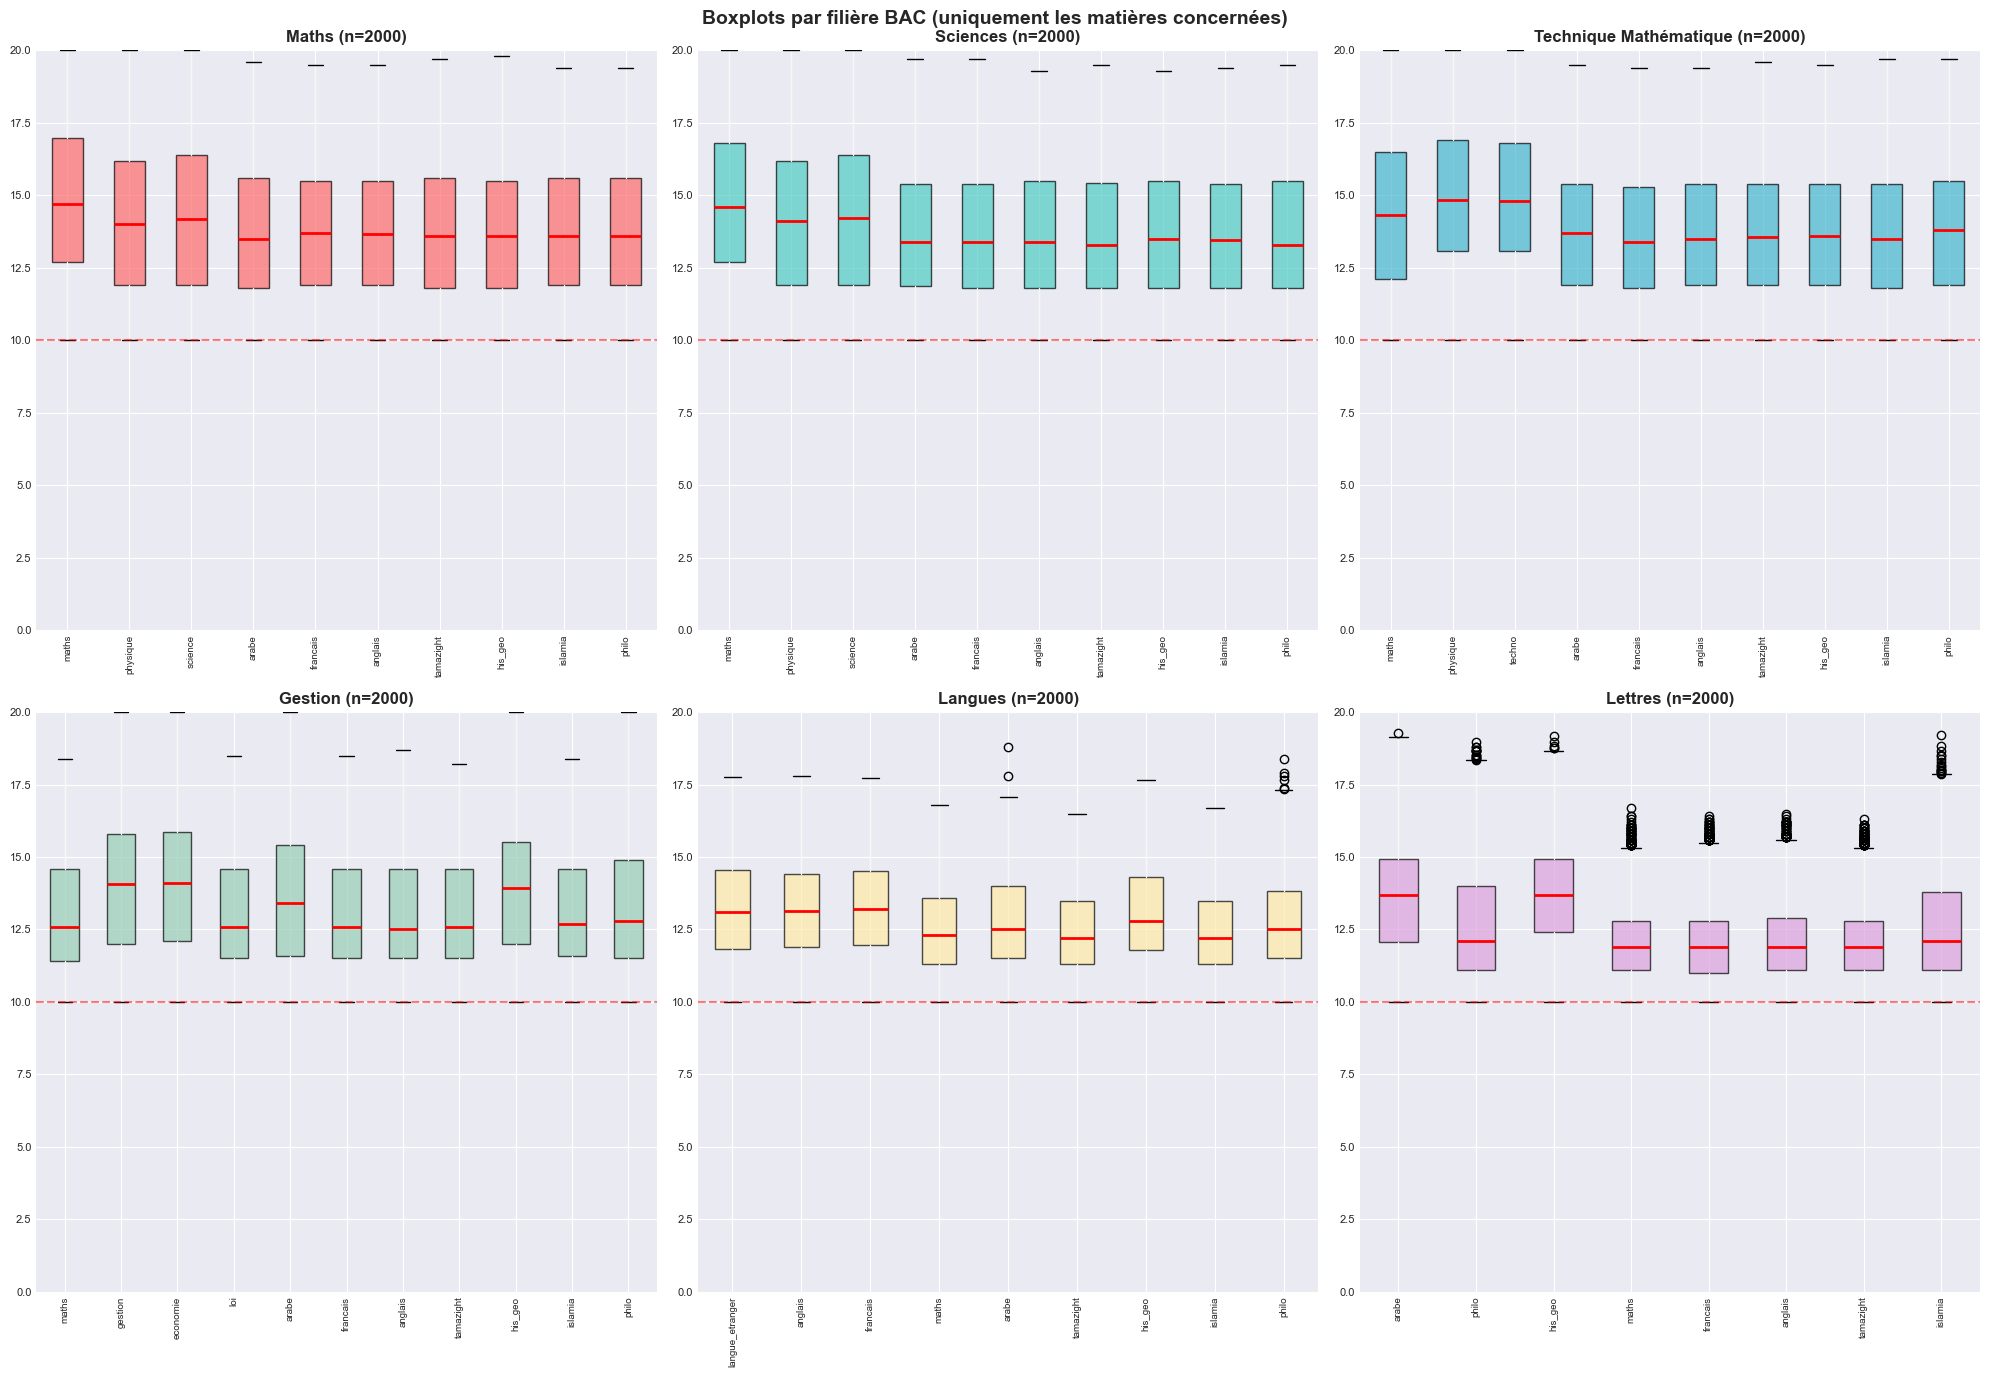

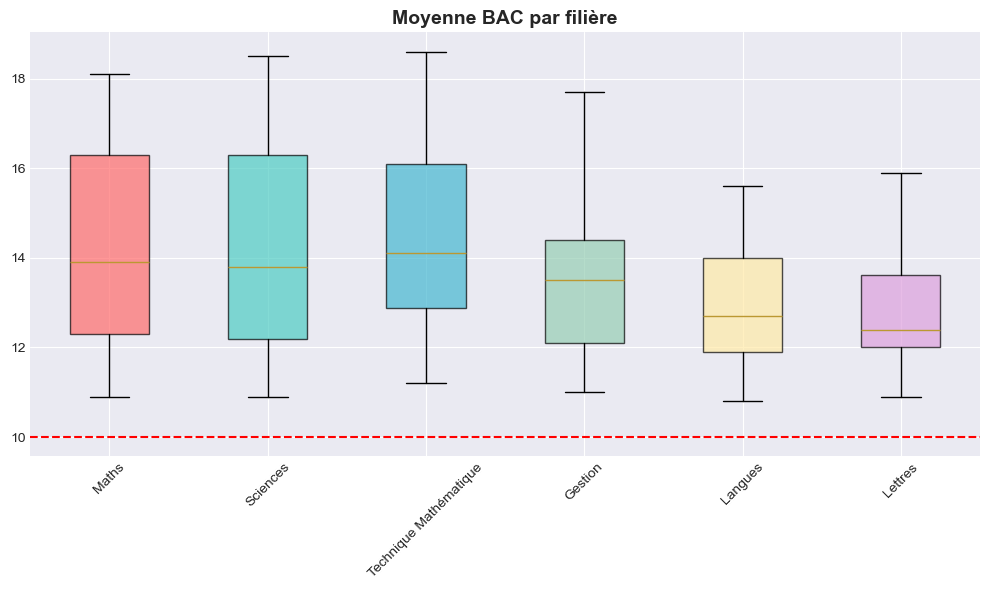


✅ Cell 6.1 done


In [8]:
# CELL 6.1: Boxplots des notes par filière (avec df_all)
# ============================================

print("=" * 60)
print("📊 6.1 - BOXPLOTS PAR FILIÈRE (MATIÈRES CONCERNÉES SEULEMENT)")
print("=" * 60)

# Structure des matières par filière
MATIERES_PAR_FILIERE = {
    'Maths': ['maths_grade', 'physique_grade', 'science_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Sciences': ['maths_grade', 'physique_grade', 'science_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Technique Mathématique': ['maths_grade', 'physique_grade', 'techno_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Gestion': ['maths_grade', 'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Langues': ['langue_etranger_grade', 'anglais_grade', 'francais_grade', 'maths_grade', 'arabe_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Lettres': ['arabe_grade', 'philo_grade', 'his_geo_grade', 'maths_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'islamia_grade']
}

couleurs = {
    'Maths': '#FF6B6B',
    'Sciences': '#4ECDC4',
    'Technique Mathématique': '#45B7D1',
    'Gestion': '#96CEB4',
    'Langues': '#FFEAA7',
    'Lettres': '#DDA0DD'
}

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for i, (filiere, matieres) in enumerate(MATIERES_PAR_FILIERE.items()):
    df_filiere = df_all[df_all['bac_stream'] == filiere]
    
    noms_courts = [m.replace('_grade', '') for m in matieres]
    
    df_filiere[matieres].boxplot(ax=axes[i], rot=90, fontsize=8, patch_artist=True,
        boxprops=dict(facecolor=couleurs[filiere], alpha=0.7),
        medianprops=dict(color='red', linewidth=2))
    
    axes[i].set_title(f'{filiere} (n={len(df_filiere)})', fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 20)
    axes[i].set_xticklabels(noms_courts, fontsize=7)
    axes[i].axhline(y=10, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Boxplots par filière BAC (uniquement les matières concernées)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplot moyenne BAC
fig, ax = plt.subplots(figsize=(10, 6))
filieres = list(MATIERES_PAR_FILIERE.keys())
bp = ax.boxplot([df_all[df_all['bac_stream'] == f]['bac_avg'] for f in filieres], labels=filieres, patch_artist=True)

for i, box in enumerate(bp['boxes']):
    box.set_facecolor(list(couleurs.values())[i])
    box.set_alpha(0.7)

ax.axhline(y=10, color='red', linestyle='--')
ax.set_title('Moyenne BAC par filière', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Cell 6.1 done")

📊 6.2 - DISTRIBUTION DES NOTES PAR MATIÈRE ET PAR FILIÈRE

📊 Sciences


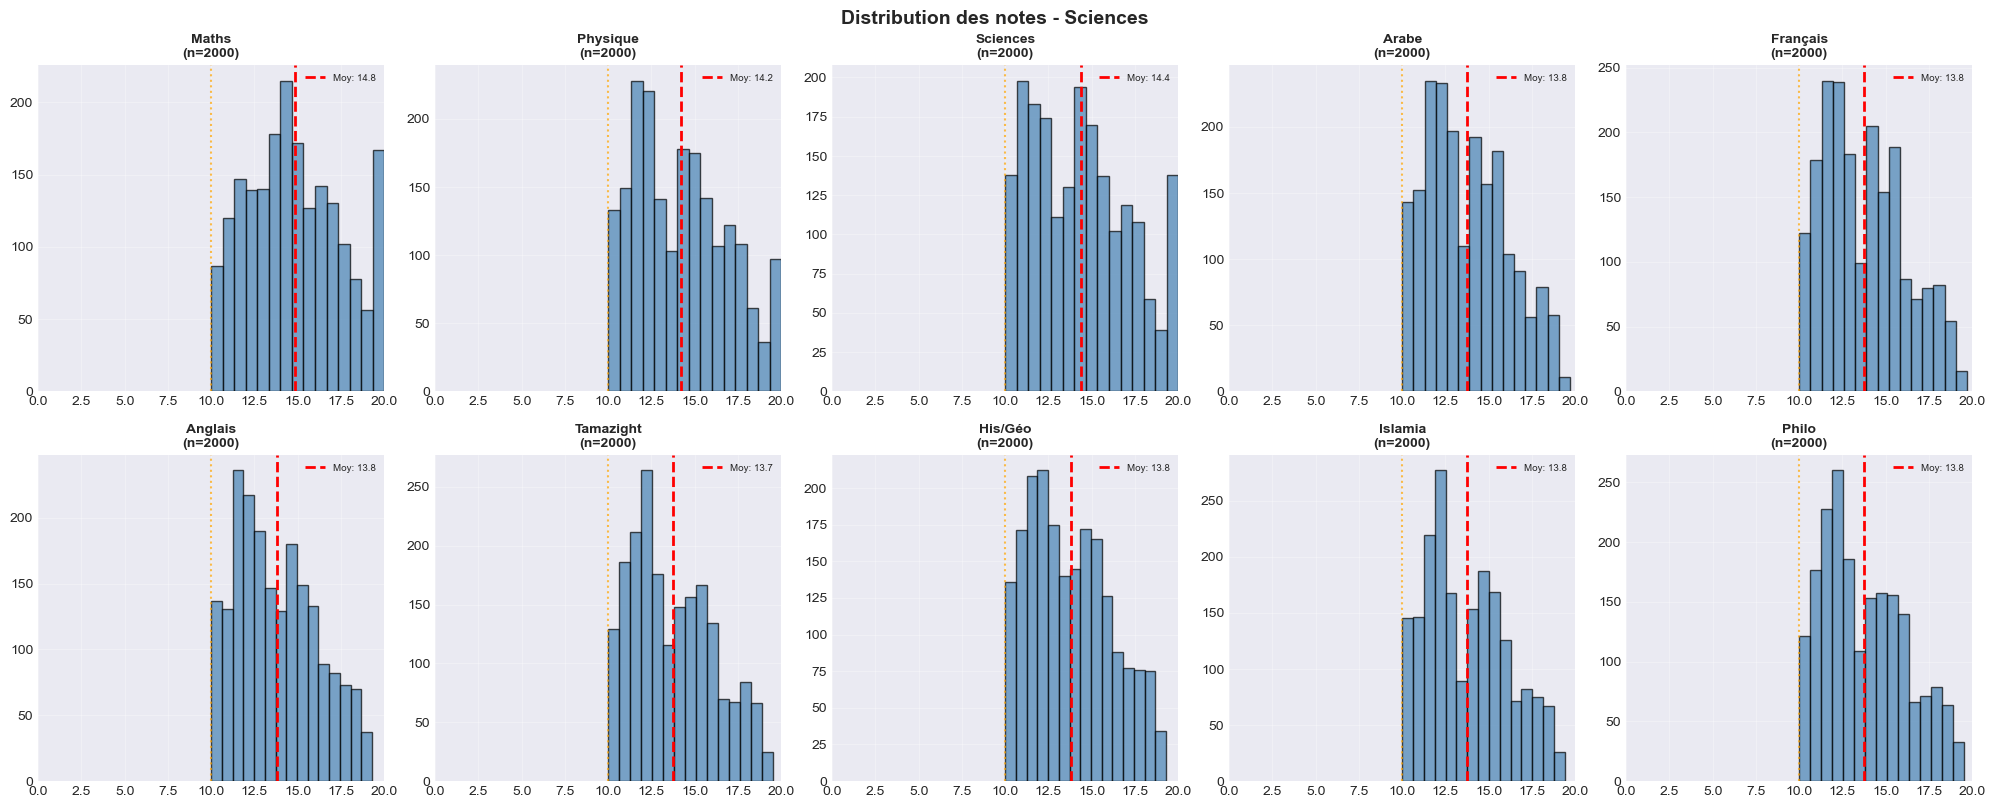


📊 Maths


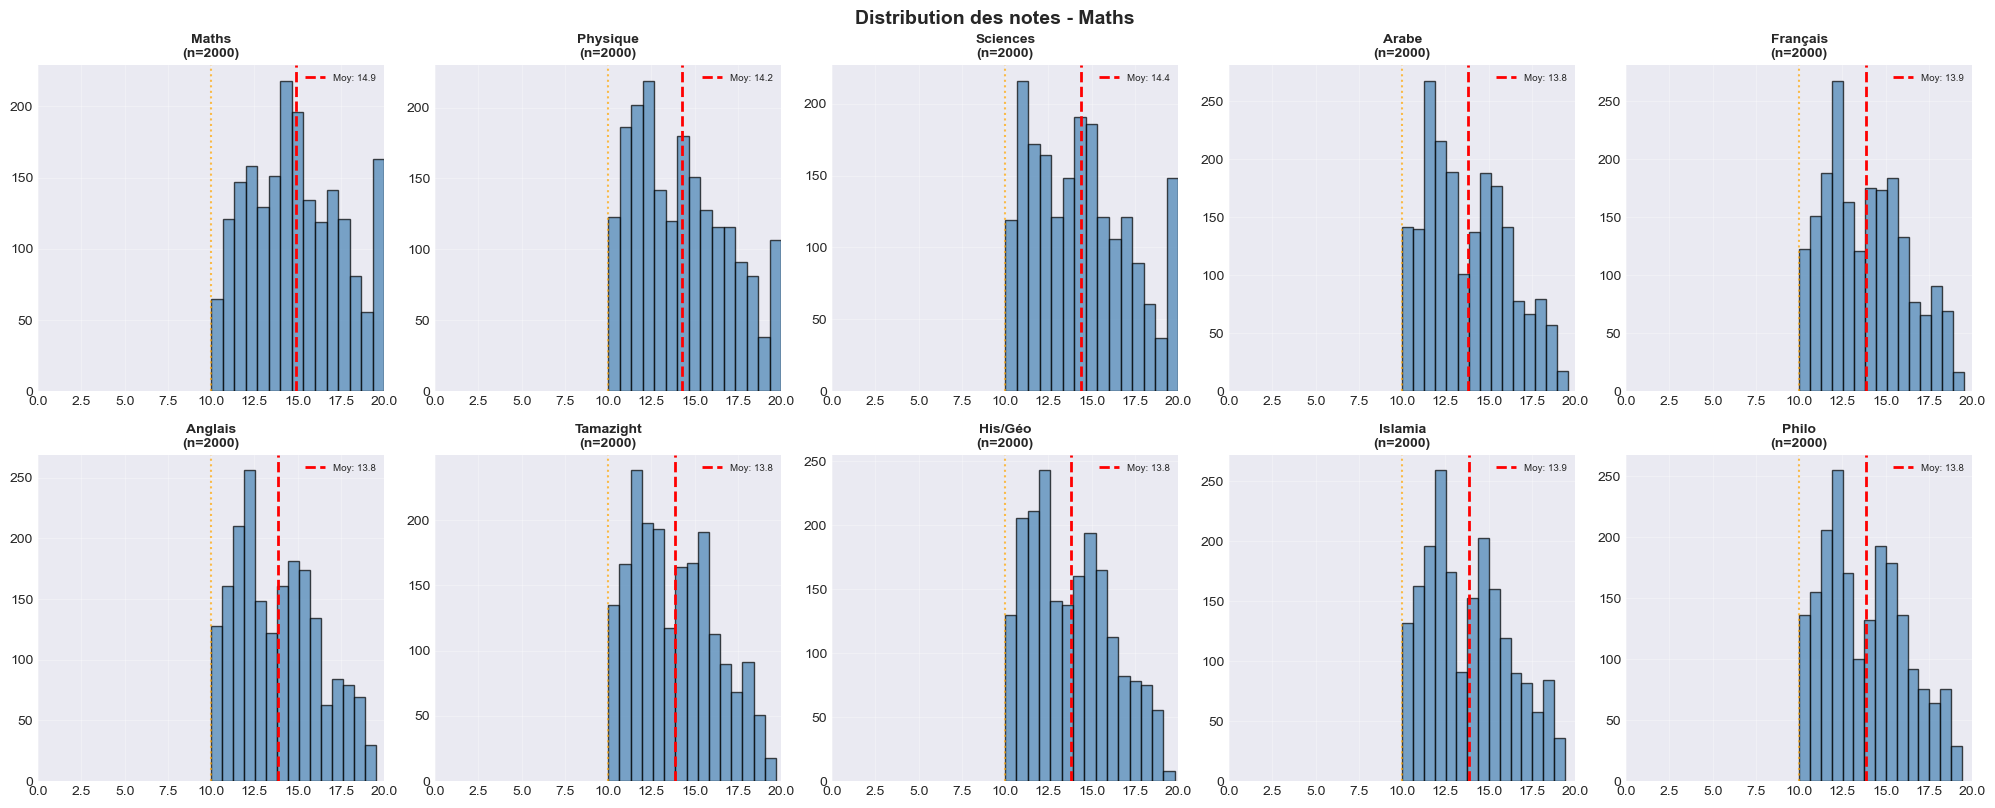


📊 Technique_Mathematique


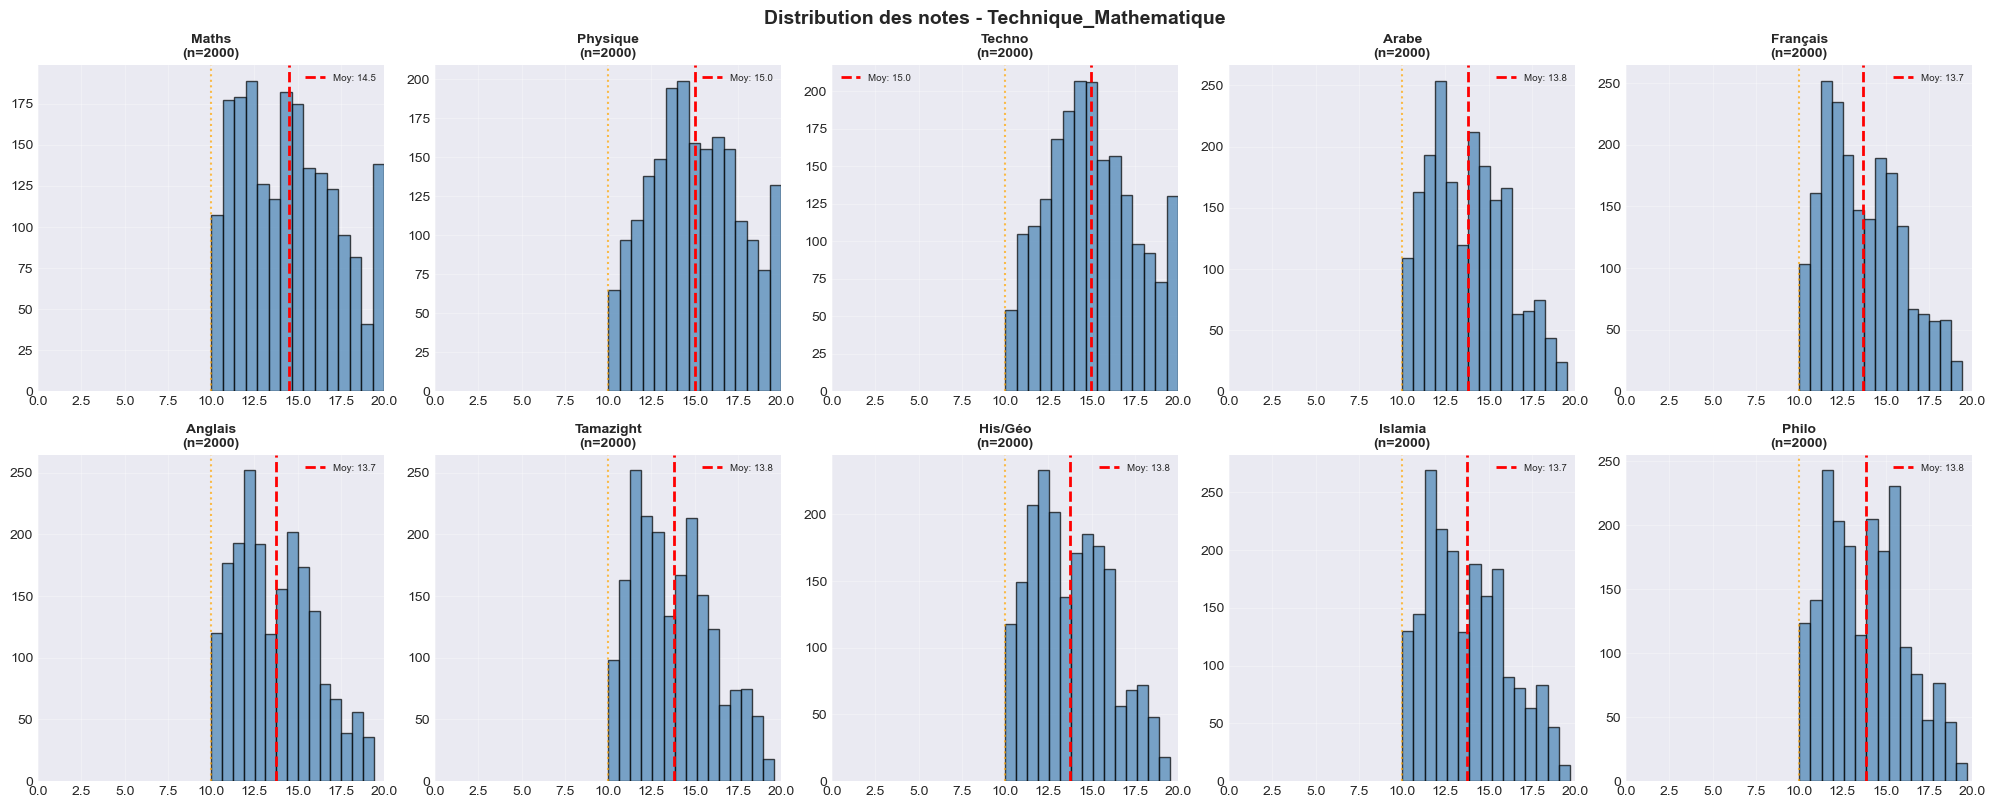


📊 Gestion


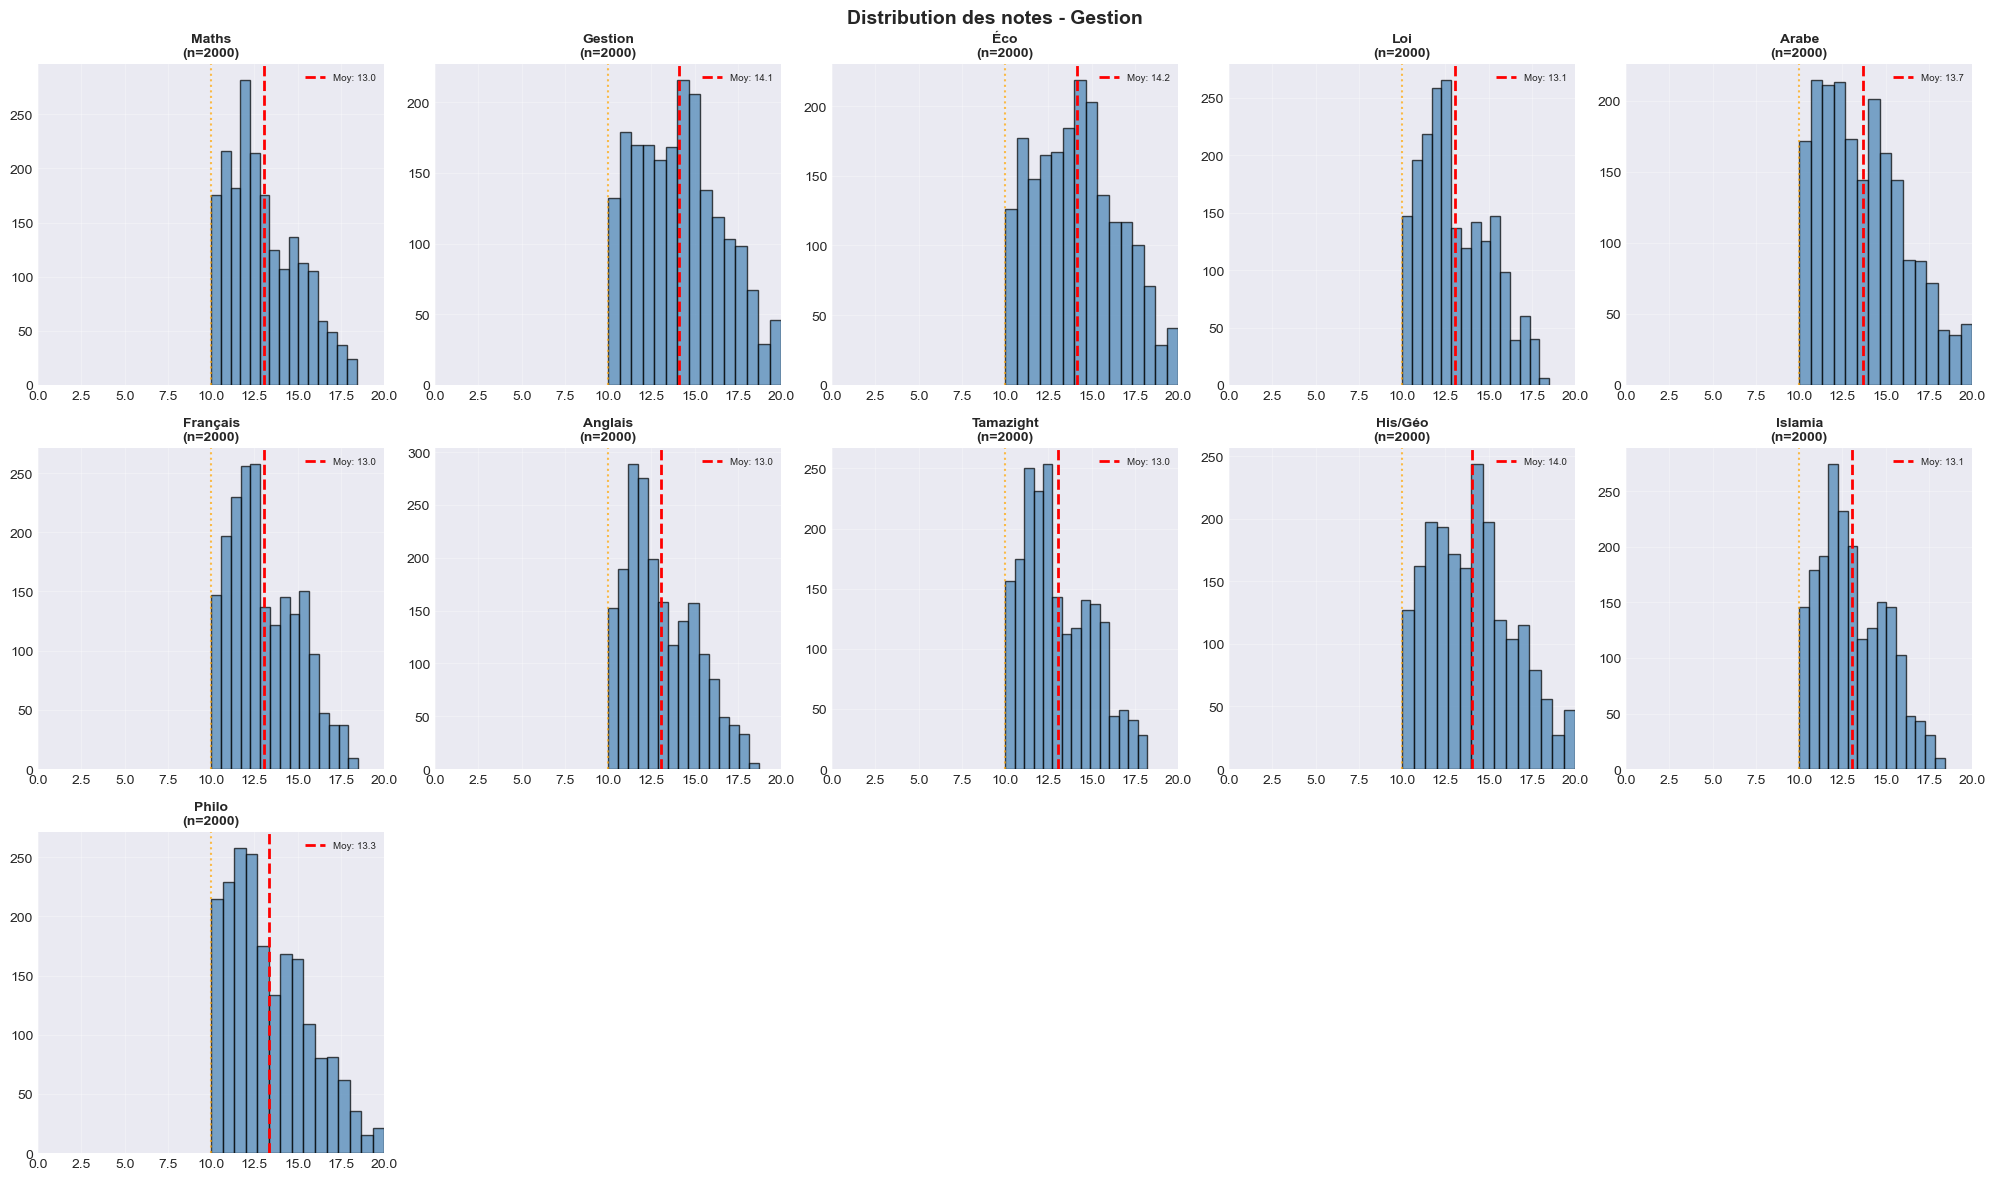


📊 Langues


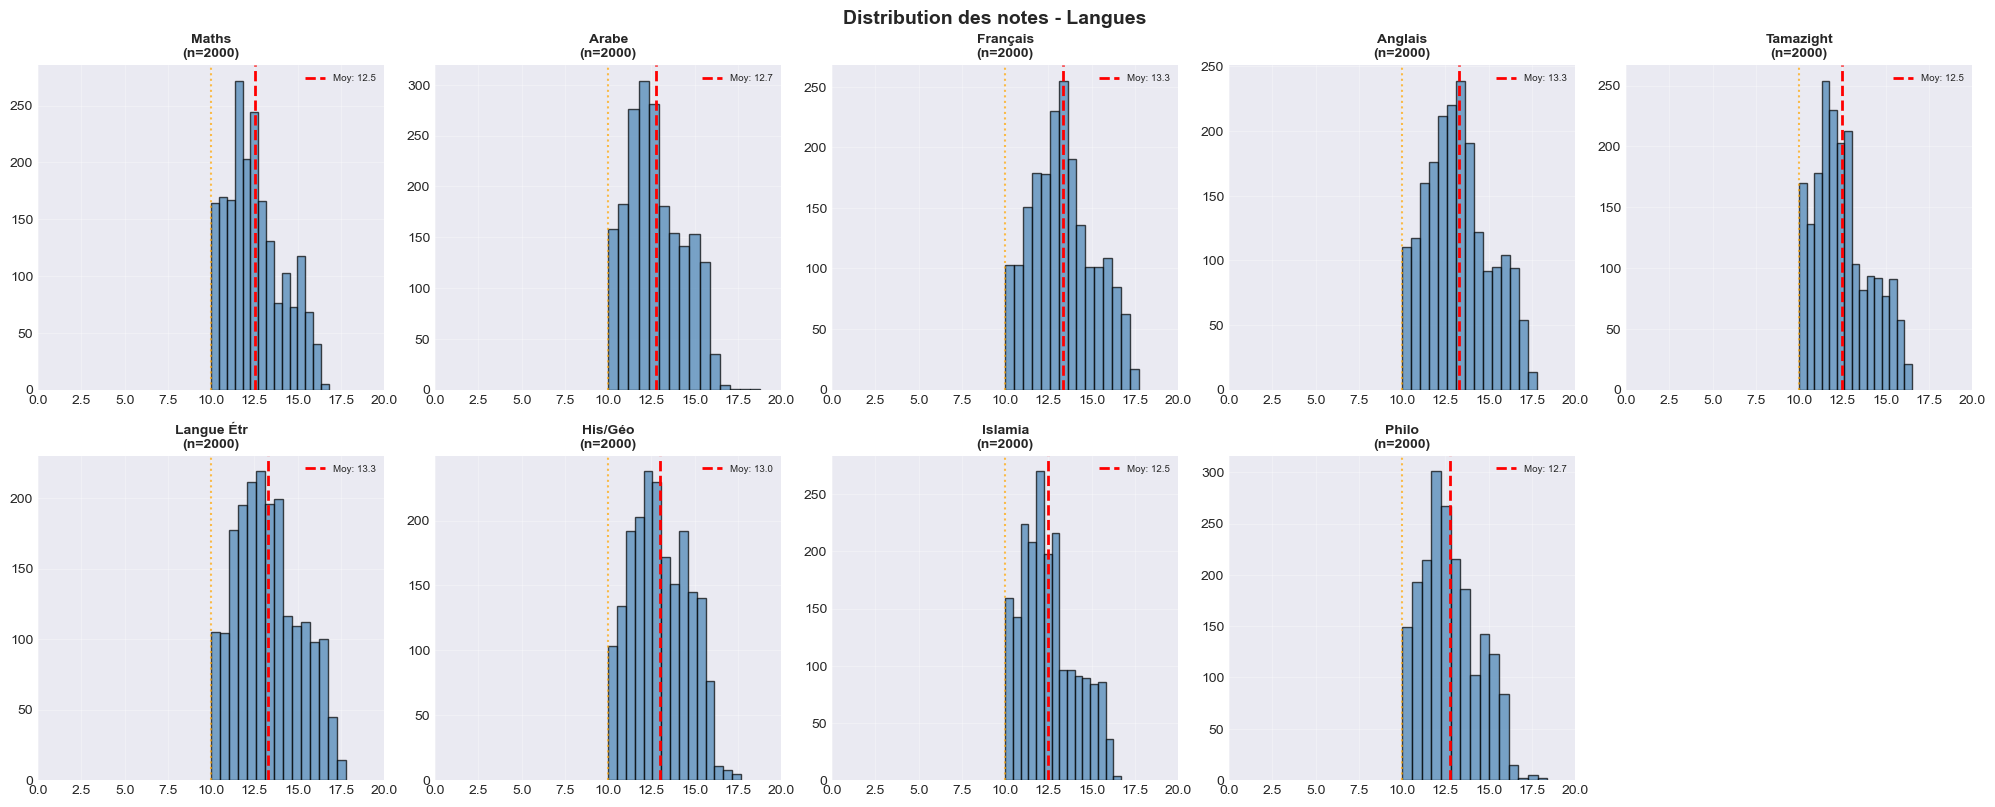


📊 Lettres


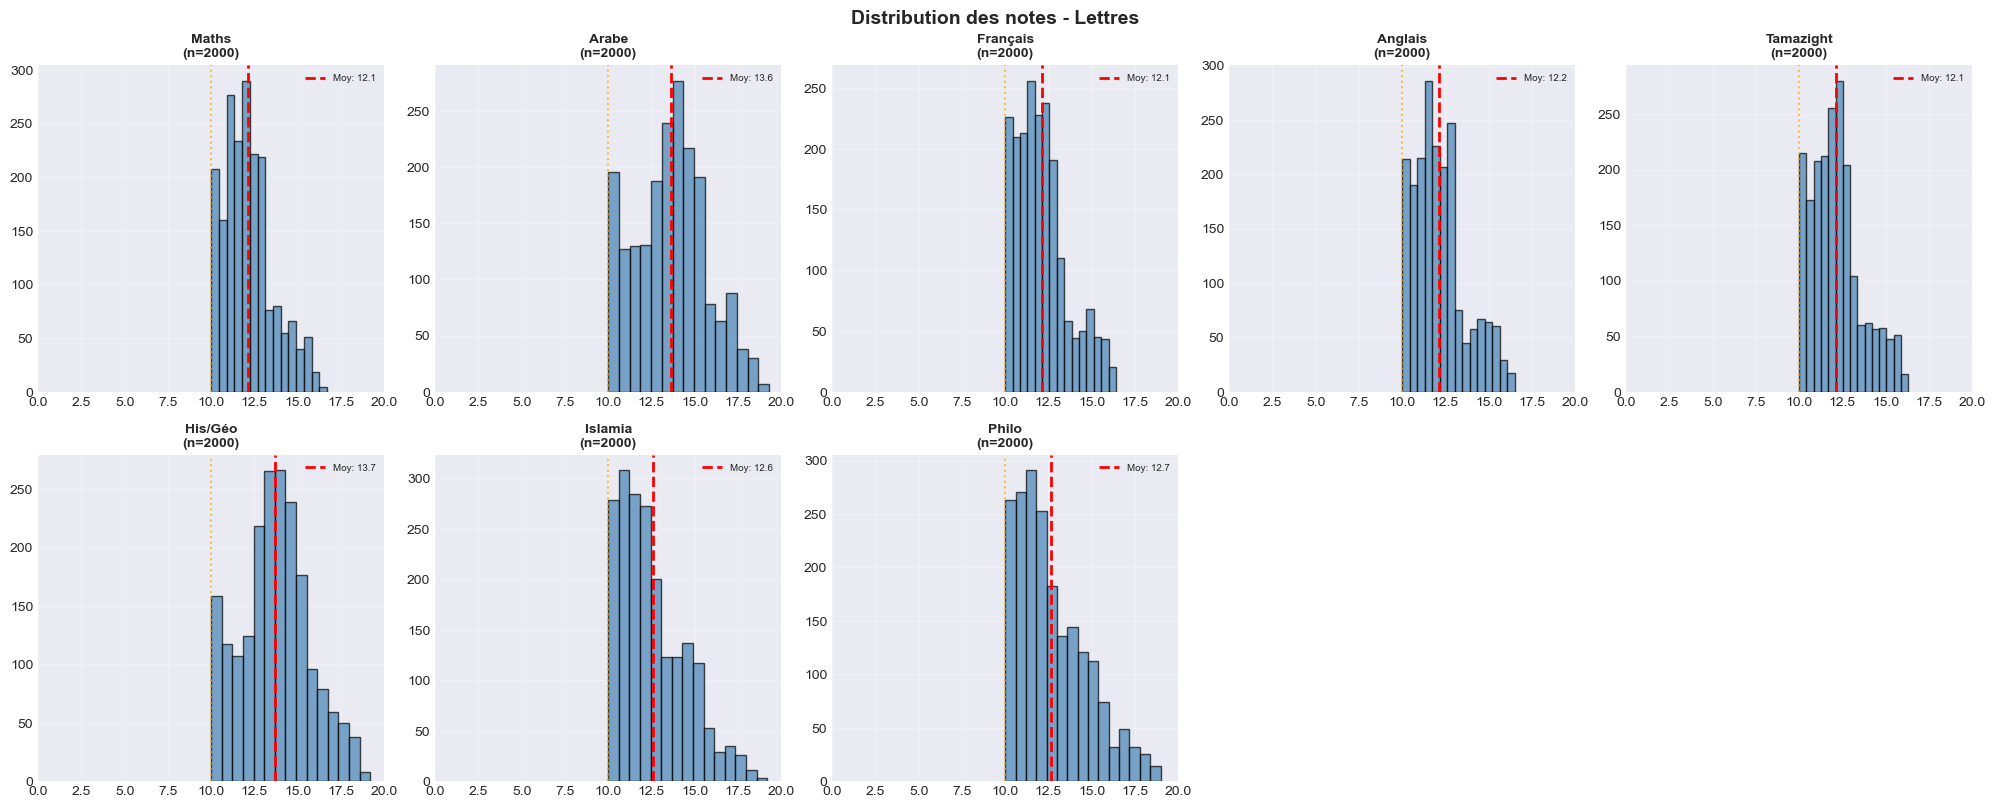


✅ Cell 6.2 done


In [9]:
# CELL 6.2: Distribution des notes par matière POUR CHAQUE FILIÈRE
# ============================================

print("=" * 60)
print("📊 6.2 - DISTRIBUTION DES NOTES PAR MATIÈRE ET PAR FILIÈRE")
print("=" * 60)

noms_matieres = {
    'maths_grade': 'Maths', 'physique_grade': 'Physique', 'science_grade': 'Sciences',
    'techno_grade': 'Techno', 'gestion_grade': 'Gestion', 'economie_grade': 'Éco',
    'loi_grade': 'Loi', 'arabe_grade': 'Arabe', 'francais_grade': 'Français',
    'anglais_grade': 'Anglais', 'tamazight_grade': 'Tamazight', 'langue_etranger_grade': 'Langue Étr',
    'his_geo_grade': 'His/Géo', 'islamia_grade': 'Islamia', 'philo_grade': 'Philo'
}

FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']

# Pour chaque filière, créer une figure
for filiere in FILIERES:
    print(f"\n📊 {filiere}")
    
    # Charger le dataset de la filière
    df_f = pd.read_csv(f"dataset_{filiere}.csv", encoding='utf-8')
    
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()
    
    i = 0
    for matiere, nom in noms_matieres.items():
        data = df_f[df_f[matiere] > 0][matiere].dropna()
        
        if len(data) > 5:
            axes[i].hist(data, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
            axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Moy: {data.mean():.1f}')
            axes[i].axvline(x=10, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
            axes[i].set_title(f"{nom}\n(n={len(data)})", fontsize=10, fontweight='bold')
            axes[i].set_xlim(0, 20)
            axes[i].legend(fontsize=7)
            axes[i].grid(True, alpha=0.3)
            i += 1
    
    for j in range(i, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'Distribution des notes - {filiere}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n✅ Cell 6.2 done")

📊 6.3 - CORRÉLATIONS PAR FILIÈRE (6 ANALYSES)

📌 ANALYSE POUR LA FILIÈRE: Sciences
   Étudiants: 2000

1️⃣ DISTRIBUTION DES DOMAINES CIBLES:
      maths_info: 45.5%
      st: 22.7%
      medecine: 20.6%
      snv: 10.7%
      segc: 0.7%

2️⃣ ANOVA - NOTES QUI DIFFÈRENT SELON LE DOMAINE:
      maths: F=256.28, p=0.0000 ✅
      physique: F=232.18, p=0.0000 ✅
      science: F=332.53, p=0.0000 ✅

3️⃣ MOYENNE BAC PAR DOMAINE:
      snv: 14.66
      segc: 14.48
      medecine: 14.26
      st: 14.07
      maths_info: 13.97

4️⃣ HEATMAP DES CORRÉLATIONS (si features dispo):


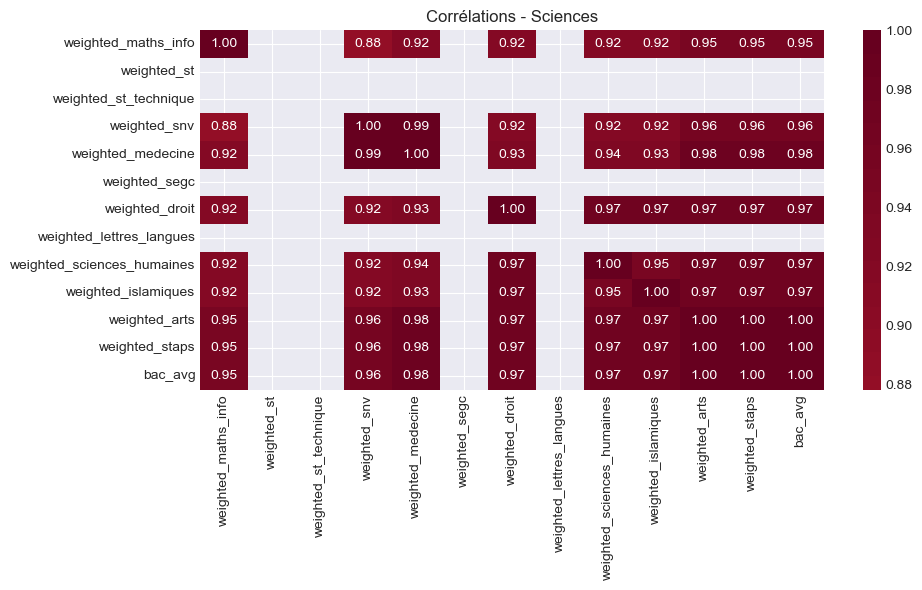


📌 ANALYSE POUR LA FILIÈRE: Maths
   Étudiants: 2000

1️⃣ DISTRIBUTION DES DOMAINES CIBLES:
      maths_info: 44.9%
      medecine: 23.6%
      st: 23.2%
      snv: 7.4%
      segc: 0.9%

2️⃣ ANOVA - NOTES QUI DIFFÈRENT SELON LE DOMAINE:
      maths: F=222.10, p=0.0000 ✅
      physique: F=270.09, p=0.0000 ✅
      science: F=310.76, p=0.0000 ✅

3️⃣ MOYENNE BAC PAR DOMAINE:
      st: 14.43
      snv: 14.31
      maths_info: 14.19
      medecine: 13.98
      segc: 13.92

4️⃣ HEATMAP DES CORRÉLATIONS (si features dispo):


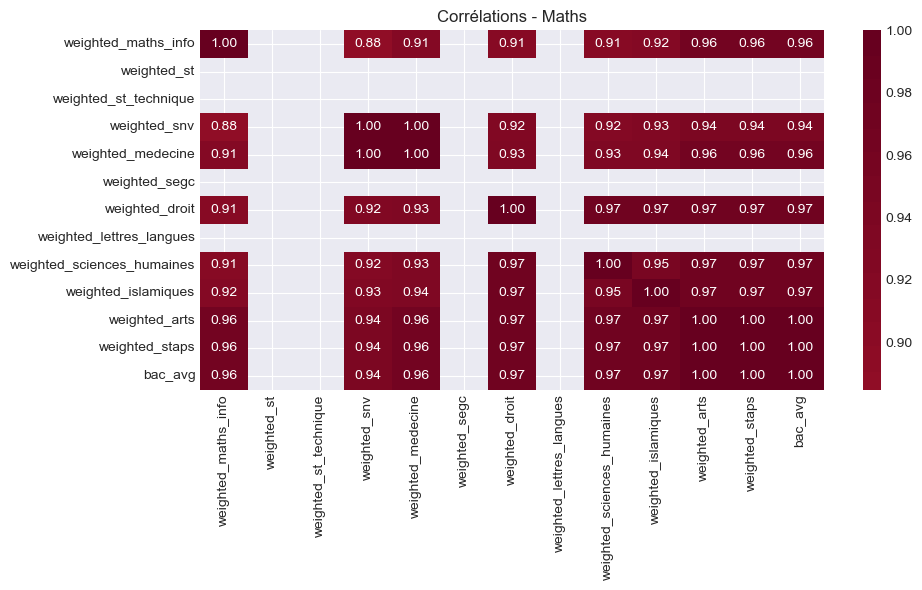


📌 ANALYSE POUR LA FILIÈRE: Technique_Mathematique
   Étudiants: 2000

1️⃣ DISTRIBUTION DES DOMAINES CIBLES:
      st: 62.7%
      maths_info: 37.3%

2️⃣ ANOVA - NOTES QUI DIFFÈRENT SELON LE DOMAINE:
      maths: F=1688.41, p=0.0000 ✅
      physique: F=724.31, p=0.0000 ✅
      arabe: F=6.38, p=0.0116 ✅

3️⃣ MOYENNE BAC PAR DOMAINE:
      st: 14.37
      maths_info: 14.28

4️⃣ HEATMAP DES CORRÉLATIONS (si features dispo):


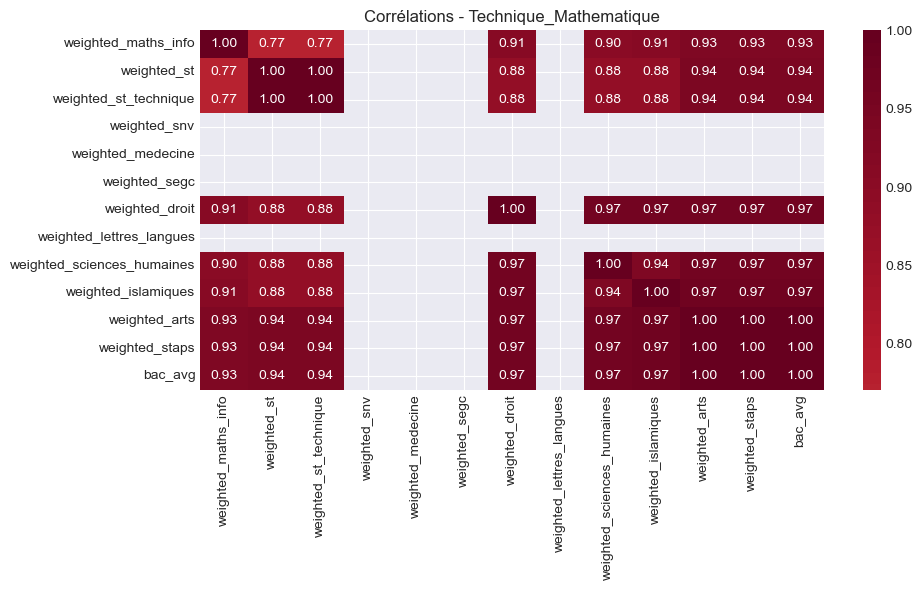


📌 ANALYSE POUR LA FILIÈRE: Gestion
   Étudiants: 2000

1️⃣ DISTRIBUTION DES DOMAINES CIBLES:
      segc: 52.6%
      droit: 31.8%
      sciences_humaines: 15.7%

2️⃣ ANOVA - NOTES QUI DIFFÈRENT SELON LE DOMAINE:
      maths: F=1.40, p=0.2478 ❌
      arabe: F=680.61, p=0.0000 ✅
      philo: F=437.08, p=0.0000 ✅

3️⃣ MOYENNE BAC PAR DOMAINE:
      segc: 13.72
      droit: 13.43
      sciences_humaines: 13.34

4️⃣ HEATMAP DES CORRÉLATIONS (si features dispo):


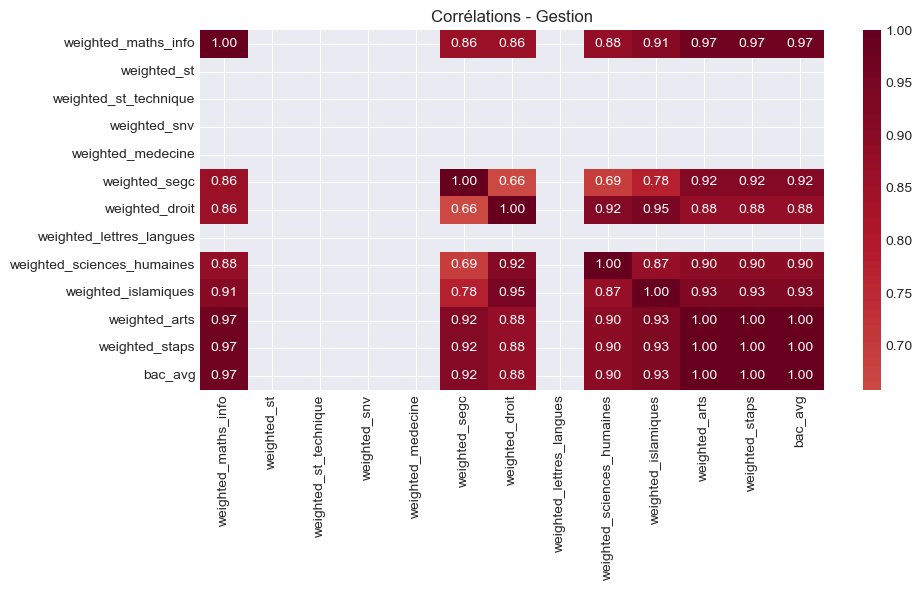


📌 ANALYSE POUR LA FILIÈRE: Langues
   Étudiants: 2000

1️⃣ DISTRIBUTION DES DOMAINES CIBLES:
      lettres_langues: 77.6%
      sciences_humaines: 11.2%
      droit: 11.2%

2️⃣ ANOVA - NOTES QUI DIFFÈRENT SELON LE DOMAINE:
      maths: F=77.81, p=0.0000 ✅
      arabe: F=110.60, p=0.0000 ✅
      philo: F=93.74, p=0.0000 ✅

3️⃣ MOYENNE BAC PAR DOMAINE:
      lettres_langues: 13.27
      droit: 12.01
      sciences_humaines: 11.82

4️⃣ HEATMAP DES CORRÉLATIONS (si features dispo):


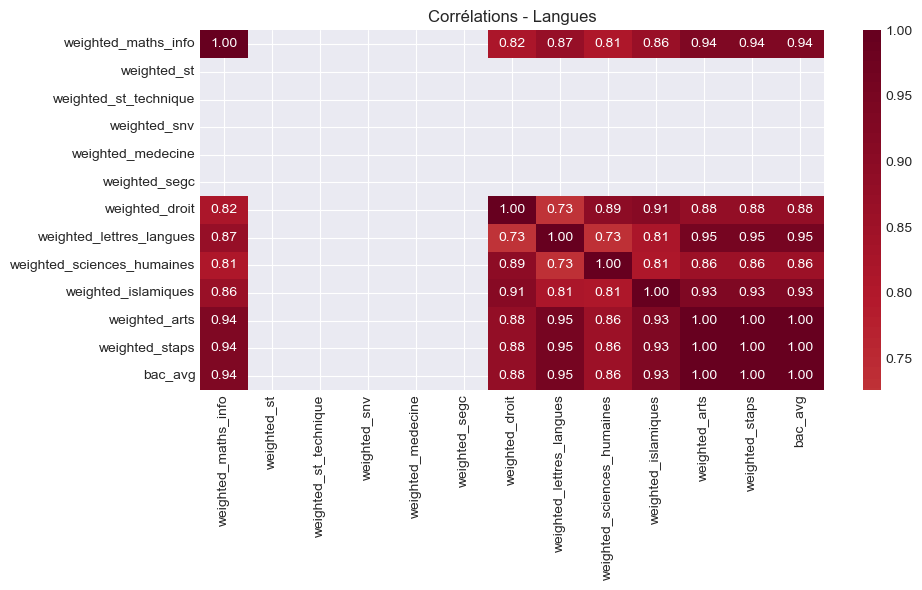


📌 ANALYSE POUR LA FILIÈRE: Lettres
   Étudiants: 2000

1️⃣ DISTRIBUTION DES DOMAINES CIBLES:
      droit: 50.0%
      sciences_humaines: 28.2%
      islamiques: 21.8%

2️⃣ ANOVA - NOTES QUI DIFFÈRENT SELON LE DOMAINE:
      maths: F=3.74, p=0.0240 ✅
      arabe: F=947.18, p=0.0000 ✅
      philo: F=1260.58, p=0.0000 ✅

3️⃣ MOYENNE BAC PAR DOMAINE:
      sciences_humaines: 12.93
      droit: 12.81
      islamiques: 12.70

4️⃣ HEATMAP DES CORRÉLATIONS (si features dispo):


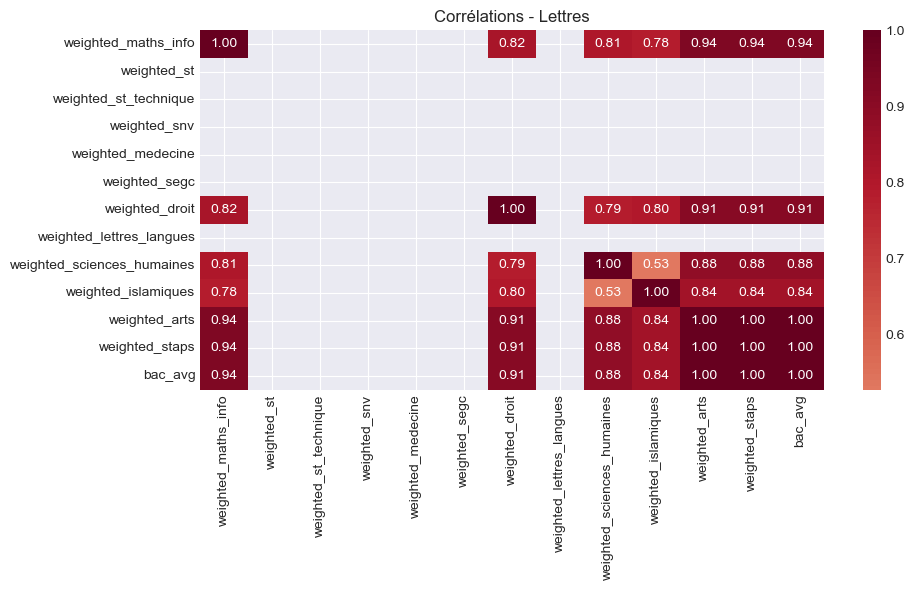


✅ Cell 6.3 terminée - 6 analyses effectuées


In [7]:
# CELL 6.3: Étude de corrélation POUR CHAQUE FILIÈRE (6 analyses)
# ============================================

from scipy.stats import chi2_contingency, f_oneway
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("📊 6.3 - CORRÉLATIONS PAR FILIÈRE (6 ANALYSES)")
print("=" * 60)

FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']

for filiere in FILIERES:
    print("\n" + "=" * 70)
    print(f"📌 ANALYSE POUR LA FILIÈRE: {filiere}")
    print("=" * 70)
    
    # Charger le dataset de la filière
    df_f = pd.read_csv(f"dataset_{filiere}.csv", encoding='utf-8')
    print(f"   Étudiants: {len(df_f)}")
    
    # ========================================
    # 1. Distribution des domaines cibles
    # ========================================
    print("\n1️⃣ DISTRIBUTION DES DOMAINES CIBLES:")
    domaine_counts = df_f['domaine_cible'].value_counts(normalize=True) * 100
    for domaine, pct in domaine_counts.head(5).items():
        print(f"      {domaine}: {pct:.1f}%")
    
    # ========================================
    # 2. Relation entre les notes et le domaine (ANOVA)
    # ========================================
    print("\n2️⃣ ANOVA - NOTES QUI DIFFÈRENT SELON LE DOMAINE:")
    
    matieres_a_tester = ['maths_grade', 'physique_grade', 'science_grade', 'arabe_grade', 'philo_grade']
    matieres_presentes = [m for m in matieres_a_tester if m in df_f.columns and df_f[m].notna().any()]
    
    for matiere in matieres_presentes[:3]:  # Top 3
        groupes = [df_f[df_f['domaine_cible'] == d][matiere].dropna().values 
                   for d in df_f['domaine_cible'].unique() if len(df_f[df_f['domaine_cible'] == d][matiere].dropna()) > 0]
        if len(groupes) > 1:
            f_stat, p_val = f_oneway(*groupes)
            print(f"      {matiere.replace('_grade', '')}: F={f_stat:.2f}, p={p_val:.4f} {'✅' if p_val < 0.05 else '❌'}")
    
    # ========================================
    # 3. Moyenne BAC par domaine
    # ========================================
    print("\n3️⃣ MOYENNE BAC PAR DOMAINE:")
    moyennes = df_f.groupby('domaine_cible')['bac_avg'].mean().sort_values(ascending=False).head(5)
    for domaine, moy in moyennes.items():
        print(f"      {domaine}: {moy:.2f}")
    
    # ========================================
    # 4. Heatmap de corrélation (si weighted averages existent)
    # ========================================
    print("\n4️⃣ HEATMAP DES CORRÉLATIONS (si features dispo):")
    
    # Chercher les fichiers features si existants
    try:
        df_features = pd.read_csv(f"features_{filiere}.csv", encoding='utf-8')
        weighted_cols = [c for c in df_features.columns if c.startswith('weighted_')]
        if weighted_cols:
            fig, ax = plt.subplots(figsize=(10, 6))
            corr_matrix = df_features[weighted_cols + ['bac_avg']].corr()
            sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
            ax.set_title(f'Corrélations - {filiere}', fontsize=12)
            plt.tight_layout()
            plt.show()
        else:
            print("      ⚠️ Weighted averages non trouvés")
    except:
        print("      ⚠️ Fichier features non trouvé (exécute d'abord Cell 5.5)")

print("\n" + "=" * 60)
print("✅ Cell 6.3 terminée - 6 analyses effectuées")
print("=" * 60)

📊 6.4 - ANALYSE PAR DOMAINE (TOUTES FILIÈRES)

📋 Classement des domaines par moyenne BAC:
                   Moyenne BAC  Nb étudiants
domaine_cible                               
snv                      14.51           361
st                       14.32          2172
maths_info               14.14          2552
medecine                 14.11           885
segc                     13.74          1082
lettres_langues          13.27          1552
droit                    12.92          1858
sciences_humaines        12.82          1102
islamiques               12.70           436


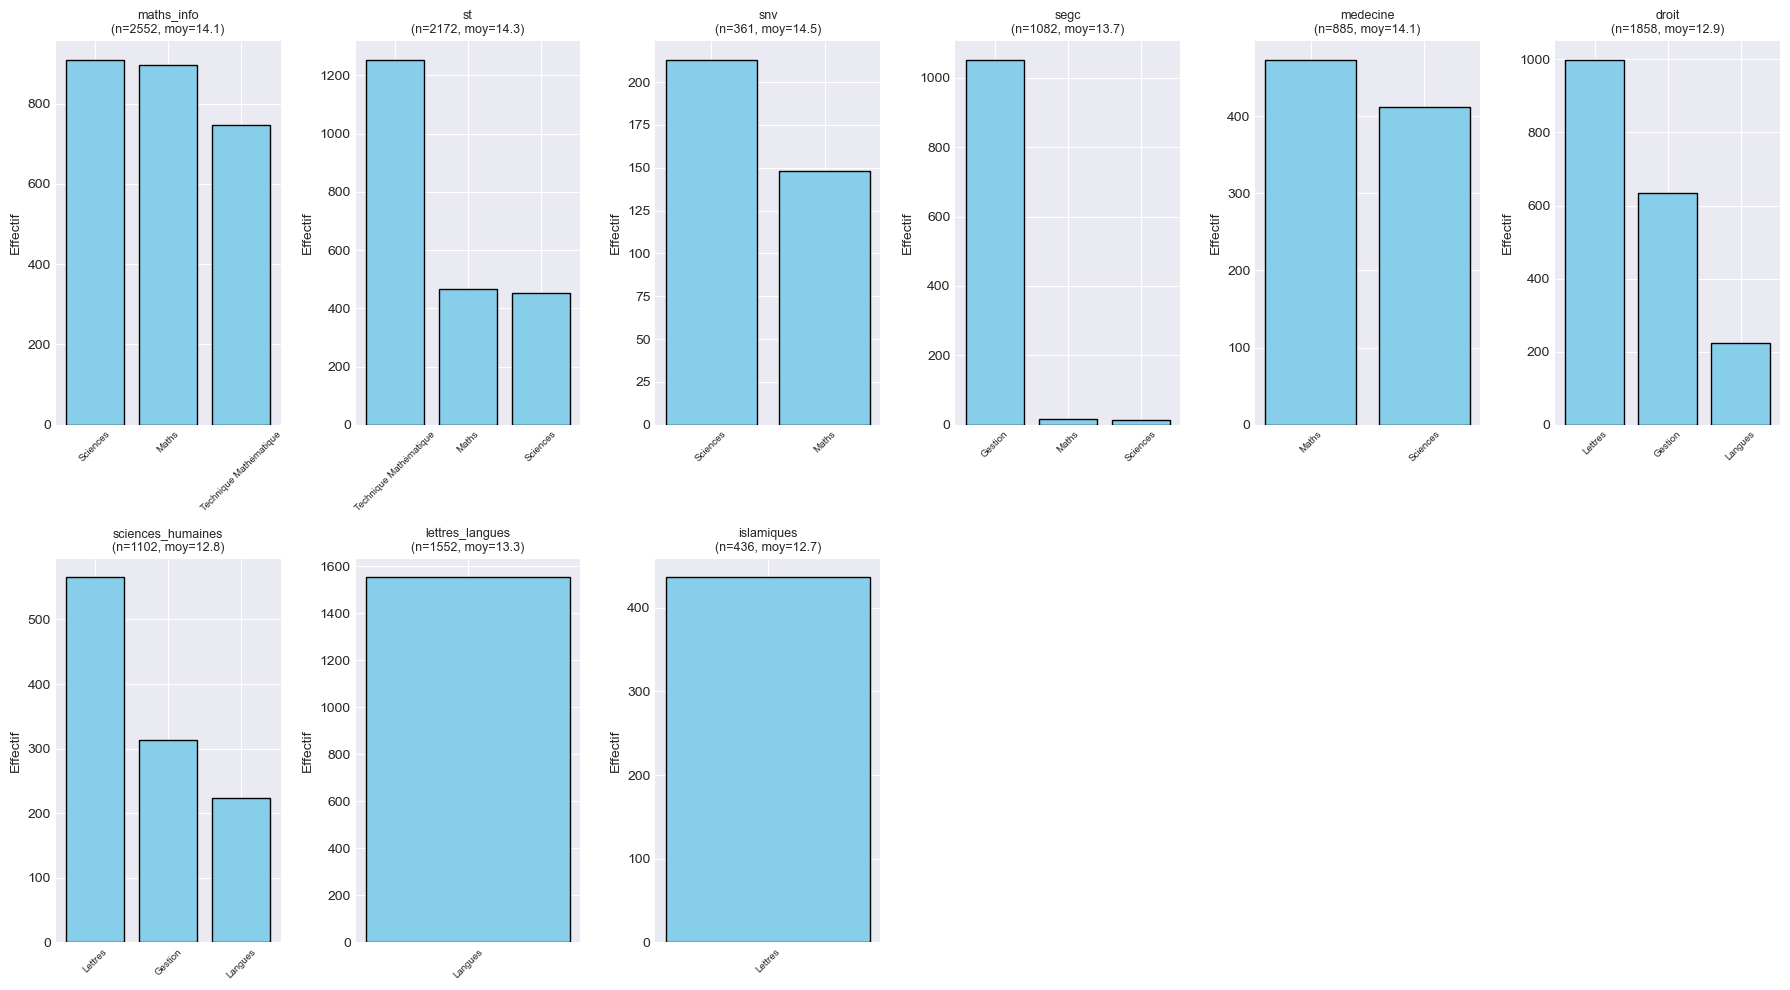


✅ Cell 6.4 done → Run Cell 6.5


In [10]:
# CELL 6.4: Analyse par domaine (filière d'origine + moyenne BAC) - avec df_all
# ============================================

print("=" * 60)
print("📊 6.4 - ANALYSE PAR DOMAINE (TOUTES FILIÈRES)")
print("=" * 60)

# Concaténer les 6 datasets si pas déjà fait
if 'df_all' not in dir():
    FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']
    df_all = pd.concat([pd.read_csv(f"dataset_{f}.csv") for f in FILIERES], ignore_index=True)
    print("✅ Datasets concaténés")

df = df_all

# Stats par domaine
stats = df.groupby('domaine_cible').agg({
    'bac_avg': ['mean', 'count']
}).round(2)
stats.columns = ['Moyenne BAC', 'Nb étudiants']
stats = stats.sort_values('Moyenne BAC', ascending=False)

print("\n📋 Classement des domaines par moyenne BAC:")
print(stats)

# Graphique: pour chaque domaine, filière d'origine
fig, axes = plt.subplots(2, 6, figsize=(18, 10))
axes = axes.flatten()

for i, domaine in enumerate(df['domaine_cible'].unique()):
    df_dom = df[df['domaine_cible'] == domaine]
    filieres = df_dom['bac_stream'].value_counts()
    
    axes[i].bar(filieres.index, filieres.values, color='skyblue', edgecolor='black')
    axes[i].set_title(f'{domaine}\n(n={len(df_dom)}, moy={df_dom["bac_avg"].mean():.1f})', fontsize=9)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].set_ylabel('Effectif')

# Cacher les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ Cell 6.4 done → Run Cell 6.5")

📊 6.5 - NIVEAUX PAR FILIÈRE (EXCELLENT, BON, MOYEN)

🥧 RÉPARTITION GLOBALE DES NIVEAUX:
niveau
Bon          5092
Moyen        5005
Excellent    1903
Name: count, dtype: int64


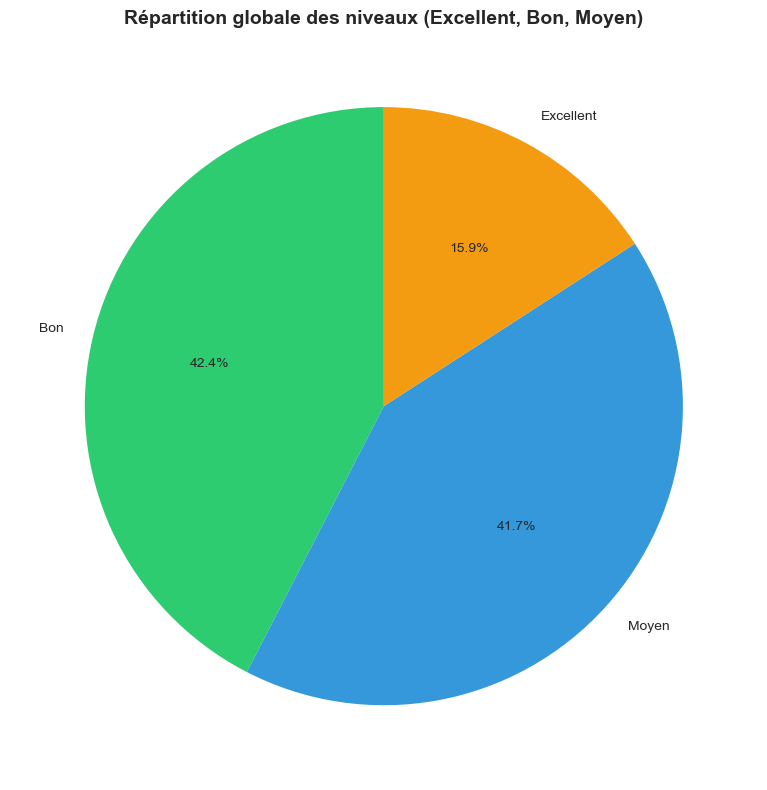


🥧 RÉPARTITION DES NIVEAUX PAR FILIÈRE:


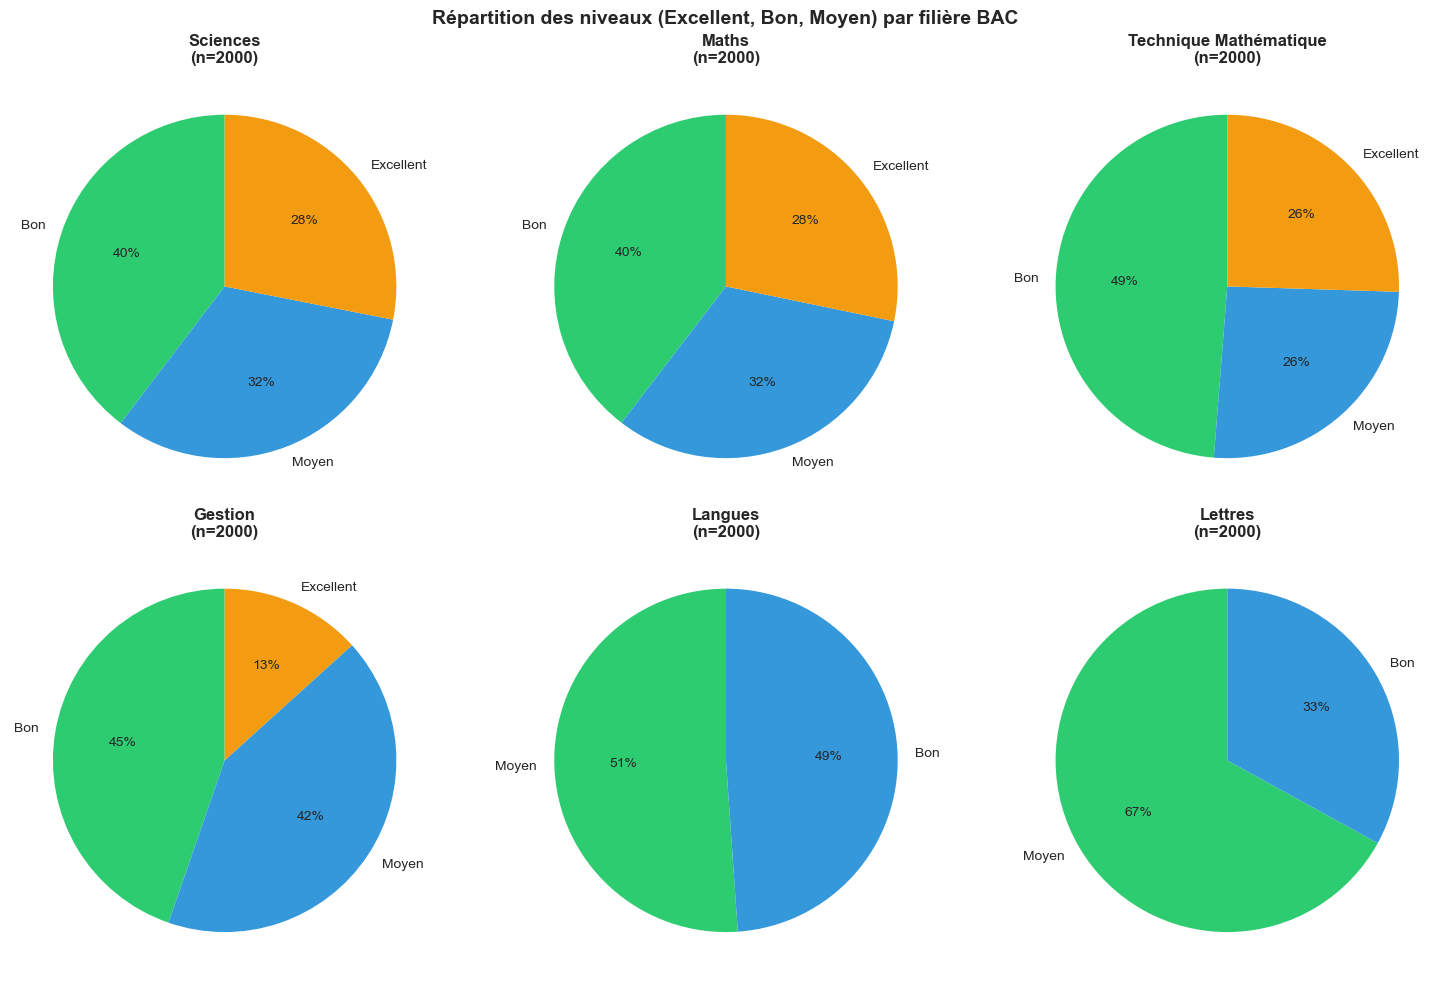


📊 HEATMAP DES PROPORTIONS PAR FILIÈRE ET NIVEAU:


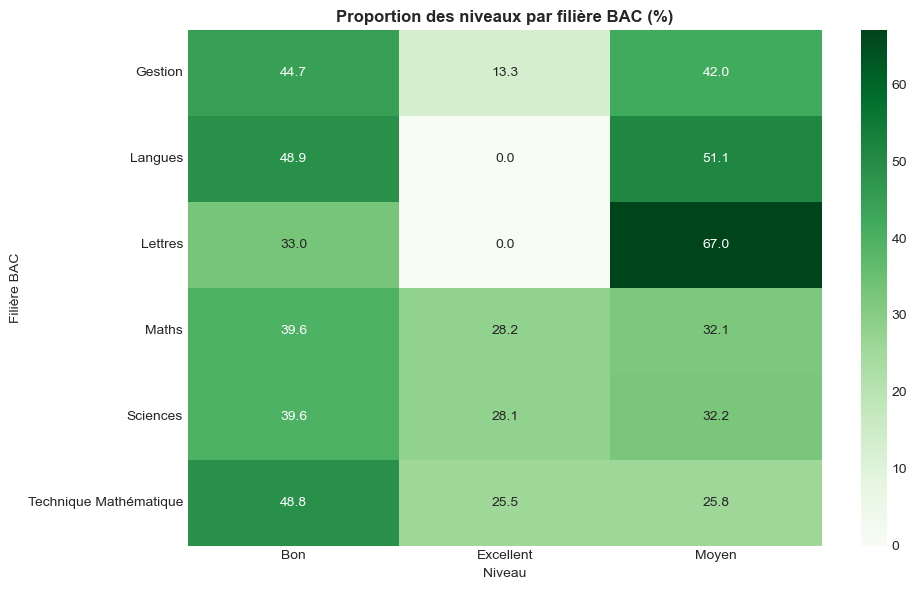


✅ Cell 6.5 done → Run Cell 6.6


In [9]:
# CELL 6.5: Proportions des niveaux (Excellent, Bon, Moyen) par filière
# ============================================

print("=" * 60)
print("📊 6.5 - NIVEAUX PAR FILIÈRE (EXCELLENT, BON, MOYEN)")
print("=" * 60)

# Concaténer les 6 datasets si pas déjà fait
if 'df_all' not in dir():
    FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']
    df_all = pd.concat([pd.read_csv(f"dataset_{f}.csv") for f in FILIERES], ignore_index=True)
    print("✅ Datasets concaténés")

df = df_all

# Définir les niveaux
def get_niveau(bac_avg):
    if bac_avg >= 16:
        return 'Excellent'
    elif bac_avg >= 13:
        return 'Bon'
    else:
        return 'Moyen'

df['niveau'] = df['bac_avg'].apply(get_niveau)

# 1. Répartition globale des niveaux
print("\n🥧 RÉPARTITION GLOBALE DES NIVEAUX:")
global_niveaux = df['niveau'].value_counts()
print(global_niveaux)

fig, ax = plt.subplots(figsize=(8, 8))
colors_niveaux = ['#2ecc71', '#3498db', '#f39c12']
ax.pie(global_niveaux.values, labels=global_niveaux.index, autopct='%1.1f%%', 
       colors=colors_niveaux, startangle=90)
ax.set_title('Répartition globale des niveaux (Excellent, Bon, Moyen)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Secteurs par filière (pie charts pour chaque filière)
print("\n🥧 RÉPARTITION DES NIVEAUX PAR FILIÈRE:")

FILIERES = df['bac_stream'].unique()
n_filieres = len(FILIERES)
n_cols = 3
n_rows = (n_filieres + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()
colors_niveaux = ['#2ecc71', '#3498db', '#f39c12']

for i, filiere in enumerate(FILIERES):
    df_f = df[df['bac_stream'] == filiere]
    niveaux_counts = df_f['niveau'].value_counts()
    
    axes[i].pie(niveaux_counts.values, labels=niveaux_counts.index, autopct='%1.0f%%',
                colors=colors_niveaux, startangle=90)
    axes[i].set_title(f'{filiere}\n(n={len(df_f)})', fontsize=12, fontweight='bold')

# Cacher les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Répartition des niveaux (Excellent, Bon, Moyen) par filière BAC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Heatmap des proportions par filière et niveau
print("\n📊 HEATMAP DES PROPORTIONS PAR FILIÈRE ET NIVEAU:")

cross_tab_niveaux = pd.crosstab(df['bac_stream'], df['niveau'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cross_tab_niveaux, annot=True, fmt='.1f', cmap='Greens', ax=ax)
ax.set_title('Proportion des niveaux par filière BAC (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Niveau')
ax.set_ylabel('Filière BAC')
plt.tight_layout()
plt.show()

print("\n✅ Cell 6.5 done → Run Cell 6.6")

📊 6.6 - SECTEURS PAR DOMAINE


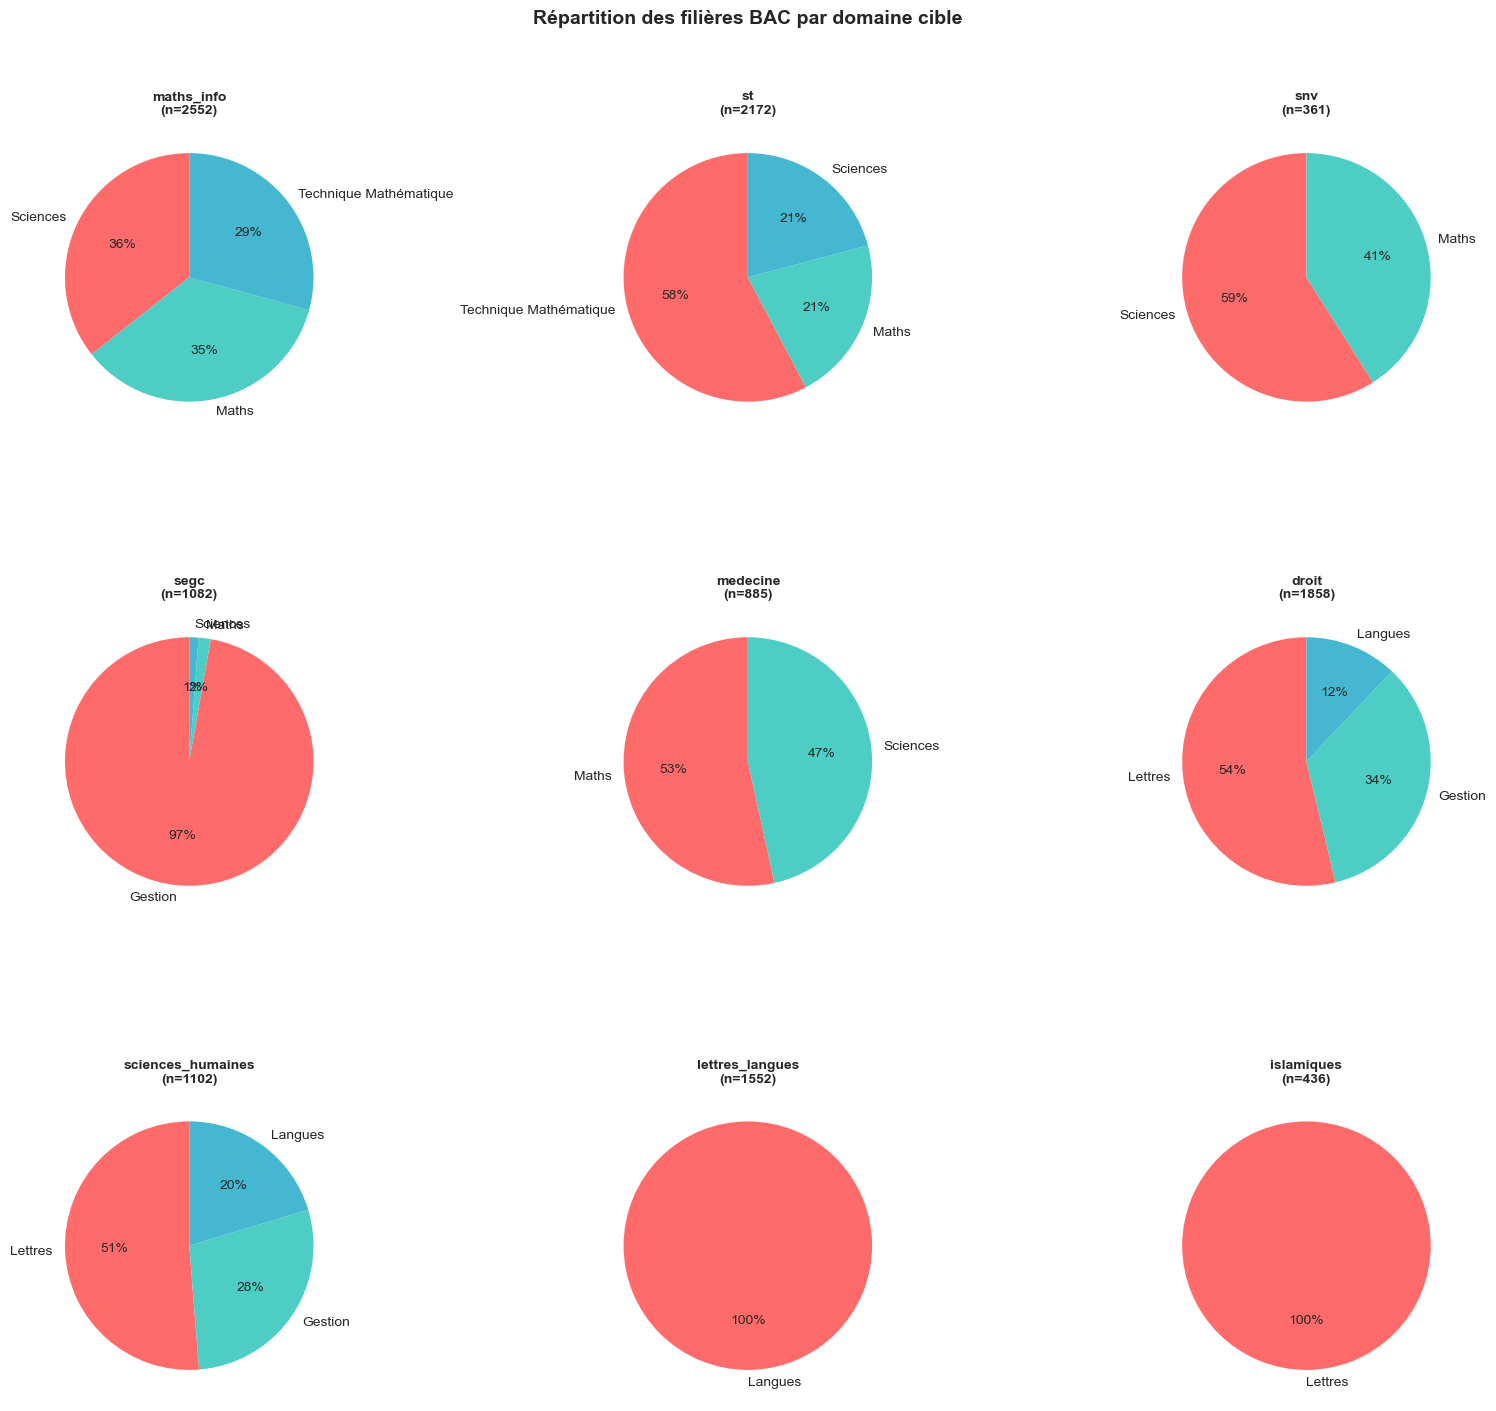


📊 Version alternative (heatmap):


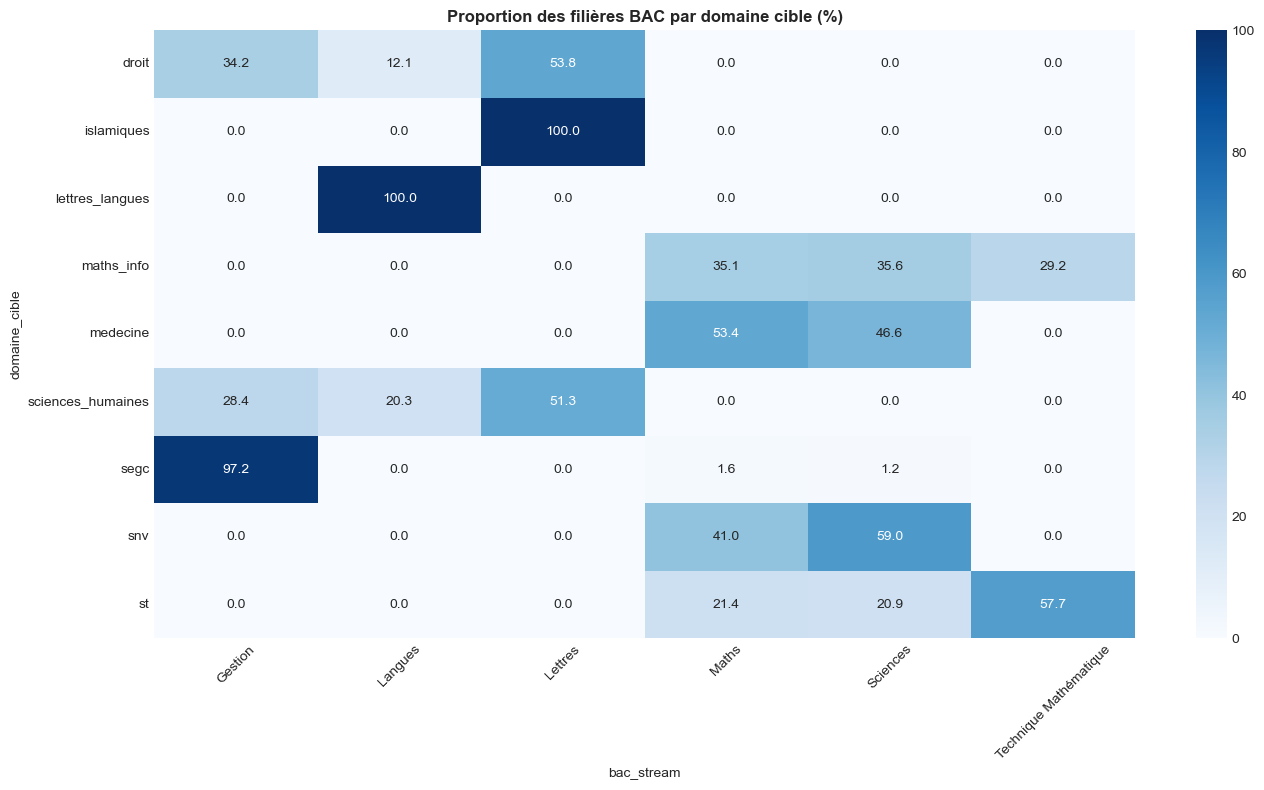


✅ Cell 6.6 done


In [10]:
# CELL 6.6: Secteurs par domaine (répartition des filières) - avec df_all
# ============================================

print("=" * 60)
print("📊 6.6 - SECTEURS PAR DOMAINE")
print("=" * 60)

# Concaténer les 6 datasets si pas déjà fait
if 'df_all' not in dir():
    FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']
    df_all = pd.concat([pd.read_csv(f"dataset_{f}.csv") for f in FILIERES], ignore_index=True)
    print("✅ Datasets concaténés")

df = df_all

domaines = df['domaine_cible'].unique()
n_domaines = len(domaines)

# Grille de pie charts
n_cols = 3
n_rows = (n_domaines + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

for i, domaine in enumerate(domaines):
    df_dom = df[df['domaine_cible'] == domaine]
    filieres_props = df_dom['bac_stream'].value_counts()
    
    axes[i].pie(filieres_props.values, labels=filieres_props.index, autopct='%1.0f%%',
                colors=colors[:len(filieres_props)], startangle=90)
    axes[i].set_title(f'{domaine}\n(n={len(df_dom)})', fontsize=10, fontweight='bold')

# Cacher les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Répartition des filières BAC par domaine cible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Version heatmap (alternative plus lisible)
print("\n📊 Version alternative (heatmap):")
cross_tab = pd.crosstab(df['domaine_cible'], df['bac_stream'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(cross_tab, annot=True, fmt='.1f', cmap='Blues', ax=ax)
ax.set_title('Proportion des filières BAC par domaine cible (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Cell 6.6 done")

In [11]:
# CELL 7: Train/Test Split (avec notes brutes)
# ============================================

print("=" * 60)
print("📊 7 - TRAIN/TEST SPLIT (AVEC NOTES BRUTES)")
print("=" * 60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Concaténer les 6 fichiers features
FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']
dfs = []
for filiere in FILIERES:
    df_f = pd.read_csv(f"features_{filiere}.csv", encoding='utf-8')
    dfs.append(df_f)

df = pd.concat(dfs, ignore_index=True)
print(f"✅ Dataset concaténé: {len(df)} étudiants")

# ============================================
# Liste des features (AJOUT des notes brutes)
# ============================================

features = [
    # Notes brutes (NOUVEAU)
    'maths_grade',
    'physique_grade', 
    'science_grade',
    'arabe_grade',
    'philo_grade',
    'his_geo_grade',
    'francais_grade',
    'anglais_grade',
    # Moyennes pondérées
    'bac_avg',
    'weighted_maths_info', 'weighted_st', 'weighted_st_technique',
    'weighted_snv', 'weighted_medecine', 'weighted_segc',
    'weighted_droit', 'weighted_lettres_langues', 'weighted_sciences_humaines',
    'weighted_islamiques',
    # Ratios
    'ratio_maths_science', 'ratio_maths_physique',
    # Scores
    'scientific_score', 'literary_score', 'science_minus_literary',
    # Soft skills
    'consistency_score_final', 'avg_variability'
]

# Garder uniquement les features qui existent
features = [f for f in features if f in df.columns]
print(f"\n📌 Features utilisées ({len(features)}):")
for f in features[:15]:
    print(f"   • {f}")
if len(features) > 15:
    print(f"   ... et {len(features)-15} autres")

# ============================================
# Encodage de la filière
# ============================================

le_stream = LabelEncoder()
df['bac_stream_encoded'] = le_stream.fit_transform(df['bac_stream'])

# ============================================
# Split
# ============================================

X = df[features + ['bac_stream_encoded']]
y = df['domaine_cible']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ X_train: {X_train.shape}, X_test: {X_test.shape}")

# ============================================
# Sauvegarde de l'encodeur
# ============================================



print("\n✅ Cell 7 done → Run Cell 8")

📊 7 - TRAIN/TEST SPLIT (AVEC NOTES BRUTES)
✅ Dataset concaténé: 12000 étudiants

📌 Features utilisées (26):
   • maths_grade
   • physique_grade
   • science_grade
   • arabe_grade
   • philo_grade
   • his_geo_grade
   • francais_grade
   • anglais_grade
   • bac_avg
   • weighted_maths_info
   • weighted_st
   • weighted_st_technique
   • weighted_snv
   • weighted_medecine
   • weighted_segc
   ... et 11 autres

✅ X_train: (9600, 27), X_test: (2400, 27)

✅ Cell 7 done → Run Cell 8


In [12]:
# CELL 8: Entraînement de 6 modèles (un par filière) - SANS SAUVEGARDE
# ============================================

print("=" * 60)
print("📊 8 - 6 MODÈLES (UN PAR FILIÈRE)")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']
modeles = {}

# Définir les features
features = [
    'bac_avg',
    'weighted_maths_info', 'weighted_st', 'weighted_st_technique',
    'weighted_snv', 'weighted_medecine', 'weighted_segc',
    'weighted_droit', 'weighted_lettres_langues', 'weighted_sciences_humaines',
    'weighted_islamiques',
    'ratio_maths_science', 'ratio_maths_physique',
    'scientific_score', 'literary_score', 'science_minus_literary',
    'consistency_score_final', 'avg_variability'
]

for filiere in FILIERES:
    print(f"\n{'='*50}")
    print(f"🔄 Entraînement pour: {filiere}")
    print('='*50)
    
    # Charger le fichier features
    df = pd.read_csv(f"features_{filiere}.csv", encoding='utf-8')
    print(f"   ✅ Chargé: {len(df)} étudiants")
    
    # Garder les features existantes
    features_existantes = [f for f in features if f in df.columns]
    
    X = df[features_existantes]
    y = df['domaine_cible']
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Entraînement
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=15,
        min_samples_leaf=8,
        random_state=42
    )
    rf.fit(X_train, y_train)
    
    # Évaluation
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"   ✅ Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    
    # Stocker le modèle
    modeles[filiere] = rf

print("\n" + "=" * 60)
print("✅ Cell 8 terminée - 6 modèles entraînés en mémoire")
print("=" * 60)

📊 8 - 6 MODÈLES (UN PAR FILIÈRE)

🔄 Entraînement pour: Sciences
   ✅ Chargé: 2000 étudiants
   ✅ Accuracy: 0.9750 (97.5%)

🔄 Entraînement pour: Maths
   ✅ Chargé: 2000 étudiants
   ✅ Accuracy: 0.9600 (96.0%)

🔄 Entraînement pour: Technique_Mathematique
   ✅ Chargé: 2000 étudiants
   ✅ Accuracy: 0.9925 (99.2%)

🔄 Entraînement pour: Gestion
   ✅ Chargé: 2000 étudiants
   ✅ Accuracy: 0.9825 (98.2%)

🔄 Entraînement pour: Langues
   ✅ Chargé: 2000 étudiants
   ✅ Accuracy: 0.9300 (93.0%)

🔄 Entraînement pour: Lettres
   ✅ Chargé: 2000 étudiants
   ✅ Accuracy: 0.9825 (98.2%)

✅ Cell 8 terminée - 6 modèles entraînés en mémoire


📊 9 - ÉVALUATION DÉTAILLÉE DES 6 MODÈLES

📊 Évaluation du modèle: Sciences

✅ Accuracy: 0.9750 (97.5%)

📋 Classification Report:
              precision    recall  f1-score   support

  maths_info       1.00      1.00      1.00       182
    medecine       0.95      0.95      0.95        82
        segc       1.00      0.33      0.50         3
         snv       0.93      0.91      0.92        43
          st       0.97      1.00      0.98        90

    accuracy                           0.97       400
   macro avg       0.97      0.84      0.87       400
weighted avg       0.98      0.97      0.97       400



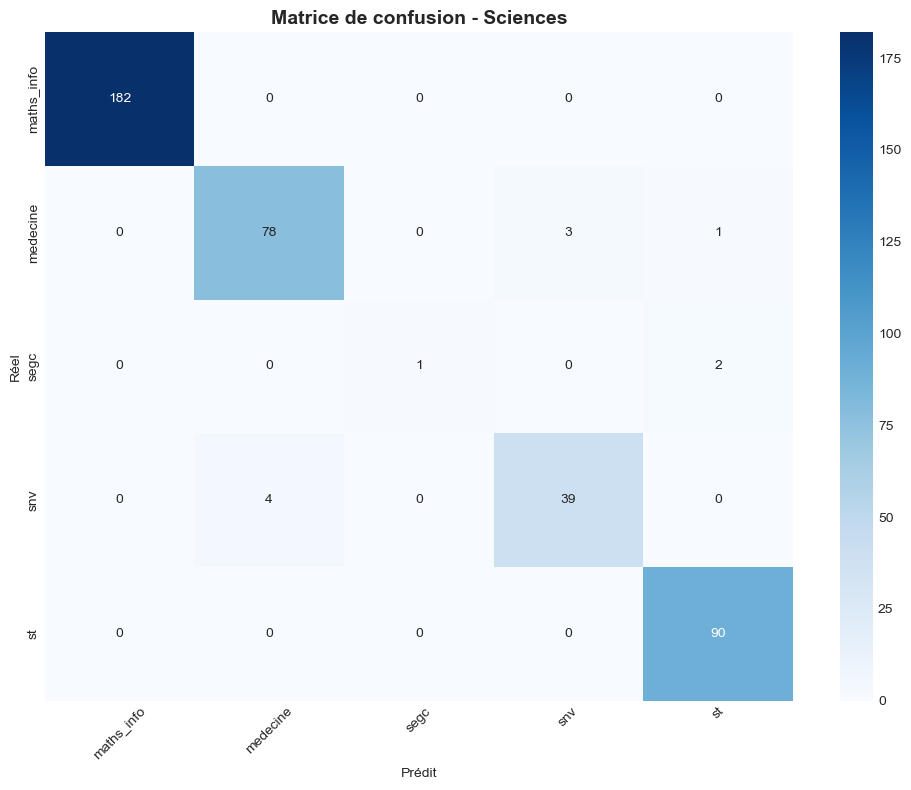


📊 Évaluation du modèle: Maths

✅ Accuracy: 0.9600 (96.0%)

📋 Classification Report:
              precision    recall  f1-score   support

  maths_info       0.99      1.00      1.00       179
    medecine       0.91      0.96      0.93        95
        segc       1.00      0.33      0.50         3
         snv       0.84      0.70      0.76        30
          st       0.98      0.99      0.98        93

    accuracy                           0.96       400
   macro avg       0.94      0.80      0.84       400
weighted avg       0.96      0.96      0.96       400



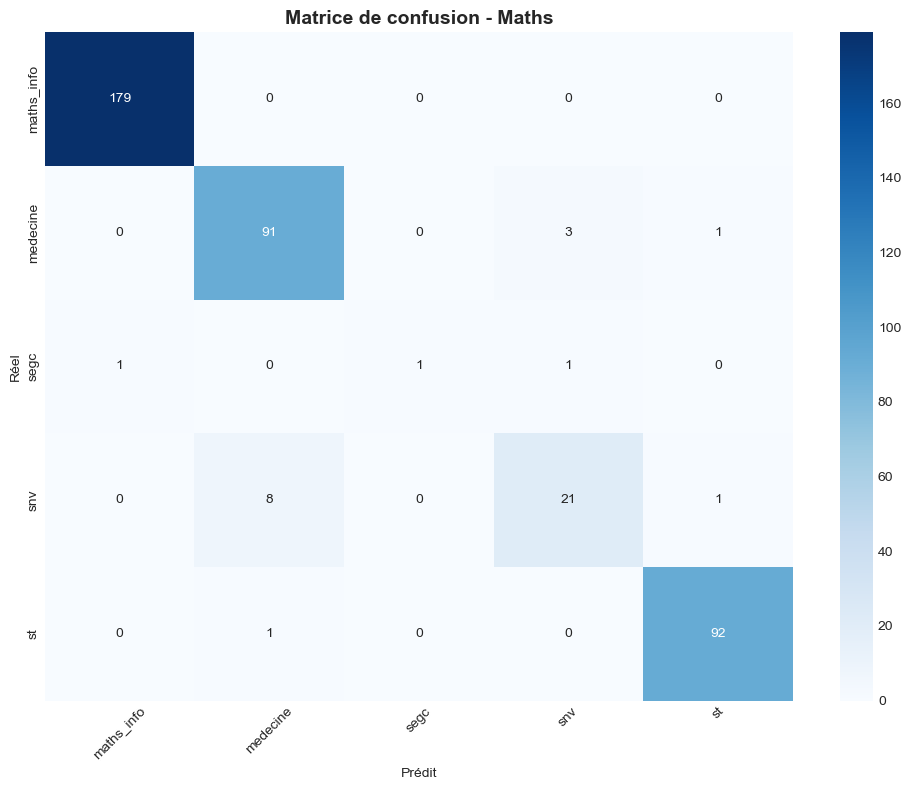


📊 Évaluation du modèle: Technique_Mathematique

✅ Accuracy: 0.9925 (99.2%)

📋 Classification Report:
              precision    recall  f1-score   support

  maths_info       1.00      0.98      0.99       149
          st       0.99      1.00      0.99       251

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



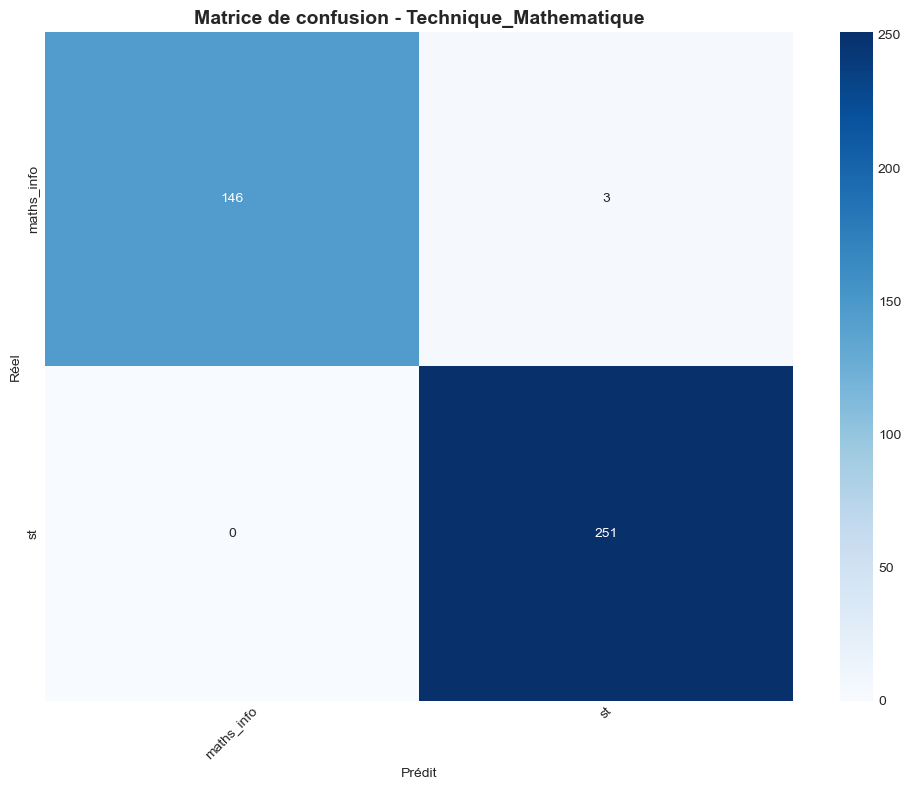


📊 Évaluation du modèle: Gestion

✅ Accuracy: 0.9825 (98.2%)

📋 Classification Report:
                   precision    recall  f1-score   support

            droit       0.95      0.99      0.97       127
sciences_humaines       1.00      0.92      0.96        63
             segc       1.00      1.00      1.00       210

         accuracy                           0.98       400
        macro avg       0.98      0.97      0.98       400
     weighted avg       0.98      0.98      0.98       400



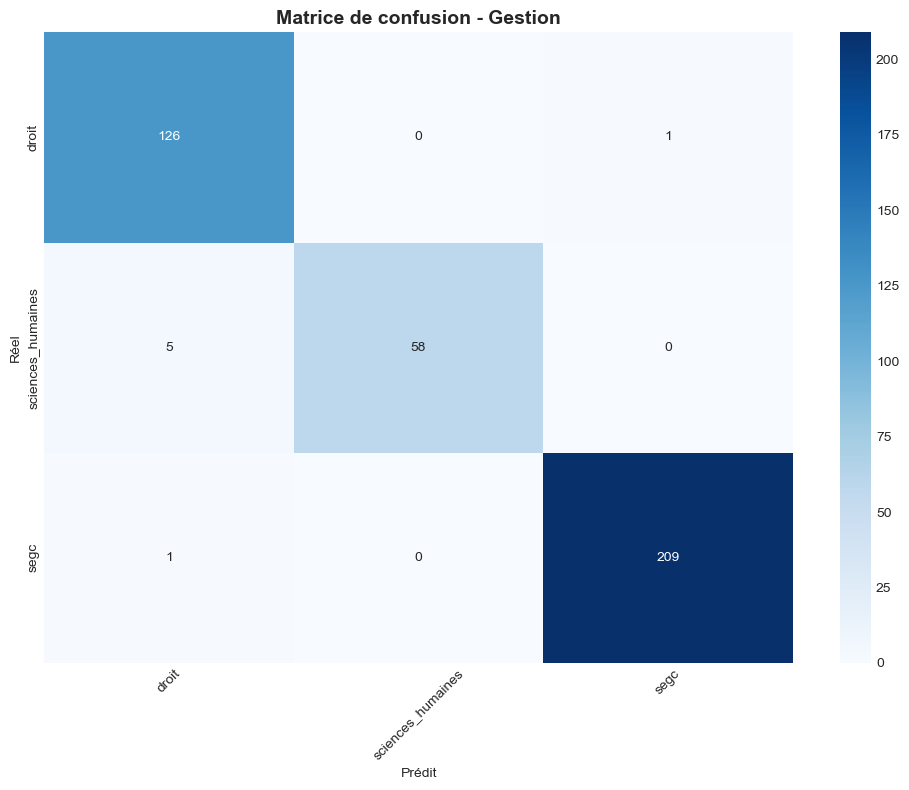


📊 Évaluation du modèle: Langues

✅ Accuracy: 0.9300 (93.0%)

📋 Classification Report:
                   precision    recall  f1-score   support

            droit       0.83      0.78      0.80        45
  lettres_langues       0.94      0.99      0.97       310
sciences_humaines       0.91      0.64      0.75        45

         accuracy                           0.93       400
        macro avg       0.89      0.81      0.84       400
     weighted avg       0.93      0.93      0.93       400



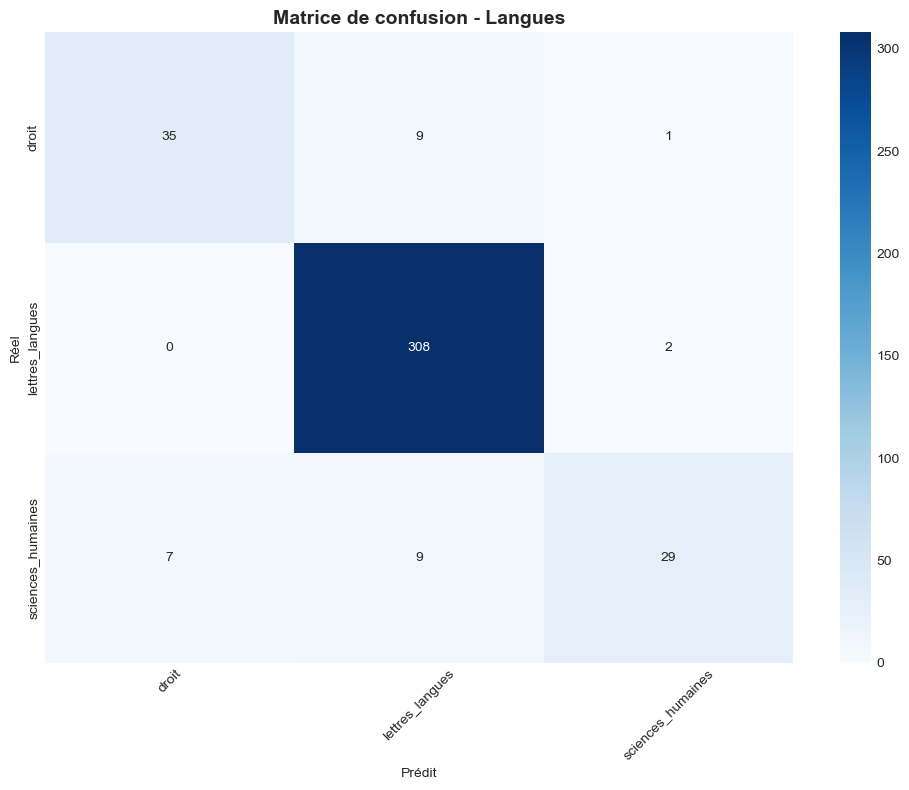


📊 Évaluation du modèle: Lettres

✅ Accuracy: 0.9825 (98.2%)

📋 Classification Report:
                   precision    recall  f1-score   support

            droit       0.97      0.99      0.98       200
       islamiques       0.99      0.97      0.98        87
sciences_humaines       1.00      0.97      0.99       113

         accuracy                           0.98       400
        macro avg       0.99      0.98      0.98       400
     weighted avg       0.98      0.98      0.98       400



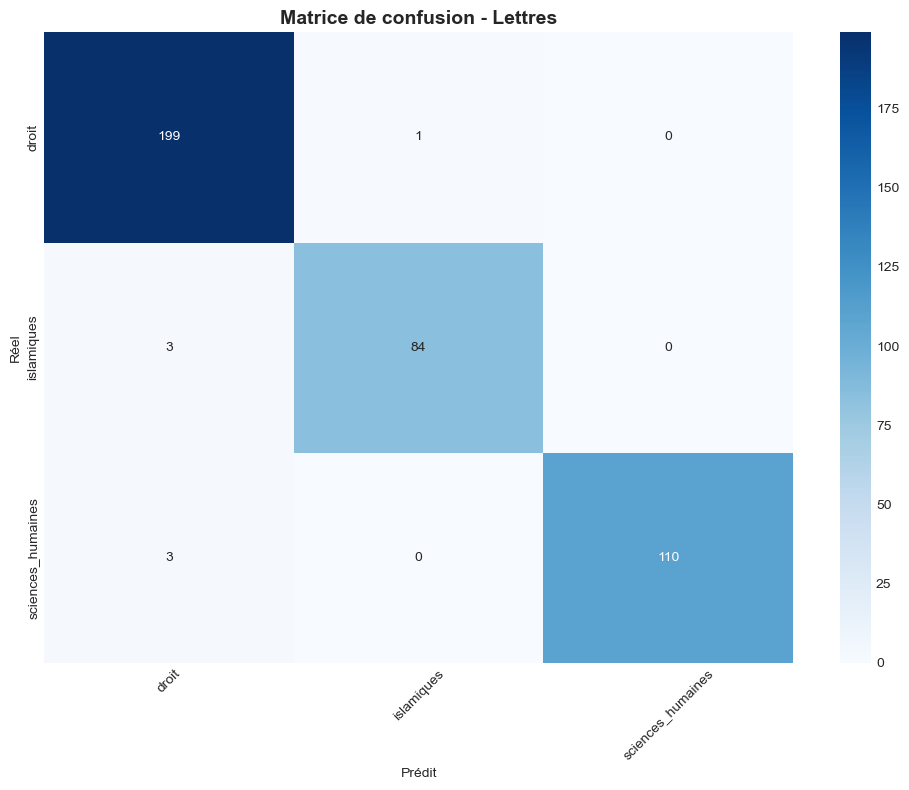


✅ Cell 9 terminée


In [13]:
# CELL 9: Évaluation détaillée des 6 modèles
# ============================================

print("=" * 60)
print("📊 9 - ÉVALUATION DÉTAILLÉE DES 6 MODÈLES")
print("=" * 60)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']

# Définir les features (identiques à Cell 8)
features = [
    'bac_avg',
    'weighted_maths_info', 'weighted_st', 'weighted_st_technique',
    'weighted_snv', 'weighted_medecine', 'weighted_segc',
    'weighted_droit', 'weighted_lettres_langues', 'weighted_sciences_humaines',
    'weighted_islamiques',
    'ratio_maths_science', 'ratio_maths_physique',
    'scientific_score', 'literary_score', 'science_minus_literary',
    'consistency_score_final', 'avg_variability'
]

for filiere in FILIERES:
    print(f"\n{'='*60}")
    print(f"📊 Évaluation du modèle: {filiere}")
    print('='*60)
    
    # Charger les données
    df = pd.read_csv(f"features_{filiere}.csv", encoding='utf-8')
    
    # Features existantes
    features_existantes = [f for f in features if f in df.columns]
    
    X = df[features_existantes]
    y = df['domaine_cible']
    
    # Split
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Récupérer le modèle
    rf = modeles[filiere]
    
    # Prédictions
    y_pred = rf.predict(X_test)
    
    # Accuracy
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test, y_pred)
    print(f"\n✅ Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    
    # Classification Report
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=rf.classes_, yticklabels=rf.classes_)
    plt.title(f'Matrice de confusion - {filiere}', fontsize=14, fontweight='bold')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("✅ Cell 9 terminée")
print("=" * 60)

In [14]:
# CELL 10: Test sur 100 étudiants avec les 6 modèles (un par filière)
# ============================================

print("=" * 60)
print("📊 10 - TEST SUR 100 ÉTUDIANTS (6 MODÈLES PAR FILIÈRE)")
print("=" * 60)

# Concaténer les 6 datasets features
FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']
dfs = []
for filiere in FILIERES:
    df_f = pd.read_csv(f"features_{filiere}.csv", encoding='utf-8')
    dfs.append(df_f)

df_all = pd.concat(dfs, ignore_index=True)

# 🔧 NORMALISATION : aligner les noms de filières avec les clés des modèles
df_all['bac_stream'] = df_all['bac_stream'].replace('Technique Mathématique', 'Technique_Mathematique')

print(f"✅ Dataset concaténé: {len(df_all)} étudiants")

# Définir les features (identiques à Cell 8)
features = [
    'bac_avg',
    'weighted_maths_info', 'weighted_st', 'weighted_st_technique',
    'weighted_snv', 'weighted_medecine', 'weighted_segc',
    'weighted_droit', 'weighted_lettres_langues', 'weighted_sciences_humaines',
    'weighted_islamiques',
    'ratio_maths_science', 'ratio_maths_physique',
    'scientific_score', 'literary_score', 'science_minus_literary',
    'consistency_score_final', 'avg_variability'
]
features_existantes = [f for f in features if f in df_all.columns]

# Prendre 100 étudiants aléatoires
n_test = 100
df_sample = df_all.sample(n=n_test, random_state=42)

bien_predits_top1 = 0
bien_predits_top3 = 0
bien_predits_top5 = 0

for idx, row in df_sample.iterrows():
    filiere = row['bac_stream']
    domaine_reel = row['domaine_cible']
    
    # Récupérer le modèle de la filière
    modele = modeles[filiere]
    
    # Préparer les features
    X_etudiant = row[features_existantes].values.reshape(1, -1)
    
    # Prédiction
    probas = modele.predict_proba(X_etudiant)[0]
    classes = modele.classes_
    
    # Classement
    ranking = sorted(zip(classes, probas), key=lambda x: x[1], reverse=True)
    top1 = ranking[0][0]
    top3 = [d for d, _ in ranking[:3]]
    top5 = [d for d, _ in ranking[:5]]
    
    if domaine_reel == top1:
        bien_predits_top1 += 1
    if domaine_reel in top3:
        bien_predits_top3 += 1
    if domaine_reel in top5:
        bien_predits_top5 += 1

print("\n" + "=" * 60)
print("📊 RÉSULTATS GLOBAUX")
print("=" * 60)

print(f"\n🎯 Top-1 accuracy: {bien_predits_top1}/{n_test} ({bien_predits_top1/n_test*100:.1f}%)")
print(f"🎯 Top-3 accuracy: {bien_predits_top3}/{n_test} ({bien_predits_top3/n_test*100:.1f}%)")
print(f"🎯 Top-5 accuracy: {bien_predits_top5}/{n_test} ({bien_predits_top5/n_test*100:.1f}%)")

print("\n✅ Cell 10 done")

📊 10 - TEST SUR 100 ÉTUDIANTS (6 MODÈLES PAR FILIÈRE)
✅ Dataset concaténé: 12000 étudiants

📊 RÉSULTATS GLOBAUX

🎯 Top-1 accuracy: 98/100 (98.0%)
🎯 Top-3 accuracy: 100/100 (100.0%)
🎯 Top-5 accuracy: 100/100 (100.0%)

✅ Cell 10 done


In [17]:
# CELL DIAGNOSTIC: Tester 10 profils ALEATOIRES par filière (BAC COHÉRENT)
# ============================================

print("=" * 60)
print("🔍 DIAGNOSTIC - PRÉDICTIONS BRUTES (PROFILS ALÉATOIRES AVEC BAC COHÉRENT)")
print("=" * 60)

import random

# ============================================
# 1. Coefficients par filière (officiels)
# ============================================

COEFFS_PAR_FILIERE = {
    'Sciences': {
        'science_grade': 6, 'physique_grade': 5, 'maths_grade': 5,
        'arabe_grade': 3, 'islamia_grade': 2, 'his_geo_grade': 2,
        'francais_grade': 2, 'anglais_grade': 2, 'philo_grade': 2,
        'tamazight_grade': 2
    },
    'Maths': {
        'maths_grade': 7, 'physique_grade': 6, 'science_grade': 2,
        'arabe_grade': 3, 'islamia_grade': 2, 'his_geo_grade': 2,
        'francais_grade': 2, 'anglais_grade': 2, 'philo_grade': 2,
        'tamazight_grade': 2
    },
    'Technique_Mathematique': {
        'techno_grade': 6, 'maths_grade': 6, 'physique_grade': 5,
        'arabe_grade': 3, 'islamia_grade': 2, 'his_geo_grade': 2,
        'francais_grade': 2, 'anglais_grade': 2, 'philo_grade': 2,
        'tamazight_grade': 2
    },
    'Gestion': {
        'gestion_grade': 6, 'economie_grade': 5, 'maths_grade': 5,
        'arabe_grade': 3, 'his_geo_grade': 4, 'islamia_grade': 2,
        'francais_grade': 2, 'anglais_grade': 2, 'philo_grade': 2,
        'loi_grade': 2, 'tamazight_grade': 2
    },
    'Langues': {
        'langue_etranger_grade': 5, 'arabe_grade': 5,
        'anglais_grade': 4, 'francais_grade': 4,
        'maths_grade': 2, 'his_geo_grade': 2, 'philo_grade': 2,
        'islamia_grade': 2, 'tamazight_grade': 2
    },
    'Lettres': {
        'philo_grade': 6, 'arabe_grade': 6, 'his_geo_grade': 4,
        'francais_grade': 3, 'anglais_grade': 3,
        'islamia_grade': 2, 'maths_grade': 2, 'tamazight_grade': 2
    }
}

# ============================================
# 2. Fonction pour calculer la moyenne BAC réelle
# ============================================

def calculer_moyenne_bac(notes, filiere):
    coeffs = COEFFS_PAR_FILIERE[filiere]
    total_points = 0
    total_coeffs = 0
    for matiere, coeff in coeffs.items():
        note = notes.get(matiere, 0)
        if note > 0:
            total_points += note * coeff
            total_coeffs += coeff
    return round(total_points / total_coeffs, 1) if total_coeffs > 0 else 10.0

# ============================================
# 3. Fonction pour afficher les notes pertinentes
# ============================================

def afficher_notes_pertinentes(profil, filiere):
    if filiere == 'Sciences':
        return f"Maths={profil.get('maths_grade',0)}, Phys={profil.get('physique_grade',0)}, Sci={profil.get('science_grade',0)}"
    elif filiere == 'Maths':
        return f"Maths={profil.get('maths_grade',0)}, Phys={profil.get('physique_grade',0)}, Sci={profil.get('science_grade',0)}"
    elif filiere == 'Technique_Mathematique':
        return f"Maths={profil.get('maths_grade',0)}, Phys={profil.get('physique_grade',0)}, Techno={profil.get('techno_grade',0)}"
    elif filiere == 'Gestion':
        return f"Maths={profil.get('maths_grade',0)}, Gestion={profil.get('gestion_grade',0)}, Éco={profil.get('economie_grade',0)}"
    elif filiere == 'Langues':
        return f"Langue étr={profil.get('langue_etranger_grade',0)}, Anglais={profil.get('anglais_grade',0)}, Français={profil.get('francais_grade',0)}"
    else:
        return f"Arabe={profil.get('arabe_grade',0)}, Philo={profil.get('philo_grade',0)}, His/Géo={profil.get('his_geo_grade',0)}"

# ============================================
# 4. Génération d'un profil aléatoire (BAC COHÉRENT)
# ============================================

def generer_profil_aleatoire(filiere):
    """Génère un profil avec moyenne BAC cohérente"""
    
    # Notes aléatoires (entre 8 et 20)
    if filiere == 'Sciences':
        notes = {
            'maths_grade': round(random.uniform(8, 20), 1),
            'physique_grade': round(random.uniform(8, 20), 1),
            'science_grade': round(random.uniform(8, 20), 1),
            'arabe_grade': round(random.uniform(8, 20), 1),
            'francais_grade': round(random.uniform(8, 20), 1),
            'anglais_grade': round(random.uniform(8, 20), 1),
            'his_geo_grade': round(random.uniform(8, 20), 1),
            'philo_grade': round(random.uniform(8, 20), 1),
            'islamia_grade': round(random.uniform(8, 20), 1),
            'tamazight_grade': round(random.uniform(8, 20), 1)
        }
    elif filiere == 'Maths':
        notes = {
            'maths_grade': round(random.uniform(8, 20), 1),
            'physique_grade': round(random.uniform(8, 20), 1),
            'science_grade': round(random.uniform(8, 20), 1),
            'arabe_grade': round(random.uniform(8, 20), 1),
            'francais_grade': round(random.uniform(8, 20), 1),
            'anglais_grade': round(random.uniform(8, 20), 1),
            'his_geo_grade': round(random.uniform(8, 20), 1),
            'philo_grade': round(random.uniform(8, 20), 1),
            'islamia_grade': round(random.uniform(8, 20), 1),
            'tamazight_grade': round(random.uniform(8, 20), 1)
        }
    elif filiere == 'Technique_Mathematique':
        notes = {
            'maths_grade': round(random.uniform(8, 20), 1),
            'physique_grade': round(random.uniform(8, 20), 1),
            'techno_grade': round(random.uniform(8, 20), 1),
            'arabe_grade': round(random.uniform(8, 20), 1),
            'francais_grade': round(random.uniform(8, 20), 1),
            'anglais_grade': round(random.uniform(8, 20), 1),
            'his_geo_grade': round(random.uniform(8, 20), 1),
            'philo_grade': round(random.uniform(8, 20), 1),
            'islamia_grade': round(random.uniform(8, 20), 1),
            'tamazight_grade': round(random.uniform(8, 20), 1)
        }
    elif filiere == 'Gestion':
        notes = {
            'maths_grade': round(random.uniform(8, 20), 1),
            'gestion_grade': round(random.uniform(8, 20), 1),
            'economie_grade': round(random.uniform(8, 20), 1),
            'loi_grade': round(random.uniform(8, 20), 1),
            'arabe_grade': round(random.uniform(8, 20), 1),
            'francais_grade': round(random.uniform(8, 20), 1),
            'anglais_grade': round(random.uniform(8, 20), 1),
            'his_geo_grade': round(random.uniform(8, 20), 1),
            'philo_grade': round(random.uniform(8, 20), 1),
            'islamia_grade': round(random.uniform(8, 20), 1),
            'tamazight_grade': round(random.uniform(8, 20), 1)
        }
    elif filiere == 'Langues':
        notes = {
            'langue_etranger_grade': round(random.uniform(8, 20), 1),
            'anglais_grade': round(random.uniform(8, 20), 1),
            'francais_grade': round(random.uniform(8, 20), 1),
            'maths_grade': round(random.uniform(8, 12), 1),
            'arabe_grade': round(random.uniform(8, 20), 1),
            'his_geo_grade': round(random.uniform(8, 20), 1),
            'philo_grade': round(random.uniform(8, 20), 1),
            'islamia_grade': round(random.uniform(8, 20), 1),
            'tamazight_grade': round(random.uniform(8, 20), 1)
        }
    else:  # Lettres
        notes = {
            'arabe_grade': round(random.uniform(8, 20), 1),
            'philo_grade': round(random.uniform(8, 20), 1),
            'his_geo_grade': round(random.uniform(8, 20), 1),
            'maths_grade': round(random.uniform(8, 12), 1),
            'francais_grade': round(random.uniform(8, 20), 1),
            'anglais_grade': round(random.uniform(8, 20), 1),
            'islamia_grade': round(random.uniform(8, 20), 1),
            'tamazight_grade': round(random.uniform(8, 20), 1)
        }
    
    # Calculer la moyenne BAC cohérente
    bac_avg = calculer_moyenne_bac(notes, filiere)
    
    profil = {
        'bac_stream': filiere,
        'bac_avg': bac_avg,
        **notes
    }
    
    # Ajouter les champs par défaut
    profil['techno_grade'] = profil.get('techno_grade', 0)
    profil['gestion_grade'] = profil.get('gestion_grade', 0)
    profil['economie_grade'] = profil.get('economie_grade', 0)
    profil['loi_grade'] = profil.get('loi_grade', 0)
    profil['langue_etranger_grade'] = profil.get('langue_etranger_grade', 0)
    profil['consistency_score_final'] = 3.5
    profil['avg_variability'] = 1.0
    profil['career_orientation'] = 'Mixte'
    profil['wilaya'] = 16
    profil['stress_level'] = 3
    profil['competitiveness'] = 3
    profil['consistency_score'] = 3
    
    return profil

# ============================================
# 5. Tester 10 profils aléatoires par filière
# ============================================

FILIERES = ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']

for filiere in FILIERES:
    print(f"\n{'='*70}")
    print(f"📊 FILIÈRE: {filiere} (10 profils aléatoires - BAC COHÉRENT)")
    print('='*70)
    
    modele = modeles[filiere]
    
    for i in range(10):
        profil = generer_profil_aleatoire(filiere)
        
        # Prédiction
        X_etudiant = calculer_weighted_et_features(profil, modele)
        probas = modele.predict_proba(X_etudiant)[0]
        classes = modele.classes_
        
        ranking = sorted(zip(classes, probas), key=lambda x: x[1], reverse=True)
        
        # Afficher
        notes_aff = afficher_notes_pertinentes(profil, filiere)
        print(f"\n   [{i+1}] Bac={profil['bac_avg']}, {notes_aff}")
        
        for rank, (domaine, proba) in enumerate(ranking[:5], 1):
            domaine_nom = ID_TO_NOM.get(domaine, domaine)
            print(f"       Top {rank}: {domaine_nom} ({proba:.1%})")

print("\n" + "=" * 60)
print("✅ Diagnostic terminé - BAC toujours cohérent avec les notes")

🔍 DIAGNOSTIC - PRÉDICTIONS BRUTES (PROFILS ALÉATOIRES AVEC BAC COHÉRENT)

📊 FILIÈRE: Sciences (10 profils aléatoires - BAC COHÉRENT)

   [1] Bac=12.6, Maths=14.1, Phys=8.3, Sci=10.4
       Top 1: الرياضيات والإعلام الآلي (94.6%)
       Top 2: العلوم والتكنولوجيا (ST) (3.0%)
       Top 3: العلوم الاقتصادية، علوم التسيير والعلوم التجارية (SEGC) (1.1%)
       Top 4: علوم الطبيعة والحياة (SNV) (0.8%)
       Top 5: الطب والطب المساعد (العلوم الطبية) (0.5%)

   [2] Bac=13.7, Maths=16.4, Phys=12.1, Sci=9.9
       Top 1: الرياضيات والإعلام الآلي (96.8%)
       Top 2: العلوم والتكنولوجيا (ST) (2.1%)
       Top 3: العلوم الاقتصادية، علوم التسيير والعلوم التجارية (SEGC) (0.4%)
       Top 4: الطب والطب المساعد (العلوم الطبية) (0.4%)
       Top 5: علوم الطبيعة والحياة (SNV) (0.3%)

   [3] Bac=16.4, Maths=16.8, Phys=14.4, Sci=19.7
       Top 1: الطب والطب المساعد (العلوم الطبية) (69.4%)
       Top 2: علوم الطبيعة والحياة (SNV) (17.9%)
       Top 3: الرياضيات والإعلام الآلي (9.9%)
       Top 4: العلو

In [16]:
# CELL 11: Rule-based complet - Définitions (VERSION FINALE)
# ============================================

print("=" * 60)
print("📊 11 - DÉFINITIONS (FONCTIONS + RÈGLES) - VERSION FINALE")
print("=" * 60)

import json
import pandas as pd
import numpy as np

# ============================================
# 1. Chargement du JSON des formations
# ============================================

with open('data.json', 'r', encoding='utf-8') as f:
    DOMAINES_DATA = json.load(f)

# Mapping des noms de domaines (arabe -> id)
NOMS_DOMAINES = {
    'الرياضيات والإعلام الآلي': 'maths_info',
    'العلوم والتكنولوجيا (ST)': 'st',
    'علوم الطبيعة والحياة (SNV)': 'snv',
    'الطب والطب المساعد (العلوم الطبية)': 'medecine',
    'العلوم الاقتصادية، علوم التسيير والعلوم التجارية (SEGC)': 'segc',
    'الآداب واللغات': 'lettres_langues',
    'الحقوق والعلوم السياسية': 'droit',
    'العلوم الإنسانية والاجتماعية': 'sciences_humaines',
    'العلوم الإسلامية': 'islamiques',
    'الفنون والثقافة': 'arts',
    'STAPS (علوم وتقنيات النشاطات البدنية والرياضية)': 'staps'
}

# Mapping inverse (id -> nom arabe)
ID_TO_NOM = {v: k for k, v in NOMS_DOMAINES.items()}

# Mapping des noms de filières (français -> arabe)
FILIERE_TO_ARABE = {
    'Sciences': 'علوم تجريبية',
    'Maths': 'رياضيات',
    'Technique_Mathematique': 'تقني رياضي',
    'Gestion': 'تسيير واقتصاد',
    'Langues': 'لغات أجنبية',
    'Lettres': 'آداب وفلسفة'
}

# ============================================
# 2. Fonctions utilitaires
# ============================================

def get_wilaya_name(code):
    wilayas = {
        1: 'أدرار', 2: 'الشلف', 3: 'الأغواط', 4: 'أم البواقي', 5: 'باتنة',
        6: 'بجاية', 7: 'بسكرة', 8: 'بشار', 9: 'البليدة', 10: 'البويرة',
        11: 'تمنراست', 12: 'تبسة', 13: 'تلمسان', 14: 'تيارت', 15: 'تيزي وزو',
        16: 'الجزائر', 17: 'الجلفة', 18: 'جيجل', 19: 'سطيف', 20: 'سعيدة',
        21: 'سكيكدة', 22: 'سيدي بلعباس', 23: 'عنابة', 24: 'قالمة', 25: 'قسنطينة',
        26: 'المدية', 27: 'مستغانم', 28: 'المسيلة', 29: 'معسكر', 30: 'ورقلة',
        31: 'وهران', 32: 'البيض', 33: 'إليزي', 34: 'برج بوعريريج', 35: 'بومرداس',
        36: 'الطارف', 37: 'تندوف', 38: 'تيسمسيلت', 39: 'الوادي', 40: 'خنشلة',
        41: 'سوق أهراس', 42: 'تيبازة', 43: 'ميلة', 44: 'عين الدفلى', 45: 'النعامة',
        46: 'عين تيموشنت', 47: 'غرداية', 48: 'غليزان', 49: 'تيميمون', 50: 'برج باجي مختار',
        51: 'أولاد جلال', 52: 'بني عباس', 53: 'عين صالح', 54: 'عين قزام', 55: 'تقرت',
        56: 'جانت', 57: 'المغير', 58: 'المنيعة'
    }
    return wilayas.get(code, f"ولاية {code}")

def calculer_moyenne_ponderee(etudiant, domaine_nom):
    if domaine_nom == 'الرياضيات والإعلام الآلي':
        return (etudiant['bac_avg'] * 2 + etudiant.get('maths_grade', 0)) / 3
    elif domaine_nom == 'العلوم والتكنولوجيا (ST)':
        return (etudiant['bac_avg'] * 2 + etudiant.get('physique_grade', 0)) / 3
    elif domaine_nom == 'علوم الطبيعة والحياة (SNV)':
        return (etudiant['bac_avg'] * 2 + etudiant.get('science_grade', 0)) / 3
    elif domaine_nom == 'الطب والطب المساعد (العلوم الطبية)':
        return (etudiant['bac_avg'] * 2 + etudiant.get('science_grade', 0) * 1.2 + 
                etudiant.get('maths_grade', 0) * 0.4 + etudiant.get('physique_grade', 0) * 0.4) / 4
    elif domaine_nom == 'العلوم الاقتصادية، علوم التسيير والعلوم التجارية (SEGC)':
        return (etudiant['bac_avg'] * 2 + etudiant.get('gestion_grade', 0) + etudiant.get('economie_grade', 0)) / 4
    elif domaine_nom == 'الحقوق والعلوم السياسية':
        return (etudiant['bac_avg'] * 2 + etudiant.get('arabe_grade', 0) + etudiant.get('his_geo_grade', 0)) / 4
    elif domaine_nom == 'الآداب واللغات':
        return (etudiant['bac_avg'] * 2 + etudiant.get('langue_etranger_grade', 0) + 
                etudiant.get('anglais_grade', 0) + etudiant.get('francais_grade', 0)) / 5
    elif domaine_nom == 'العلوم الإنسانية والاجتماعية':
        return (etudiant['bac_avg'] * 2 + etudiant.get('philo_grade', 0) + etudiant.get('his_geo_grade', 0)) / 4
    elif domaine_nom == 'العلوم الإسلامية':
        return (etudiant['bac_avg'] * 2 + etudiant.get('islamia_grade', 0) + etudiant.get('arabe_grade', 0)) / 4
    else:
        return etudiant['bac_avg']

def calculer_weighted_et_features(etudiant, modele):
    bac = etudiant['bac_avg']
    
    all_features = {
        'bac_avg': bac,
        'maths_grade': etudiant.get('maths_grade', 0),
        'physique_grade': etudiant.get('physique_grade', 0),
        'science_grade': etudiant.get('science_grade', 0),
        'arabe_grade': etudiant.get('arabe_grade', 0),
        'philo_grade': etudiant.get('philo_grade', 0),
        'his_geo_grade': etudiant.get('his_geo_grade', 0),
        'francais_grade': etudiant.get('francais_grade', 0),
        'anglais_grade': etudiant.get('anglais_grade', 0),
        'weighted_maths_info': (bac * 2 + etudiant.get('maths_grade', 0)) / 3,
        'weighted_st': (bac * 2 + etudiant.get('physique_grade', 0)) / 3,
        'weighted_st_technique': (bac * 2 + etudiant.get('physique_grade', 0) + etudiant.get('techno_grade', 0)) / 4,
        'weighted_snv': (bac * 2 + etudiant.get('science_grade', 0)) / 3,
        'weighted_medecine': (bac * 2 + etudiant.get('science_grade', 0) * 1.2 + 
                              etudiant.get('maths_grade', 0) * 0.4 + etudiant.get('physique_grade', 0) * 0.4) / 4,
        'weighted_segc': (bac * 2 + etudiant.get('gestion_grade', 0) + etudiant.get('economie_grade', 0)) / 4,
        'weighted_droit': (bac * 2 + etudiant.get('arabe_grade', 0) + etudiant.get('his_geo_grade', 0)) / 4,
        'weighted_lettres_langues': (bac * 2 + etudiant.get('langue_etranger_grade', 0) + 
                                      etudiant.get('anglais_grade', 0) + etudiant.get('francais_grade', 0)) / 5,
        'weighted_sciences_humaines': (bac * 2 + etudiant.get('philo_grade', 0) + etudiant.get('his_geo_grade', 0)) / 4,
        'weighted_islamiques': (bac * 2 + etudiant.get('islamia_grade', 0) + etudiant.get('arabe_grade', 0)) / 4,
        'ratio_maths_science': etudiant.get('maths_grade', 0) / (etudiant.get('science_grade', 0) + 0.01),
        'ratio_maths_physique': etudiant.get('maths_grade', 0) / (etudiant.get('physique_grade', 0) + 0.01),
        'scientific_score': (etudiant.get('maths_grade', 0) + etudiant.get('physique_grade', 0) + etudiant.get('science_grade', 0)) / 3,
        'literary_score': (etudiant.get('arabe_grade', 0) + etudiant.get('philo_grade', 0) + etudiant.get('his_geo_grade', 0)) / 3,
        'science_minus_literary': 0,
        'consistency_score_final': etudiant.get('consistency_score_final', 3),
        'avg_variability': etudiant.get('avg_variability', 1.0)
    }
    all_features['science_minus_literary'] = all_features['scientific_score'] - all_features['literary_score']
    
    feature_order = modele.feature_names_in_
    return np.array([[all_features.get(f, 0) for f in feature_order]])

# ============================================
# 3. Prédiction des domaines
# ============================================

def predire_domaines(etudiant, modeles_par_filiere):
    filiere = etudiant['bac_stream']
    
    if filiere == 'Langues':
        return [('lettres_langues', 1.0)]
    
    modele = modeles_par_filiere[filiere]
    X_etudiant = calculer_weighted_et_features(etudiant, modele)
    probas = modele.predict_proba(X_etudiant)[0]
    classes = modele.classes_
    
    if etudiant.get('bac_avg', 0) > 14 and filiere in ['Sciences', 'Maths', 'Technique_Mathematique']:
        for i in range(len(classes)):
            if classes[i] == 'medecine':
                probas[i] *= 1.5
            elif classes[i] == 'maths_info':
                probas[i] *= 2.0
            elif classes[i] == 'st':
                probas[i] *= 1.3
        probas = probas / probas.sum()
    
    ranking = sorted(zip(classes, probas), key=lambda x: x[1], reverse=True)
    return ranking[:5]

# ============================================
# 4. Récupération des formations (sans tri interne)
# ============================================

def get_formations_par_domaine(etudiant, domaine_id, proba_domaine):
    domaine_nom = ID_TO_NOM.get(domaine_id)
    if not domaine_nom:
        return []
    
    domaine_json = None
    for d in DOMAINES_DATA:
        if d.get('domaine') == domaine_nom:
            domaine_json = d
            break
    
    if not domaine_json:
        return []
    
    filiere_arabe = FILIERE_TO_ARABE.get(etudiant['bac_stream'], etudiant['bac_stream'])
    formations = []
    
    for type_form, formations_json in domaine_json.get('formations', {}).items():
        for formation in formations_json:
            streams_acceptes = formation.get('streams_acceptes', {})
            priorite_info = None
            for stream, info in streams_acceptes.items():
                if stream == filiere_arabe:
                    priorite_info = info
                    break
            
            if not priorite_info:
                continue
            
            weighted_avg = calculer_moyenne_ponderee(etudiant, domaine_nom)
            seuil_min = priorite_info.get('min_moyenne_ponderee_2025', 0)
            
            if weighted_avg < seuil_min:
                continue
            
            if type_form == 'ens' and etudiant.get('career_orientation') != 'Enseignement':
                continue
            
            if type_form == 'lmd':
                localisation = formation.get('localisation', {})
                wilayas_acceptees = localisation.get('wilayas', [])
                if wilayas_acceptees != "جميع الولايات":
                    if get_wilaya_name(etudiant['wilaya']) not in wilayas_acceptees:
                        continue
            
            matiere_cle = 'maths_grade'
            if domaine_id in ['medecine', 'snv']:
                matiere_cle = 'science_grade'
            elif domaine_id == 'st':
                matiere_cle = 'physique_grade'
            elif domaine_id == 'lettres_langues':
                matiere_cle = 'langue_etranger_grade'
            
            formations.append({
                'domaine': domaine_nom,
                'domaine_id': domaine_id,
                'domaine_proba': proba_domaine,
                'nom': formation['nom'],
                'type': type_form,
                'duree': formation.get('duree', ''),
                'priorite': priorite_info['priorite'],
                'seuil': seuil_min,
                'weighted_avg': round(weighted_avg, 1),
                'matiere_cle': matiere_cle,
                'debouches': formation.get('debouches', [])[:3]
            })
    
    return formations

# ============================================
# 5. Explication textuelle
# ============================================

def generer_explication(etudiant, formation):
    explication = f"✅ Vous avez {etudiant['bac_avg']} de moyenne BAC, "
    
    if formation['type'] in ['ecoles_superieures', 'cycle_long', 'ingeniorat']:
        explication += f"un bon consistency score ({etudiant.get('consistency_score_final', 3)}/5). "
        note_cle = etudiant.get(formation['matiere_cle'], 0)
        explication += f"Votre note en {formation['matiere_cle'].replace('_grade', '')} ({note_cle}) est excellente. "
        if etudiant.get('career_orientation') == 'Recherche':
            explication += "Votre profil recherche correspond parfaitement à ce type de formation. "
    elif formation['type'] == 'ens':
        explication += "et vous êtes orienté vers l'enseignement, ce qui est idéal pour une ENS. "
    else:
        explication += "et votre profil correspond bien à une formation LMD accessible depuis votre wilaya. "
    
    explication += f"Vous dépassez le seuil d'admission de {formation['seuil']} avec {formation['weighted_avg']}."
    
    return explication

# ============================================
# 6. Fonction principale (TRI GLOBAL PAR SEUIL)
# ============================================

def recommander_formations(etudiant, modeles_par_filiere, top_n_domaines=3, page=0, par_page=10):
    top_domaines = predire_domaines(etudiant, modeles_par_filiere)
    
    toutes_formations = []
    for domaine_id, proba in top_domaines[:top_n_domaines]:
        formations = get_formations_par_domaine(etudiant, domaine_id, proba)
        toutes_formations.extend(formations)
    
    for f in toutes_formations:
        f['explication'] = generer_explication(etudiant, f)
    
    # 🔥 TRI GLOBAL PAR SEUIL DÉCROISSANT (tous domaines confondus)
    toutes_formations.sort(key=lambda x: x['seuil'], reverse=True)
    
    start = page * par_page
    end = start + par_page
    return toutes_formations[start:end], top_domaines, len(toutes_formations)

print("\n✅ Cell 11 terminée (fonctions chargées)")

📊 11 - DÉFINITIONS (FONCTIONS + RÈGLES) - VERSION FINALE

✅ Cell 11 terminée (fonctions chargées)


In [18]:
# CELL 12: Tests sur 10 profils variés (TOP 10 formations) - CORRIGÉE
# ============================================

print("=" * 60)
print("📊 12 - TESTS SUR 10 PROFILS VARIÉS (TOP 10 FORMATIONS)")
print("=" * 60)

# 10 profils très différents
profils_test = [
    {
        'nom': '1. Sciences - Médecine (Alger, bac élevé)',
        'bac_stream': 'Sciences',
        'bac_avg': 17.5,
        'maths_grade': 18.0,
        'physique_grade': 17.0,
        'science_grade': 19.0,
        'techno_grade': 14.0,
        'arabe_grade': 14.0,
        'francais_grade': 13.0,
        'anglais_grade': 15.0,
        'his_geo_grade': 13.0,
        'philo_grade': 12.0,
        'islamia_grade': 14.0,
        'wilaya': 16,
        'career_orientation': 'Recherche',
        'consistency_score_final': 4.5,
        'avg_variability': 0.5,
        'stress_level': 2,
        'competitiveness': 5,
        'consistency_score': 5
    },
    {
        'nom': '2. Maths - Informatique (Oran, très bon)',
        'bac_stream': 'Maths',
        'bac_avg': 18.0,
        'maths_grade': 19.5,
        'physique_grade': 17.0,
        'science_grade': 16.0,
        'arabe_grade': 12.0,
        'francais_grade': 11.0,
        'anglais_grade': 14.0,
        'his_geo_grade': 12.0,
        'philo_grade': 11.0,
        'islamia_grade': 13.0,
        'wilaya': 31,
        'career_orientation': 'Recherche',
        'consistency_score_final': 4.8,
        'avg_variability': 0.3,
        'stress_level': 3,
        'competitiveness': 5,
        'consistency_score': 5
    },
    {
        'nom': '3. Gestion - SEGC (Constantine, moyen)',
        'bac_stream': 'Gestion',
        'bac_avg': 13.5,
        'maths_grade': 11.0,
        'gestion_grade': 14.0,
        'economie_grade': 13.0,
        'loi_grade': 12.0,
        'arabe_grade': 13.0,
        'francais_grade': 12.0,
        'anglais_grade': 11.0,
        'his_geo_grade': 12.0,
        'philo_grade': 11.0,
        'islamia_grade': 12.0,
        'wilaya': 25,
        'career_orientation': 'Industrie',
        'consistency_score_final': 3.2,
        'avg_variability': 1.2,
        'stress_level': 3,
        'competitiveness': 3,
        'consistency_score': 3
    },
    {
        'nom': '4. Technique - ST (Béjaïa, bon)',
        'bac_stream': 'Technique_Mathematique',
        'bac_avg': 15.5,
        'maths_grade': 14.0,
        'physique_grade': 16.0,
        'techno_grade': 17.0,
        'science_grade': 12.0,
        'arabe_grade': 12.0,
        'francais_grade': 11.0,
        'anglais_grade': 13.0,
        'his_geo_grade': 11.0,
        'philo_grade': 10.0,
        'islamia_grade': 12.0,
        'wilaya': 6,
        'career_orientation': 'Industrie',
        'consistency_score_final': 4.0,
        'avg_variability': 0.8,
        'stress_level': 3,
        'competitiveness': 4,
        'consistency_score': 4
    },
    {
        'nom': '5. Lettres - Droit (Tizi Ouzou, moyen)',
        'bac_stream': 'Lettres',
        'bac_avg': 12.0,
        'maths_grade': 9.0,
        'arabe_grade': 14.0,
        'philo_grade': 13.0,
        'his_geo_grade': 14.0,
        'francais_grade': 11.0,
        'anglais_grade': 10.0,
        'islamia_grade': 12.0,
        'wilaya': 15,
        'career_orientation': 'Enseignement',
        'consistency_score_final': 3.0,
        'avg_variability': 1.5,
        'stress_level': 2,
        'competitiveness': 3,
        'consistency_score': 3
    },
    {
        'nom': '6. Langues - Langues (Alger, bon)',
        'bac_stream': 'Langues',
        'bac_avg': 13.0,
        'langue_etranger_grade': 16.0,
        'anglais_grade': 15.0,
        'francais_grade': 14.0,
        'maths_grade': 10.0,
        'arabe_grade': 12.0,
        'his_geo_grade': 11.0,
        'philo_grade': 11.0,
        'islamia_grade': 12.0,
        'wilaya': 16,
        'career_orientation': 'Mixte',
        'consistency_score_final': 3.5,
        'avg_variability': 1.0,
        'stress_level': 3,
        'competitiveness': 3,
        'consistency_score': 3
    },
    {
        'nom': '7. Sciences - ST (Alger, physique forte)',
        'bac_stream': 'Sciences',
        'bac_avg': 14.5,
        'maths_grade': 13.0,
        'physique_grade': 18.0,
        'science_grade': 12.0,
        'techno_grade': 14.0,
        'arabe_grade': 13.0,
        'francais_grade': 12.0,
        'anglais_grade': 13.0,
        'his_geo_grade': 12.0,
        'philo_grade': 11.0,
        'islamia_grade': 13.0,
        'wilaya': 16,
        'career_orientation': 'Industrie',
        'consistency_score_final': 3.8,
        'avg_variability': 1.0,
        'stress_level': 3,
        'competitiveness': 4,
        'consistency_score': 4
    },
    {
        'nom': '8. Maths - ST (Oran, physique forte)',
        'bac_stream': 'Maths',
        'bac_avg': 14.0,
        'maths_grade': 12.0,
        'physique_grade': 17.0,
        'science_grade': 11.0,
        'arabe_grade': 12.0,
        'francais_grade': 11.0,
        'anglais_grade': 12.0,
        'his_geo_grade': 11.0,
        'philo_grade': 10.0,
        'islamia_grade': 12.0,
        'wilaya': 31,
        'career_orientation': 'Industrie',
        'consistency_score_final': 3.5,
        'avg_variability': 1.2,
        'stress_level': 3,
        'competitiveness': 4,
        'consistency_score': 3
    },
    {
        'nom': '9. Gestion - Droit (Alger, bon en arabe)',
        'bac_stream': 'Gestion',
        'bac_avg': 12.5,
        'maths_grade': 10.0,
        'gestion_grade': 11.0,
        'economie_grade': 11.0,
        'loi_grade': 10.0,
        'arabe_grade': 17.0,
        'francais_grade': 12.0,
        'anglais_grade': 11.0,
        'his_geo_grade': 15.0,
        'philo_grade': 12.0,
        'islamia_grade': 13.0,
        'wilaya': 16,
        'career_orientation': 'Enseignement',
        'consistency_score_final': 3.2,
        'avg_variability': 1.3,
        'stress_level': 2,
        'competitiveness': 3,
        'consistency_score': 3
    },
    {
        'nom': '10. Lettres - Sciences Humaines (Constantine, bon en philo)',
        'bac_stream': 'Lettres',
        'bac_avg': 11.5,
        'maths_grade': 9.0,
        'arabe_grade': 12.0,
        'philo_grade': 16.0,
        'his_geo_grade': 13.0,
        'francais_grade': 11.0,
        'anglais_grade': 10.0,
        'islamia_grade': 11.0,
        'wilaya': 25,
        'career_orientation': 'Enseignement',
        'consistency_score_final': 3.0,
        'avg_variability': 1.4,
        'stress_level': 2,
        'competitiveness': 2,
        'consistency_score': 3
    }
]

for profil in profils_test:
    print("\n" + "=" * 90)
    print(f"👨‍🎓 {profil['nom']}")
    print("=" * 90)
    
    print(f"\n📋 Profil:")
    print(f"   Filière: {profil['bac_stream']} | Bac: {profil['bac_avg']} | Wilaya: {get_wilaya_name(profil['wilaya'])}")
    print(f"   Orientation: {profil['career_orientation']}")
    
    formations, top_domaines, total = recommander_formations(profil, modeles, page=0, par_page=10)
    
    print(f"\n🎯 Top domaines prédits:")
    for i, (domaine_id, proba) in enumerate(top_domaines[:3]):
        domaine_nom = ID_TO_NOM.get(domaine_id, domaine_id)
        print(f"   {i+1}. {domaine_nom}: {proba:.1%}")
    
    if formations:
        print(f"\n🏆 TOP 10 FORMATIONS RECOMMANDÉES (sur {total} total):")
        print("-" * 85)
        for i, f in enumerate(formations):
            # Calculer un score basé sur le seuil et la moyenne de l'étudiant
            score_calcule = min(100, int((f['weighted_avg'] / f['seuil']) * 100)) if f['seuil'] > 0 else 100
            print(f"\n   {i+1}. {f['nom']}")
            print(f"      📚 Domaine: {f['domaine']}")
            print(f"      🎯 Type: {f['type']} | Priorité: {f['priorite']} | Score: {score_calcule}%")
            print(f"      📈 Moyenne: {f['weighted_avg']} (seuil: {f['seuil']})")
            print(f"      💡 {f['explication'][:200]}...")
    else:
        print(f"\n⚠️ Aucune formation trouvée")

print("\n" + "=" * 90)
print("✅ Cell 12 terminée - 10 profils testés")

📊 12 - TESTS SUR 10 PROFILS VARIÉS (TOP 10 FORMATIONS)

👨‍🎓 1. Sciences - Médecine (Alger, bac élevé)

📋 Profil:
   Filière: Sciences | Bac: 17.5 | Wilaya: الجزائر
   Orientation: Recherche

🎯 Top domaines prédits:
   1. الطب والطب المساعد (العلوم الطبية): 82.6%
   2. الرياضيات والإعلام الآلي: 12.0%
   3. العلوم والتكنولوجيا (ST): 2.9%

🏆 TOP 10 FORMATIONS RECOMMANDÉES (sur 26 total):
-------------------------------------------------------------------------------------

   1. المدرسة العليا للإعلام الآلي
      📚 Domaine: الرياضيات والإعلام الآلي
      🎯 Type: ecoles_superieures | Priorité: P2 | Score: 100%
      📈 Moyenne: 17.7 (seuil: 17.5)
      💡 ✅ Vous avez 17.5 de moyenne BAC, un bon consistency score (4.5/5). Votre note en maths (18.0) est excellente. Votre profil recherche correspond parfaitement à ce type de formation. Vous dépassez le se...

   2. المدرسة الوطنية العليا للرياضيات
      📚 Domaine: الرياضيات والإعلام الآلي
      🎯 Type: ecoles_superieures | Priorité: P2 | Score:

In [19]:
# CELL 13.a: Interface - Saisie des informations étudiant (AVEC CALCUL AUTO DE LA MOYENNE BAC)
# ============================================

import ipywidgets as widgets
from IPython.display import display, clear_output

print("=" * 60)
print("📋 13.a - SAISIE DES INFORMATIONS ÉTUDIANT")
print("=" * 60)

# ============================================
# 1. Coefficients officiels par filière
# ============================================

COEFFS_PAR_FILIERE = {
    'Sciences': {
        'science_grade': 6, 'physique_grade': 5, 'maths_grade': 5,
        'arabe_grade': 3, 'islamia_grade': 2, 'his_geo_grade': 2,
        'francais_grade': 2, 'anglais_grade': 2, 'philo_grade': 2,
        'tamazight_grade': 2
    },
    'Maths': {
        'maths_grade': 7, 'physique_grade': 6, 'science_grade': 2,
        'arabe_grade': 3, 'islamia_grade': 2, 'his_geo_grade': 2,
        'francais_grade': 2, 'anglais_grade': 2, 'philo_grade': 2,
        'tamazight_grade': 2
    },
    'Technique Mathématique': {
        'techno_grade': 6, 'maths_grade': 6, 'physique_grade': 5,
        'arabe_grade': 3, 'islamia_grade': 2, 'his_geo_grade': 2,
        'francais_grade': 2, 'anglais_grade': 2, 'philo_grade': 2,
        'tamazight_grade': 2
    },
    'Gestion': {
        'gestion_grade': 6, 'economie_grade': 5, 'maths_grade': 5,
        'arabe_grade': 3, 'his_geo_grade': 4, 'islamia_grade': 2,
        'francais_grade': 2, 'anglais_grade': 2, 'philo_grade': 2,
        'loi_grade': 2, 'tamazight_grade': 2
    },
    'Langues': {
        'langue_etranger_grade': 5, 'arabe_grade': 5,
        'anglais_grade': 4, 'francais_grade': 4,
        'maths_grade': 2, 'his_geo_grade': 2, 'philo_grade': 2,
        'islamia_grade': 2, 'tamazight_grade': 2
    },
    'Lettres': {
        'philo_grade': 6, 'arabe_grade': 6, 'his_geo_grade': 4,
        'francais_grade': 3, 'anglais_grade': 3,
        'islamia_grade': 2, 'maths_grade': 2, 'tamazight_grade': 2
    }
}

# ============================================
# 2. Fonction de calcul de la moyenne BAC
# ============================================

def calculer_moyenne_bac(notes, filiere):
    coeffs = COEFFS_PAR_FILIERE[filiere]
    total_points = 0
    total_coeffs = 0
    for matiere, coeff in coeffs.items():
        note = notes.get(matiere, 0)
        if note > 0:
            total_points += note * coeff
            total_coeffs += coeff
    return round(total_points / total_coeffs, 1) if total_coeffs > 0 else 10.0

# ============================================
# 3. Structure des matières par filière
# ============================================

MATIERES_PAR_FILIERE = {
    'Maths': ['maths_grade', 'physique_grade', 'science_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Sciences': ['maths_grade', 'physique_grade', 'science_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Technique Mathématique': ['maths_grade', 'physique_grade', 'techno_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Gestion': ['maths_grade', 'gestion_grade', 'economie_grade', 'loi_grade', 'arabe_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Langues': ['langue_etranger_grade', 'anglais_grade', 'francais_grade', 'maths_grade', 'arabe_grade', 'tamazight_grade', 'his_geo_grade', 'islamia_grade', 'philo_grade'],
    'Lettres': ['arabe_grade', 'philo_grade', 'his_geo_grade', 'maths_grade', 'francais_grade', 'anglais_grade', 'tamazight_grade', 'islamia_grade']
}

NOMS_AFFICHES = {
    'maths_grade': '📐 Maths', 'physique_grade': '⚡ Physique', 'science_grade': '🔬 Sciences',
    'techno_grade': '⚙️ Technologie', 'gestion_grade': '📊 Gestion', 'economie_grade': '💰 Économie',
    'loi_grade': '⚖️ Loi', 'arabe_grade': '📖 Arabe', 'francais_grade': '📖 Français',
    'anglais_grade': '📖 Anglais', 'tamazight_grade': '📖 Tamazight', 'langue_etranger_grade': '🌍 Langue étrangère',
    'his_geo_grade': '🗺️ Histoire/Géo', 'islamia_grade': '🕌 Islamia', 'philo_grade': '💭 Philosophie'
}

# ============================================
# 4. Widgets
# ============================================

style = {'description_width': '150px'}
layout_slider = widgets.Layout(width='400px')
layout_dropdown = widgets.Layout(width='400px')

# Filière
filiere = widgets.Dropdown(
    options=list(MATIERES_PAR_FILIERE.keys()),
    description='🎓 Filière BAC:',
    style=style,
    layout=layout_dropdown
)

# Moyenne BAC (affichage uniquement, calculée automatiquement)
bac_avg_display = widgets.FloatText(
    value=0.0,
    description='📈 Moyenne BAC:',
    style=style,
    layout=layout_dropdown,
    disabled=True
)

# Créer tous les sliders
sliders = {}
for matiere, nom in NOMS_AFFICHES.items():
    sliders[matiere] = widgets.FloatSlider(
        value=12.0, min=8.0, max=20.0, step=0.5,
        description=nom,
        style=style,
        layout=layout_slider
    )

# Soft skills
stress = widgets.IntSlider(value=3, min=1, max=5, description='😰 Stress:', style=style, layout=layout_slider)
compet = widgets.IntSlider(value=3, min=1, max=5, description='🏆 Compétitivité:', style=style, layout=layout_slider)
consistency = widgets.IntSlider(value=3, min=1, max=5, description='📅 Consistance:', style=style, layout=layout_slider)

# Orientation
orientation = widgets.Dropdown(
    options=['Recherche', 'Industrie', 'Enseignement', 'Mixte'],
    description='🎯 Orientation:',
    style=style,
    layout=layout_dropdown
)

# Wilaya
wilaya = widgets.Dropdown(
    options=[(get_wilaya_name(i), i) for i in range(1, 59)],
    description='📍 Wilaya:',
    style=style,
    layout=layout_dropdown
)

# Box pour les matières
matieres_box = widgets.VBox()

# Bouton
btn = widgets.Button(
    description="🚀 GÉNÉRER LES RECOMMANDATIONS",
    button_style='success',
    layout=widgets.Layout(width='400px')
)

# ============================================
# 5. Fonctions de mise à jour
# ============================================

def update_moyenne_bac(change=None):
    """Recalcule la moyenne BAC à partir des notes actuelles"""
    notes = {matiere: sliders[matiere].value for matiere in NOMS_AFFICHES.keys()}
    moy = calculer_moyenne_bac(notes, filiere.value)
    bac_avg_display.value = moy

def update_matieres_display(change):
    filiere_choisie = filiere.value
    matieres_a_afficher = MATIERES_PAR_FILIERE[filiere_choisie]
    
    enfants = []
    enfants.append(widgets.HTML("<b>📚 NOTES PAR MATIÈRE:</b>"))
    enfants.append(widgets.HTML("<hr style='margin: 5px 0'>"))
    
    for matiere in matieres_a_afficher:
        enfants.append(sliders[matiere])
        # Lier l'événement pour recalculer la moyenne
        sliders[matiere].observe(update_moyenne_bac, names='value')
    
    enfants.append(widgets.HTML("<br><b>🧠 SOFT SKILLS:</b>"))
    enfants.append(widgets.HTML("<hr style='margin: 5px 0'>"))
    enfants.append(stress)
    enfants.append(compet)
    enfants.append(consistency)
    
    matieres_box.children = enfants
    update_moyenne_bac()

# Lier les événements
filiere.observe(update_matieres_display, names='value')
for slider in sliders.values():
    slider.observe(update_moyenne_bac, names='value')

# ============================================
# 6. Collecte des données
# ============================================

def on_btn_click(b):
    # Récupérer les valeurs
    etudiant = {
        'bac_stream': filiere.value,
        'bac_avg': bac_avg_display.value,
        'wilaya': wilaya.value,
        'stress_level': stress.value,
        'competitiveness': compet.value,
        'consistency_score': consistency.value,
        'career_orientation': orientation.value
    }
    
    # Ajouter les notes
    for matiere in NOMS_AFFICHES.keys():
        etudiant[matiere] = sliders[matiere].value
    
    # Ajouter les dérivés
    etudiant['consistency_score_final'] = (6 - stress.value) * 0.25 + compet.value * 0.25 + consistency.value * 0.25 + 3 * 0.25
    etudiant['avg_variability'] = 1.0
    
    # Stocker globalement
    global etudiant_courant
    etudiant_courant = etudiant
    
    clear_output(wait=True)
    print("=" * 60)
    print("✅ ÉTUDIANT ENREGISTRÉ !")
    print("=" * 60)
    print(f"\n👨‍🎓 PROFIL:")
    print(f"   🎓 Filière: {etudiant['bac_stream']}")
    print(f"   📈 Moyenne BAC: {etudiant['bac_avg']} (calculée automatiquement)")
    print(f"   📍 Wilaya: {get_wilaya_name(etudiant['wilaya'])}")
    print(f"   🎯 Orientation: {etudiant['career_orientation']}")
    print("\n📌 Passe maintenant à Cell 13.b")

btn.on_click(on_btn_click)

# ============================================
# 7. Affichage initial
# ============================================

print("📝 Remplissez les informations de l'étudiant:\n")
print("💡 Conseil: Les notes sont sur 20. Minimum requis: 10/20.")
print("📌 La moyenne BAC est calculée automatiquement selon les coefficients officiels.")
print("-" * 50)

display(filiere, bac_avg_display)
update_matieres_display(None)
display(matieres_box)
display(wilaya, orientation, btn)

📋 13.a - SAISIE DES INFORMATIONS ÉTUDIANT
📝 Remplissez les informations de l'étudiant:

💡 Conseil: Les notes sont sur 20. Minimum requis: 10/20.
📌 La moyenne BAC est calculée automatiquement selon les coefficients officiels.
--------------------------------------------------


Dropdown(description='🎓 Filière BAC:', layout=Layout(width='400px'), options=('Maths', 'Sciences', 'Technique …

FloatText(value=0.0, description='📈 Moyenne BAC:', disabled=True, layout=Layout(width='400px'), style=Descript…

Dropdown(description='📍 Wilaya:', layout=Layout(width='400px'), options=(('أدرار', 1), ('الشلف', 2), ('الأغواط…

Dropdown(description='🎯 Orientation:', layout=Layout(width='400px'), options=('Recherche', 'Industrie', 'Ensei…

Button(button_style='success', description='🚀 GÉNÉRER LES RECOMMANDATIONS', layout=Layout(width='400px'), styl…

📊 13.b - CLASSEMENT DES DOMAINES PAR PROBABILITÉ
✅ Étudiant chargé depuis Cell 13.a

👨‍🎓 PROFIL ÉTUDIANT:
   🎓 Filière: Maths
   📈 Moyenne BAC: 18.5
   📍 Wilaya: تيزي وزو
   🎯 Orientation: Recherche

🎯 TOP 5 DOMAINES RECOMMANDÉS:
--------------------------------------------------

   1. الطب والطب المساعد (العلوم الطبية)
      Probabilité: 54.6%
      [████████████████              ] 54.6%

   2. الرياضيات والإعلام الآلي
      Probabilité: 36.6%
      [██████████                    ] 36.6%

   3. العلوم والتكنولوجيا (ST)
      Probabilité: 7.7%
      [██                            ] 7.7%

   4. العلوم الاقتصادية، علوم التسيير والعلوم التجارية (SEGC)
      Probabilité: 0.7%
      [                              ] 0.7%

   5. علوم الطبيعة والحياة (SNV)
      Probabilité: 0.4%
      [                              ] 0.4%


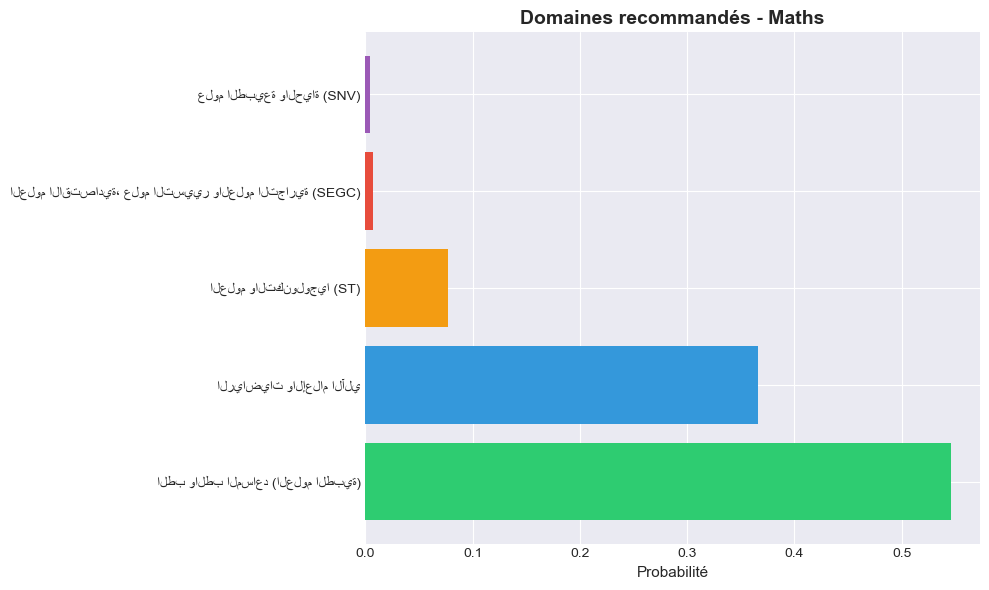


✅ Résultats stockés pour Cell 13.c

→ Exécute Cell 13.c pour voir les formations recommandées


In [20]:
# CELL 13.b: Output - Classement des domaines par probabilité
# ============================================

print("=" * 60)
print("📊 13.b - CLASSEMENT DES DOMAINES PAR PROBABILITÉ")
print("=" * 60)

# Vérifier qu'un étudiant a été saisi dans Cell 13.a
try:
    etudiant = etudiant_courant
    print("✅ Étudiant chargé depuis Cell 13.a")
except NameError:
    print("❌ Aucun étudiant trouvé. Exécute d'abord Cell 13.a")
    print("   (Saisissez les informations et cliquez sur 'Générer les recommandations')")
    # Créer un étudiant par défaut pour tester
    etudiant = {
        'bac_stream': 'Sciences',
        'bac_avg': 16.5,
        'maths_grade': 17.0,
        'physique_grade': 16.0,
        'science_grade': 18.0,
        'techno_grade': 14.0,
        'gestion_grade': 0,
        'economie_grade': 0,
        'arabe_grade': 14.0,
        'francais_grade': 13.0,
        'anglais_grade': 15.0,
        'philo_grade': 12.0,
        'his_geo_grade': 13.0,
        'islamia_grade': 14.0,
        'langue_etranger_grade': 0,
        'tamazight_grade': 10.0,
        'wilaya': 16,
        'stress_level': 3,
        'competitiveness': 5,
        'consistency_score': 4,
        'career_orientation': 'Recherche',
        'avg_variability': 0.8,
        'consistency_score_final': 4.2
    }
    print("   Utilisation d'un étudiant par défaut (Sciences, bac=16.5)")

# Récupérer le modèle de la filière
filiere = etudiant['bac_stream']
modele = modeles[filiere]

# Utiliser la fonction de prédiction existante (pour rester cohérent)
top_domaines = predire_domaines(etudiant, modeles)

# Affichage des résultats
print(f"\n👨‍🎓 PROFIL ÉTUDIANT:")
print(f"   🎓 Filière: {etudiant['bac_stream']}")
print(f"   📈 Moyenne BAC: {etudiant['bac_avg']}")
print(f"   📍 Wilaya: {get_wilaya_name(etudiant['wilaya'])}")
print(f"   🎯 Orientation: {etudiant['career_orientation']}")

print(f"\n🎯 TOP 5 DOMAINES RECOMMANDÉS:")
print("-" * 50)

# Préparer les données pour le graphique
domaines_noms = []
probas_aff = []

for i, (domaine_id, proba) in enumerate(top_domaines[:5]):
    domaine_nom = ID_TO_NOM.get(domaine_id, domaine_id)
    domaines_noms.append(domaine_nom)
    probas_aff.append(proba)
    
    # Affichage textuel avec barre de progression
    barre = '█' * int(proba * 30)
    print(f"\n   {i+1}. {domaine_nom}")
    print(f"      Probabilité: {proba:.1%}")
    print(f"      [{barre:<30}] {proba:.1%}")

# Graphique à barres horizontales
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']

# Inverser pour que le plus haut soit en haut
plt.barh(domaines_noms[::-1], probas_aff[::-1], color=colors[::-1])
plt.xlabel('Probabilité', fontsize=11)
plt.title(f'Domaines recommandés - {filiere}', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Stocker le top_domaines pour Cell 13.c
domaines_ranking = top_domaines
print("\n✅ Résultats stockés pour Cell 13.c")
print("\n→ Exécute Cell 13.c pour voir les formations recommandées")

In [21]:
# CELL 13.c: Output - Top formations personnalisées (VERSION HTML/CSS)
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

print("=" * 60)
print("📊 13.c - TOP FORMATIONS RECOMMANDÉES")
print("=" * 60)

# Vérifier qu'un étudiant a été saisi
try:
    etudiant = etudiant_courant
    print("✅ Étudiant chargé depuis Cell 13.a")
except NameError:
    print("❌ Aucun étudiant trouvé. Exécute d'abord Cell 13.a")
    etudiant = {
        'bac_stream': 'Sciences',
        'bac_avg': 16.5,
        'maths_grade': 17.0,
        'physique_grade': 16.0,
        'science_grade': 18.0,
        'techno_grade': 14.0,
        'gestion_grade': 0,
        'economie_grade': 0,
        'arabe_grade': 14.0,
        'francais_grade': 13.0,
        'anglais_grade': 15.0,
        'philo_grade': 12.0,
        'his_geo_grade': 13.0,
        'islamia_grade': 14.0,
        'langue_etranger_grade': 0,
        'tamazight_grade': 10.0,
        'wilaya': 16,
        'stress_level': 3,
        'competitiveness': 5,
        'consistency_score': 4,
        'career_orientation': 'Recherche',
        'avg_variability': 0.8,
        'consistency_score_final': 4.2
    }
    print("   Utilisation d'un étudiant par défaut")

# Récupérer le ranking
try:
    ranking = domaines_ranking
except NameError:
    filiere = etudiant['bac_stream']
    modele = modeles[filiere]
    features_values = calculer_weighted_et_features(etudiant, modele)
    probas = modele.predict_proba(features_values)[0]
    classes = modele.classes_
    ranking = sorted(zip(classes, probas), key=lambda x: x[1], reverse=True)

# Obtenir les formations
formations, top_domaines, total = recommander_formations(etudiant, modeles, page=0, par_page=10)

# ============================================
# Style CSS
# ============================================

html_style = """
<style>
    .report-container {
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        max-width: 900px;
        margin: 0 auto;
        padding: 20px;
        background: linear-gradient(135deg, #f5f7fa 0%, #e9ecef 100%);
        border-radius: 15px;
    }
    .header {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
        padding: 20px;
        border-radius: 15px 15px 0 0;
        text-align: center;
        margin-bottom: 20px;
    }
    .info-card {
        background: white;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 20px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        border-left: 4px solid #667eea;
    }
    .info-row {
        display: flex;
        justify-content: space-between;
        padding: 8px 0;
        border-bottom: 1px solid #eee;
    }
    .info-label {
        font-weight: bold;
        color: #555;
    }
    .info-value {
        color: #333;
    }
    .domains-container {
        background: white;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 20px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.1);
    }
    .domain-item {
        padding: 10px;
        margin: 8px 0;
        background: #f8f9fa;
        border-radius: 8px;
        transition: transform 0.2s;
    }
    .domain-item:hover {
        transform: translateX(5px);
        background: #e9ecef;
    }
    .domain-name {
        font-weight: bold;
        color: #333;
    }
    .progress-bar {
        background: #e0e0e0;
        border-radius: 10px;
        height: 20px;
        margin-top: 5px;
        overflow: hidden;
    }
    .progress-fill {
        background: linear-gradient(90deg, #667eea, #764ba2);
        height: 100%;
        border-radius: 10px;
        transition: width 0.5s ease;
    }
    .formation-card {
        background: white;
        border-radius: 12px;
        padding: 18px;
        margin-bottom: 15px;
        box-shadow: 0 3px 15px rgba(0,0,0,0.1);
        transition: all 0.3s ease;
        border-left: 5px solid;
    }
    .formation-card:hover {
        transform: translateY(-3px);
        box-shadow: 0 5px 25px rgba(0,0,0,0.15);
    }
    .formation-header {
        display: flex;
        justify-content: space-between;
        align-items: center;
        margin-bottom: 10px;
        flex-wrap: wrap;
    }
    .formation-nom {
        font-size: 1.2em;
        font-weight: bold;
        color: #333;
    }
    .formation-badge {
        padding: 5px 12px;
        border-radius: 20px;
        font-size: 0.8em;
        font-weight: bold;
    }
    .badge-ecoles_superieures { background: #e3f2fd; color: #1565c0; }
    .badge-cycle_long { background: #e8f5e9; color: #2e7d32; }
    .badge-ens { background: #fff3e0; color: #e65100; }
    .badge-ingeniorat { background: #fce4ec; color: #c2185b; }
    .badge-lmd { background: #f3e5f5; color: #7b1fa2; }
    .badge-paramedical { background: #e0f7fa; color: #00838f; }
    .formation-details {
        display: flex;
        flex-wrap: wrap;
        gap: 20px;
        margin: 10px 0;
        font-size: 0.9em;
        color: #555;
    }
    .detail-item {
        display: flex;
        align-items: center;
        gap: 5px;
    }
    .score-high { color: #2e7d32; font-weight: bold; }
    .score-medium { color: #ed6c02; font-weight: bold; }
    .score-low { color: #d32f2f; font-weight: bold; }
    .explication {
        background: #f8f9fa;
        padding: 10px;
        border-radius: 8px;
        margin: 10px 0;
        font-size: 0.85em;
        color: #555;
        border-left: 3px solid #667eea;
    }
    .debouches {
        font-size: 0.85em;
        color: #666;
        margin-top: 8px;
        padding-top: 8px;
        border-top: 1px dashed #ddd;
    }
    .footer {
        text-align: center;
        padding: 15px;
        background: white;
        border-radius: 0 0 10px 10px;
        margin-top: 20px;
        font-size: 0.8em;
        color: #888;
    }
</style>
"""

# ============================================
# Construction du HTML
# ============================================

html_content = html_style
html_content += '<div class="report-container">'

# HEADER
html_content += '''
<div class="header">
    <h2>🎓 RAPPORT D\'ORIENTATION POST-BAC</h2>
    <p>Recommandations personnalisées basées sur votre profil</p>
</div>
'''

# INFO ÉTUDIANT
html_content += f'''
<div class="info-card">
    <h3>📋 Votre profil</h3>
    <div class="info-row">
        <span class="info-label">🎓 Filière BAC</span>
        <span class="info-value">{etudiant['bac_stream']}</span>
    </div>
    <div class="info-row">
        <span class="info-label">📈 Moyenne BAC</span>
        <span class="info-value">{etudiant['bac_avg']} / 20</span>
    </div>
    <div class="info-row">
        <span class="info-label">📍 Wilaya</span>
        <span class="info-value">{get_wilaya_name(etudiant['wilaya'])}</span>
    </div>
    <div class="info-row">
        <span class="info-label">🎯 Orientation</span>
        <span class="info-value">{etudiant['career_orientation']}</span>
    </div>
</div>
'''

# DOMAINES RECOMMANDÉS
html_content += '<div class="domains-container"><h3>📊 Domaines recommandés</h3>'
for i, (domaine_id, proba) in enumerate(ranking[:5]):
    domaine_nom = ID_TO_NOM.get(domaine_id, domaine_id)
    barre_width = proba * 100
    html_content += f'''
    <div class="domain-item">
        <div class="domain-name">{i+1}. {domaine_nom}</div>
        <div class="progress-bar">
            <div class="progress-fill" style="width: {barre_width}%;"></div>
        </div>
        <div style="font-size: 0.85em; margin-top: 5px;">Probabilité: {proba:.1%}</div>
    </div>
    '''
html_content += '</div>'

# FORMATIONS RECOMMANDÉES
if formations:
    html_content += f'<h3>🏆 Top {min(10, len(formations))} formations recommandées</h3>'
    
    for i, f in enumerate(formations[:10]):
        # Couleur de la bordure selon le type
        border_colors = {
            'ecoles_superieures': '#1565c0',
            'cycle_long': '#2e7d32',
            'ens': '#e65100',
            'ingeniorat': '#c2185b',
            'lmd': '#7b1fa2',
            'paramedical': '#00838f'
        }
        border_color = border_colors.get(f['type'], '#667eea')
        
        # Badge
        badge_class = f"badge-{f['type']}"
        
        # Score
        score = min(100, int((f['weighted_avg'] / f['seuil']) * 100)) if f['seuil'] > 0 else 100
        score_class = "score-high" if score >= 80 else "score-medium" if score >= 60 else "score-low"
        
        html_content += f'''
        <div class="formation-card" style="border-left-color: {border_color};">
            <div class="formation-header">
                <span class="formation-nom">{i+1}. {f['nom']}</span>
                <span class="formation-badge {badge_class}">{f['type'].replace('_', ' ').title()} | Priorité {f['priorite']}</span>
            </div>
            <div class="formation-details">
                <span class="detail-item">📚 {f['domaine']}</span>
                <span class="detail-item">📈 {f['weighted_avg']} / {f['seuil']}</span>
                <span class="detail-item {score_class}">⭐ Compatibilité: {score}%</span>
            </div>
            <div class="explication">
                💡 {f['explication'][:150]}...
            </div>
        '''
        if f.get('debouches'):
            html_content += f'<div class="debouches">🎓 Débouchés: {", ".join(f["debouches"][:2])}</div>'
        
        html_content += '</div>'
    
    if total > 10:
        html_content += f'<p style="text-align: center; color: #666; margin-top: 15px;">📌 {total} formations disponibles au total. Pour voir plus, modifiez la pagination.</p>'
else:
    html_content += '<div class="info-card"><p>⚠️ Aucune formation trouvée pour ce profil.</p></div>'

# FOOTER
html_content += '''
<div class="footer">
    <p>Classement par sélectivité (seuil d\'admission le plus élevé d\'abord)</p>
    <p>P1 = prioritaire | P2 = acceptable | P3 = troisième position</p>
</div>
</div>
'''

# Affichage
clear_output(wait=True)
display(HTML(html_content))

print("\n✅ Cell 13.c terminée")


✅ Cell 13.c terminée


In [22]:
# CELL 13.d: Toutes les formations (pagination + recherche)
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

print("=" * 60)
print("📊 13.d - TOUTES LES FORMATIONS RECOMMANDÉES")
print("=" * 60)

# Vérifier qu'un étudiant a été saisi
try:
    etudiant = etudiant_courant
    print("✅ Étudiant chargé depuis Cell 13.a")
except NameError:
    print("❌ Aucun étudiant trouvé. Exécute d'abord Cell 13.a")
    etudiant = {
        'bac_stream': 'Sciences',
        'bac_avg': 16.5,
        'maths_grade': 17.0,
        'physique_grade': 16.0,
        'science_grade': 18.0,
        'techno_grade': 14.0,
        'gestion_grade': 0,
        'economie_grade': 0,
        'arabe_grade': 14.0,
        'francais_grade': 13.0,
        'anglais_grade': 15.0,
        'philo_grade': 12.0,
        'his_geo_grade': 13.0,
        'islamia_grade': 14.0,
        'langue_etranger_grade': 0,
        'tamazight_grade': 10.0,
        'wilaya': 16,
        'stress_level': 3,
        'competitiveness': 5,
        'consistency_score': 4,
        'career_orientation': 'Recherche',
        'avg_variability': 0.8,
        'consistency_score_final': 4.2
    }
    print("   Utilisation d'un étudiant par défaut")

# Récupérer toutes les formations (sans pagination)
formations, top_domaines, total = recommander_formations(etudiant, modeles, page=0, par_page=1000)

# ============================================
# Widgets de pagination
# ============================================

par_page = 10
page_courante = 0

# Slider pour choisir le nombre par page
page_size_slider = widgets.IntSlider(
    value=10, min=5, max=50, step=5,
    description='Formations/page:',
    style={'description_width': 'initial'}
)

# Boutons
btn_prev = widgets.Button(description="◀ Précédent", button_style='primary', layout=widgets.Layout(width='120px'))
btn_next = widgets.Button(description="Suivant ▶", button_style='primary', layout=widgets.Layout(width='120px'))
page_label = widgets.Label(value="Page 1 / 1")

# Zone d'affichage
output = widgets.Output()

# ============================================
# Style CSS
# ============================================

html_style = """
<style>
    .formations-container {
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        max-width: 900px;
        margin: 0 auto;
    }
    .summary-card {
        background: linear-gradient(135deg, #667eea, #764ba2);
        color: white;
        padding: 15px;
        border-radius: 10px;
        margin-bottom: 20px;
        text-align: center;
    }
    .summary-card h3 { margin: 0 0 10px 0; }
    .summary-card p { margin: 0; opacity: 0.9; }
    .formation-item {
        background: white;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 12px;
        border-left: 4px solid #667eea;
        box-shadow: 0 2px 8px rgba(0,0,0,0.1);
        transition: transform 0.2s;
    }
    .formation-item:hover { transform: translateX(5px); }
    .formation-title {
        font-weight: bold;
        font-size: 1.05em;
        color: #333;
        margin-bottom: 8px;
    }
    .formation-meta {
        display: flex;
        flex-wrap: wrap;
        gap: 15px;
        font-size: 0.85em;
        color: #666;
        margin-bottom: 8px;
    }
    .formation-meta span { background: #f0f0f0; padding: 3px 10px; border-radius: 15px; }
    .formation-score {
        font-size: 0.9em;
        margin-top: 8px;
        padding-top: 8px;
        border-top: 1px dashed #ddd;
    }
    .score-high { color: #2e7d32; font-weight: bold; }
    .score-medium { color: #ed6c02; font-weight: bold; }
    .score-low { color: #d32f2f; font-weight: bold; }
    .pagination-controls {
        display: flex;
        justify-content: center;
        align-items: center;
        gap: 20px;
        margin: 20px 0;
        padding: 15px;
        background: white;
        border-radius: 10px;
    }
</style>
"""

# ============================================
# Fonction d'affichage
# ============================================

def afficher_page():
    global page_courante, par_page
    
    start = page_courante * par_page
    end = min(start + par_page, total)
    formations_page = formations[start:end]
    
    total_pages = (total + par_page - 1) // par_page
    
    html_content = html_style
    html_content += '<div class="formations-container">'
    
    # En-tête récapitulatif
    html_content += f'''
    <div class="summary-card">
        <h3>📋 Toutes les formations éligibles</h3>
        <p>{total} formation(s) trouvée(s) pour votre profil</p>
        <p style="font-size: 0.85em;">Triées par sélectivité (seuil le plus élevé d'abord)</p>
    </div>
    '''
    
    # Liste des formations
    for i, f in enumerate(formations_page):
        score = min(100, int((f['weighted_avg'] / f['seuil']) * 100)) if f['seuil'] > 0 else 100
        score_class = "score-high" if score >= 80 else "score-medium" if score >= 60 else "score-low"
        
        # Emoji type
        type_emoji = {'ecoles_superieures': '🏛️', 'cycle_long': '🩺', 'ens': '👨‍🏫', 
                      'ingeniorat': '🔧', 'lmd': '📖', 'paramedical': '🏥'}.get(f['type'], '🎓')
        
        html_content += f'''
        <div class="formation-item">
            <div class="formation-title">{start + i + 1}. {type_emoji} {f['nom']}</div>
            <div class="formation-meta">
                <span>📚 {f['domaine']}</span>
                <span>📋 {f['type']}</span>
                <span>🎯 Priorité {f['priorite']}</span>
                <span>📈 {f['weighted_avg']} / {f['seuil']}</span>
            </div>
            <div class="formation-score">
                <span class="{score_class}">⭐ Compatibilité: {score}%</span>
                <span style="margin-left: 15px;">💡 {f['explication'][:100]}...</span>
            </div>
        </div>
        '''
    
    html_content += '</div>'
    
    # Mise à jour des widgets
    page_label.value = f"Page {page_courante + 1} / {max(1, total_pages)}"
    btn_prev.disabled = (page_courante == 0)
    btn_next.disabled = (page_courante >= total_pages - 1)
    
    with output:
        clear_output(wait=True)
        display(HTML(html_content))

# ============================================
# Gestion des événements
# ============================================

def on_prev_click(b):
    global page_courante
    if page_courante > 0:
        page_courante -= 1
        afficher_page()

def on_next_click(b):
    global page_courante
    total_pages = (total + par_page - 1) // par_page
    if page_courante < total_pages - 1:
        page_courante += 1
        afficher_page()

def on_page_size_change(change):
    global par_page, page_courante
    par_page = change['new']
    page_courante = 0
    afficher_page()

btn_prev.on_click(on_prev_click)
btn_next.on_click(on_next_click)
page_size_slider.observe(on_page_size_change, names='value')

# ============================================
# Affichage initial
# ============================================

# Barre de contrôle
controls = widgets.HBox([btn_prev, page_label, btn_next, page_size_slider], layout=widgets.Layout(justify_content='center'))

display(controls, output)
afficher_page()

print("\n✅ Cell 13.d terminée")

📊 13.d - TOUTES LES FORMATIONS RECOMMANDÉES
✅ Étudiant chargé depuis Cell 13.a


Output()


✅ Cell 13.d terminée


In [18]:
# CELL 8.5: Save 6 Post-BAC Models
import pickle

# Save each model in the current directory
for filiere in ['Sciences', 'Maths', 'Technique_Mathematique', 'Gestion', 'Langues', 'Lettres']:
    filename = f"model_{filiere}.pkl".replace(' ', '_')
    with open(filename, 'wb') as f:
        pickle.dump(modeles[filiere], f)
    print(f"✅ Saved: {filename}")

print("\n✅ All 6 models saved in current directory")

✅ Saved: model_Sciences.pkl
✅ Saved: model_Maths.pkl
✅ Saved: model_Technique_Mathematique.pkl
✅ Saved: model_Gestion.pkl
✅ Saved: model_Langues.pkl
✅ Saved: model_Lettres.pkl

✅ All 6 models saved in current directory
